# 准备

In [1]:
# 加载数据

import polars as pl
from pathlib import Path

# Project paths
PROJECT_DIR = Path(r"C:\Users\71907\Documents\Work\Project")
CLEANED_DIR = PROJECT_DIR / "cleaned_data"

# Load cleaned datasets
courses = pl.read_parquet(CLEANED_DIR / "courses_clean.parquet")
assessments = pl.read_parquet(CLEANED_DIR / "assessments_clean.parquet")
student_info = pl.read_parquet(CLEANED_DIR / "student_info_clean.parquet")
student_registration = pl.read_parquet(
    CLEANED_DIR / "student_registration_clean.parquet"
)
student_assessment = pl.read_parquet(
    CLEANED_DIR / "student_assessment_clean.parquet"
)
student_vle_daily = pl.read_parquet(
    CLEANED_DIR / "student_vle_daily.parquet"
)

print("courses:", courses.shape)
print("assessments:", assessments.shape)
print("student_info:", student_info.shape)
print("student_registration:", student_registration.shape)
print("student_assessment:", student_assessment.shape)
print("student_vle_daily:", student_vle_daily.shape)

courses: (22, 3)
assessments: (206, 6)
student_info: (32593, 12)
student_registration: (32593, 7)
student_assessment: (173912, 7)
student_vle_daily: (1808119, 7)


这里暂时不需要加载 vle_clean.parquet，因为当前 student-level prediction 主要使用已经 daily aggregated 的 student_vle_daily.parquet。

以后构造不同 activity_type 或 VLE resource category features 时，再考虑加入 vle_clean.parquet。

# Overall Design

In [2]:
# 验证 prediction unit
# prediction unit 是
# id_student + code_module + code_presentation

PREDICTION_KEYS = [
    "id_student",
    "code_module",
    "code_presentation"
]

prediction_unit_check = (
    student_info
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.len().alias("n_rows")
    )
    .filter(
        pl.col("n_rows") > 1
    )
)

print("Duplicate prediction units:", prediction_unit_check.height)

Duplicate prediction units: 0


In [3]:
# 确认总 prediction units 数量

n_prediction_units = (
    student_info
    .select(PREDICTION_KEYS)
    .unique()
    .height
)

print("Number of prediction units:", n_prediction_units)

Number of prediction units: 32593


In [4]:
# 再次确认target

target_summary = (
    student_info
    .group_by("final_result")
    .agg(
        pl.len().alias("n_registrations")
    )
    .with_columns(
        (
            pl.col("n_registrations")
            / pl.col("n_registrations").sum()
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort(
        "n_registrations",
        descending=True
    )
)

target_summary

final_result,n_registrations,percentage
str,u32,f64
"""Pass""",12361,37.93
"""Withdrawn""",10156,31.16
"""Fail""",7052,21.64
"""Distinction""",3024,9.28


In [5]:
# 再检查 missing target：

missing_target_check = student_info.select(
    pl.col("final_result").null_count().alias("missing_final_result")
)

missing_target_check


missing_final_result
u32
0


In [6]:
# Four-class outcome
outcome_four_class = student_info.select(
    PREDICTION_KEYS + ["final_result"]
)

# Two-stage Stage 1:
# Withdrawn versus Completed
outcome_stage_1 = outcome_four_class.with_columns(
    pl.when(pl.col("final_result") == "Withdrawn")
    .then(pl.lit("Withdrawn"))
    .otherwise(pl.lit("Completed"))
    .alias("withdrawal_outcome")
)

# Two-stage Stage 2:
# Distinction, Pass and Fail among completed students
outcome_stage_2 = (
    outcome_four_class
    .filter(pl.col("final_result") != "Withdrawn")
    .rename({"final_result": "completion_outcome"})
)

print("Four-class rows:", outcome_four_class.height)
print("Stage 1 rows:", outcome_stage_1.height)
print("Stage 2 completed-student rows:", outcome_stage_2.height)

Four-class rows: 32593
Stage 1 rows: 32593
Stage 2 completed-student rows: 22437


In [7]:
# 检查 Stage 1 distribution

stage_1_summary = (
    outcome_stage_1
    .group_by("withdrawal_outcome")
    .agg(pl.len().alias("n_registrations"))
    .with_columns(
        (
            pl.col("n_registrations")
            / pl.col("n_registrations").sum()
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("n_registrations", descending=True)
)

stage_1_summary

withdrawal_outcome,n_registrations,percentage
str,u32,f64
"""Completed""",22437,68.84
"""Withdrawn""",10156,31.16


In [8]:
# 检查 Stage 2
 
stage_2_summary = (
    outcome_stage_2
    .group_by("completion_outcome")
    .agg(pl.len().alias("n_registrations"))
    .with_columns(
        (
            pl.col("n_registrations")
            / pl.col("n_registrations").sum()
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("n_registrations", descending=True)
)

stage_2_summary

completion_outcome,n_registrations,percentage
str,u32,f64
"""Pass""",12361,55.09
"""Fail""",7052,31.43
"""Distinction""",3024,13.48


## Design

The prediction unit is one student registration within a module presentation,
identified by `id_student`, `code_module`, and `code_presentation`.

The prediction target is `final_result`.

Prediction cutoffs:

- Week 2: Days 0–13
- Week 4: Days 0–27
- Week 6: Days 0–41
- Week 8: Days 0–55

Only information observed before each cutoff is used for feature construction.

In [9]:
# 定义 prediction cutoffs
 
PREDICTION_CUTOFFS = {
    "week_2": 14,
    "week_4": 28,
    "week_6": 42,
    "week_8": 56
}

PREDICTION_CUTOFFS

{'week_2': 14, 'week_4': 28, 'week_6': 42, 'week_8': 56}

## base modelling table

In [10]:
# 先把 student_info 和 student_registration 合并。暂时不构造任何 VLE 或 assessment features

PREDICTION_KEYS = [
    "id_student",
    "code_module",
    "code_presentation"
]

base_table = (
    student_info
    .join(
        student_registration,
        on=PREDICTION_KEYS,
        how="left"
    )
)

print("Base table shape:", base_table.shape)
print("Unique prediction units:", base_table.select(PREDICTION_KEYS).unique().height)

base_table.select(
    [
        "id_student",
        "code_module",
        "code_presentation",
        "final_result",
        "date_registration",
        "date_unregistration"
    ]
).head()

Base table shape: (32593, 16)
Unique prediction units: 32593


id_student,code_module,code_presentation,final_result,date_registration,date_unregistration
i64,str,str,str,i64,i64
11391,"""AAA""","""2013J""","""Pass""",-159,null
28400,"""AAA""","""2013J""","""Pass""",-53,null
30268,"""AAA""","""2013J""","""Withdrawn""",-92,12
31604,"""AAA""","""2013J""","""Pass""",-52,null
32885,"""AAA""","""2013J""","""Pass""",-176,null


这个 join 是正确的：

row count 仍然是 32,593；

prediction unit 仍然唯一；

student_registration 没有导致 duplicate rows；

date_registration 和 date_unregistration 已成功加入；

date_unregistration = null 表示没有记录 withdrawal

In [11]:
# 检查 registration variables 的 missingness 和逻辑一致性

registration_check = base_table.select(
    [
        pl.len().alias("n_rows"),
        pl.col("date_registration").null_count().alias(
            "missing_date_registration"
        ),
        pl.col("date_unregistration").null_count().alias(
            "missing_date_unregistration"
        ),
        (
            (pl.col("final_result") == "Withdrawn")
            & pl.col("date_unregistration").is_null()
        ).sum().alias("withdrawn_without_unregistration_date"),
        (
            (pl.col("final_result") != "Withdrawn")
            & pl.col("date_unregistration").is_not_null()
        ).sum().alias("completed_with_unregistration_date")
    ]
)

registration_check

n_rows,missing_date_registration,missing_date_unregistration,withdrawn_without_unregistration_date,completed_with_unregistration_date
u32,u32,u32,u32,u32
32593,45,22521,93,9


注意，目前 不要把 date_unregistration 或 has_unregistered 加入 prediction features，因为它们可能发生在 prediction cutoff 之后，会造成 temporal leakage

结果说明 date_unregistration 和 final_result 并不是完全一一对应：

93 个 Withdrawn 没有 date_unregistration；

9 个非 Withdrawn 学生存在 date_unregistration；

因此不能用 date_unregistration 来重新定义 outcome。

更重要的是，date_unregistration 和 has_unregistered 都不能作为 prediction features，因为它们直接或间接包含未来 withdrawal 信息，会造成 temporal leakage

In [12]:
base_table.columns

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'date_registration',
 'date_unregistration',
 'registration_date_missing',
 'has_unregistered']

可以作为 static features 的是：

gender

region

highest_education

imd_band

age_band

num_of_prev_attempts

studied_credits

disability

code_module

code_presentation

暂时保留但需要谨慎处理：

date_registration

registration_date_missing

必须排除出 predictors：

final_result

date_unregistration

has_unregistered

其中：

final_result 是 target；

date_unregistration 和 has_unregistered 会造成 temporal leakage；

id_student 只用于 identification 和 grouped data split，不作为 feature；

code_module 和 code_presentation 可以保留，用来控制不同 course contexts

In [13]:
# 建立一份干净的 static base table，暂时不做 encoding

STATIC_FEATURES = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "date_registration",
    "registration_date_missing"
]

static_base = base_table.select(
    PREDICTION_KEYS
    + STATIC_FEATURES
    + ["final_result"]
)

print("Static base shape:", static_base.shape)
print(
    "Unique prediction units:",
    static_base.select(PREDICTION_KEYS).unique().height
)

static_base.head()

Static base shape: (32593, 14)
Unique prediction units: 32593


id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,registration_date_missing,final_result
i64,str,str,str,str,str,str,str,i64,i64,str,i64,i8,str
11391,"""AAA""","""2013J""","""M""","""East Anglian Region""","""HE Qualification""","""90-100%""","""55<=""",0,240,"""N""",-159,0,"""Pass"""
28400,"""AAA""","""2013J""","""F""","""Scotland""","""HE Qualification""","""20-30%""","""35-55""",0,60,"""N""",-53,0,"""Pass"""
30268,"""AAA""","""2013J""","""F""","""North Western Region""","""A Level or Equivalent""","""30-40%""","""35-55""",0,60,"""Y""",-92,0,"""Withdrawn"""
31604,"""AAA""","""2013J""","""F""","""South East Region""","""A Level or Equivalent""","""50-60%""","""35-55""",0,60,"""N""",-52,0,"""Pass"""
32885,"""AAA""","""2013J""","""F""","""West Midlands Region""","""Lower Than A Level""","""50-60%""","""0-35""",0,60,"""N""",-176,0,"""Pass"""


正确完成：

static_base 保持 32,593 rows

prediction unit 仍然唯一

没有保留 date_unregistration 和 has_unregistered

code_module 和 code_presentation 既是 identifiers，也会作为 course-context features 使用

registration_date_missing 目前显示成 str，这个有点奇怪，因为前面它应该是 indicator，后续需要检查

In [14]:
# 只检查 static_base 各 columns 的 missingness 和 datatype

static_base.select(
    [
        pl.col(column).null_count().alias(column)
        for column in static_base.columns
    ]
)


id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,registration_date_missing,final_result
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,45,0,0


missingness 完全符合预期：

只有 date_registration 有 45 个 missing

registration_date_missing 已经把这 45 个记录标记出来

其他 static variables 和 target 都没有 missing

In [15]:
static_base.schema

Schema([('id_student', Int64),
        ('code_module', String),
        ('code_presentation', String),
        ('gender', String),
        ('region', String),
        ('highest_education', String),
        ('imd_band', String),
        ('age_band', String),
        ('num_of_prev_attempts', Int64),
        ('studied_credits', Int64),
        ('disability', String),
        ('date_registration', Int64),
        ('registration_date_missing', Int8),
        ('final_result', String)])

Schema 是正常的，registration_date_missing 实际上是 Int8，不是 str。刚才表格下方那一排 datatype 是按 columns 顺序显示的，最后的 str 对应的是 final_result

In [16]:
# 只处理 date_registratio
# 先不要直接填值，我们先看这 45 个 missing 是否集中在某些 module、presentation 或 outcome

missing_registration_summary = (
    static_base
    .filter(pl.col("date_registration").is_null())
    .group_by(
        [
            "code_module",
            "code_presentation",
            "final_result"
        ]
    )
    .agg(
        pl.len().alias("n_students")
    )
    .sort(
        "n_students",
        descending=True
    )
)

missing_registration_summary

code_module,code_presentation,final_result,n_students
str,str,str,u32
"""CCC""","""2014B""","""Withdrawn""",5
"""FFF""","""2014B""","""Withdrawn""",5
"""BBB""","""2014B""","""Withdrawn""",5
"""DDD""","""2013J""","""Withdrawn""",5
"""DDD""","""2014J""","""Withdrawn""",3
…,…,…,…
"""BBB""","""2014J""","""Withdrawn""",1
"""FFF""","""2013J""","""Withdrawn""",1
"""BBB""","""2013B""","""Fail""",1


结果说明 45 个 missing 并不是只集中在一个 cohort，而且大部分看起来是 Withdrawn，少量是 Fail

In [17]:
# 先不要填补，再做一个更简洁的汇总，确认 missing 的 outcome distribution

(
    static_base
    .filter(pl.col("date_registration").is_null())
    .group_by("final_result")
    .agg(
        pl.len().alias("n_students")
    )
    .with_columns(
        (
            pl.col("n_students")
            / pl.col("n_students").sum()
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("n_students", descending=True)
)

final_result,n_students,percentage
str,u32,f64
"""Withdrawn""",39,86.67
"""Fail""",5,11.11
"""Pass""",1,2.22


这一步是为了判断：如果 missing 几乎全部集中在 Withdrawn，直接用 overall median 填补可能不太合适；更可能采用 module–presentation median imputation + missing indicator

结果很关键：date_registration 的 missing 明显不是随机分布，86.67% 来自 Withdrawn。所以我们不能简单删除这 45 行，也不建议只用 overall median 直接填补。

比较稳妥的方案是后续在 preprocessing 阶段使用：

registration_date_missing 保留 missing pattern；

date_registration 用 module–presentation median 填补；

imputation 只在 training data 上拟合，避免 leakage

但现在先不填

In [18]:
# 只检查每个 module–presentation 是否都有足够的非缺失值计算 median

registration_median_check = (
    static_base
    .group_by(
        [
            "code_module",
            "code_presentation"
        ]
    )
    .agg(
        pl.len().alias("n_students"),
        pl.col("date_registration")
        .is_not_null()
        .sum()
        .alias("n_known_registration_dates"),
        pl.col("date_registration")
        .median()
        .alias("median_date_registration")
    )
    .sort(
        [
            "code_module",
            "code_presentation"
        ]
    )
)

registration_median_check

code_module,code_presentation,n_students,n_known_registration_dates,median_date_registration
str,str,u32,u32,f64
"""AAA""","""2013J""",383,383,-64.0
"""AAA""","""2014J""",365,365,-68.0
"""BBB""","""2013B""",1767,1766,-51.0
"""BBB""","""2013J""",2237,2235,-56.0
"""BBB""","""2014B""",1613,1608,-66.0
…,…,…,…,…
"""FFF""","""2014B""",1500,1495,-53.0
"""FFF""","""2014J""",2365,2363,-59.0
"""GGG""","""2013J""",952,952,-43.0


结果没问题：每个 module–presentation 都有足够的非缺失 date_registration，所以之后可以安全地做 module–presentation median imputation。

不过现在先不填补，因为正式 modelling 时最好在 train split 内完成 preprocessing

In [19]:
# 检查 date_registration 的范围，确认有没有异常值

static_base.select(
    [
        pl.col("date_registration").min().alias("min_date_registration"),
        pl.col("date_registration").quantile(0.25).alias("q1"),
        pl.col("date_registration").median().alias("median"),
        pl.col("date_registration").mean().round(2).alias("mean"),
        pl.col("date_registration").quantile(0.75).alias("q3"),
        pl.col("date_registration").max().alias("max_date_registration")
    ]
)

min_date_registration,q1,median,mean,q3,max_date_registration
i64,f64,f64,f64,f64,i64
-322,-100.0,-57.0,-69.41,-29.0,167


范围总体合理：

大多数学生在开课前注册，median 是 -57 days；

最早为 -322 days；

最晚为 167 days after course start。

正值不一定是 error，可能代表 late registration。由于这个变量可能反映 enrollment timing，建议保留为 static feature，但暂时不要截断或删除极端值

In [20]:
# 检查 开课后才注册的学生有多少，以及 outcome distribution

late_registration_summary = (
    static_base
    .filter(pl.col("date_registration") > 0)
    .group_by("final_result")
    .agg(
        pl.len().alias("n_students")
    )
    .with_columns(
        (
            pl.col("n_students")
            / pl.col("n_students").sum()
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("n_students", descending=True)
)

print(
    "Students registered after course start:",
    static_base.filter(pl.col("date_registration") > 0).height
)

late_registration_summary

Students registered after course start: 234


final_result,n_students,percentage
str,u32,f64
"""Pass""",102,43.59
"""Fail""",67,28.63
"""Withdrawn""",49,20.94
"""Distinction""",16,6.84


结果说明共有 234 名学生在 course start 后注册，而且并没有特别集中在 Withdrawn：

Pass：102

Fail：67

Withdrawn：49

Distinction：16

所以 date_registration > 0 不是简单的 withdrawal signal。建议：

保留原始连续变量 date_registration；

额外建立 registered_after_start indicator；

date_registration 的 45 个 missing 之后再用 module–presentation median 处理。

In [21]:
# 添加这个 indicator，不做 imputation

static_base = static_base.with_columns(
    (pl.col("date_registration") > 0)
    .cast(pl.Int8)
    .alias("registered_after_start")
)

static_base.select(
    [
        pl.col("registered_after_start").value_counts()
    ]
)

registered_after_start
struct[2]
"{0,32314}"
"{1,234}"
"{null,45}"


结果符合 Polars 的逻辑：date_registration = null 时，比较 > 0 也会得到 null。

因为我们已经有单独的 registration_date_missing indicator，所以 registered_after_start 可以把这 45 个 missing 设为 0，避免重复的 missing 状态

In [22]:
# 覆盖刚才的 column

static_base = static_base.with_columns(
    (pl.col("date_registration") > 0)
    .fill_null(False)
    .cast(pl.Int8)
    .alias("registered_after_start")
)

static_base.group_by("registered_after_start").agg(
    pl.len().alias("n_students")
).sort("registered_after_start")

registered_after_start,n_students
i8,u32
0,32359
1,234


registered_after_start 已经处理正确：

234 名学生在 course start 后注册；

其余 32,359 名，包括 45 个 registration date missing，记为 0；

missing 状态仍由 registration_date_missing 单独保留。

现在 static base 暂时完成

 # VLE data

In [23]:
# 开始看 VLE data，但先不构造 features，只检查 student_vle_daily 的 columns 和日期范围

print(student_vle_daily.schema)

student_vle_daily.select(
    [
        pl.col("date").min().alias("min_date"),
        pl.col("date").max().alias("max_date"),
        pl.col("daily_clicks").min().alias("min_daily_clicks"),
        pl.col("daily_clicks").max().alias("max_daily_clicks")
    ]
)

Schema({'code_module': String, 'code_presentation': String, 'id_student': Int32, 'date': Int16, 'daily_clicks': Int32, 'daily_unique_sites': UInt32, 'daily_interaction_records': UInt32})


min_date,max_date,min_daily_clicks,max_daily_clicks
i16,i16,i32,i32
-25,269,1,6988


student_vle_daily 的结构正常：

日期范围是 -25 到 269；

daily_clicks 都是正数，最小 1；

daily aggregation columns 都齐全；

id_student 是 Int32，而 static_base 中是 Int64，后面 join 时需要统一 datatype

### Week 2

In [24]:
# 只做 Week 2 cumulative VLE features，先验证逻辑，不急着写函数

week_2_cutoff = PREDICTION_CUTOFFS["week_2"]

week_2_vle = (
    student_vle_daily
    .filter(
        (pl.col("date") >= 0)
        & (pl.col("date") < week_2_cutoff)
    )
)

print("Week 2 VLE rows:", week_2_vle.height)

week_2_vle.select(
    [
        pl.col("date").min().alias("min_date"),
        pl.col("date").max().alias("max_date"),
        pl.col("daily_clicks").sum().alias("total_clicks")
    ]
)

Week 2 VLE rows: 147761


min_date,max_date,total_clicks
i16,i16,i32
0,13,3810725


Week 2 的筛选正确：

日期范围正好是 Day 0–13

共 147,761 daily rows

cumulative clicks 是 3,810,725

没有混入 pre-course activity 或 Day 14 之后的数据

In [25]:
# 把这些 daily rows 汇总成每个 prediction unit 一行的 Week 2 cumulative VLE features

week_2_cumulative_vle = (
    week_2_vle
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.col("daily_clicks")
        .sum()
        .alias("cumulative_clicks"),

        pl.col("date")
        .n_unique()
        .alias("cumulative_active_days"),

        pl.col("daily_unique_sites")
        .sum()
        .alias("cumulative_unique_sites"),

        pl.col("daily_interaction_records")
        .sum()
        .alias("cumulative_interaction_records")
    )
)

print("Week 2 students with VLE activity:", week_2_cumulative_vle.height)
print(
    "Duplicate prediction units:",
    week_2_cumulative_vle
    .group_by(PREDICTION_KEYS)
    .len()
    .filter(pl.col("len") > 1)
    .height
)

week_2_cumulative_vle.head()

Week 2 students with VLE activity: 26425
Duplicate prediction units: 0


id_student,code_module,code_presentation,cumulative_clicks,cumulative_active_days,cumulative_unique_sites,cumulative_interaction_records
i32,str,str,i32,u32,u32,u32
533944,"""FFF""","""2013B""",222,10,60,72
572602,"""EEE""","""2013J""",93,4,12,17
678041,"""DDD""","""2014J""",72,5,20,29
650471,"""EEE""","""2014J""",80,6,22,34
481863,"""DDD""","""2014B""",9,3,7,7


结果正常：

Week 2 有 26,425 个 prediction units 出现过 VLE activity；

没有 duplicate prediction units；

其余学生之后 join 回 static_base 时应保留，并把 VLE activity features 填为 0；

id_student 目前是 Int32，而 static_base 中是 Int64，join 前需要统一

另外，cumulative_unique_sites 这个名字不够准确。它是每天 daily_unique_sites 的总和，同一个 site 在不同日期可能被重复计算，因此应改名为 sum_daily_unique_sites

In [26]:
# 做 datatype 和 column name 修正

week_2_cumulative_vle = (
    week_2_cumulative_vle
    .rename({
        "cumulative_unique_sites": "sum_daily_unique_sites"
    })
    .with_columns(
        pl.col("id_student").cast(pl.Int64)
    )
)

print(week_2_cumulative_vle.schema)
week_2_cumulative_vle.head()

Schema({'id_student': Int64, 'code_module': String, 'code_presentation': String, 'cumulative_clicks': Int32, 'cumulative_active_days': UInt32, 'sum_daily_unique_sites': UInt32, 'cumulative_interaction_records': UInt32})


id_student,code_module,code_presentation,cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records
i64,str,str,i32,u32,u32,u32
533944,"""FFF""","""2013B""",222,10,60,72
572602,"""EEE""","""2013J""",93,4,12,17
678041,"""DDD""","""2014J""",72,5,20,29
650471,"""EEE""","""2014J""",80,6,22,34
481863,"""DDD""","""2014B""",9,3,7,7


In [27]:
# 把 Week 2 cumulative VLE features 左连接回完整的 static_base，确保没有 VLE activity 的学生也保留

week_2_dataset = (
    static_base
    .join(
        week_2_cumulative_vle,
        on=PREDICTION_KEYS,
        how="left"
    )
)

print("Week 2 dataset shape:", week_2_dataset.shape)
print(
    "Unique prediction units:",
    week_2_dataset.select(PREDICTION_KEYS).unique().height
)

week_2_dataset.select(
    [
        pl.col("cumulative_clicks").null_count().alias("missing_cumulative_clicks"),
        pl.col("cumulative_active_days").null_count().alias("missing_cumulative_active_days"),
        pl.col("sum_daily_unique_sites").null_count().alias("missing_sum_daily_unique_sites"),
        pl.col("cumulative_interaction_records").null_count().alias("missing_interaction_records")
    ]
)

Week 2 dataset shape: (32593, 19)
Unique prediction units: 32593


missing_cumulative_clicks,missing_cumulative_active_days,missing_sum_daily_unique_sites,missing_interaction_records
u32,u32,u32,u32
6168,6168,6168,6168


join 完全正确：

仍然是 32,593 个 prediction units；

没有 duplicate；

6,168 名学生在 Week 2 的 Day 0–13 没有任何 VLE activity；

这类 missing 不是数据缺失，而是 observed zero activity，所以应该填成 0

In [28]:
VLE_FEATURES = [
    "cumulative_clicks",
    "cumulative_active_days",
    "sum_daily_unique_sites",
    "cumulative_interaction_records"
]

week_2_dataset = week_2_dataset.with_columns(
    [
        pl.col(column).fill_null(0)
        for column in VLE_FEATURES
    ]
)

week_2_dataset.select(
    [
        pl.col(column).null_count().alias(column)
        for column in VLE_FEATURES
    ]
)

cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records
u32,u32,u32,u32
0,0,0,0


In [29]:
# 加一个 indicator，用来区分“完全没有 VLE activity”的学生

week_2_dataset = week_2_dataset.with_columns(
    (pl.col("cumulative_active_days") == 0)
    .cast(pl.Int8)
    .alias("no_vle_activity")
)

week_2_dataset.group_by("no_vle_activity").agg(
    pl.len().alias("n_students")
).sort("no_vle_activity")

no_vle_activity,n_students
i8,u32
0,26425
1,6168


In [30]:
# 先不加新 features，只做一个 validation：确认 join 和 fill zero 之后，Week 2 的 total clicks 没有发生变化

week_2_dataset.select(
    pl.col("cumulative_clicks")
    .sum()
    .alias("total_week_2_clicks_after_join")
)

total_week_2_clicks_after_join
i32
3810725


验证通过，Week 2 的 cumulative clicks 在筛选、aggregation、join 和 zero filling 之后仍然是 3,810,725，说明目前没有丢失或重复 activity records

In [31]:
# 构造一个简单的衍生 feature：平均每个 active day 的 clicks

week_2_dataset = week_2_dataset.with_columns(
    pl.when(pl.col("cumulative_active_days") > 0)
    .then(
        pl.col("cumulative_clicks")
        / pl.col("cumulative_active_days")
    )
    .otherwise(0.0)
    .alias("mean_clicks_per_active_day")
)

week_2_dataset.select(
    [
        pl.col("mean_clicks_per_active_day").min().alias("min"),
        pl.col("mean_clicks_per_active_day").median().alias("median"),
        pl.col("mean_clicks_per_active_day").mean().round(2).alias("mean"),
        pl.col("mean_clicks_per_active_day").max().alias("max"),
        pl.col("mean_clicks_per_active_day").null_count().alias("missing")
    ]
)

min,median,mean,max,missing
f64,f64,f64,f64,u32
0.0,14.0,18.02,473.3,0


范围合理：

minimum = 0，对应 Week 2 没有 VLE activity；

median = 14 clicks per active day；

mean = 18.02，高于 median，说明存在 right-skew；

maximum = 473.3，虽然较高，但暂时不能直接认定为异常；

没有 missing 或除以 0 的问题

In [32]:
# 检查最大值对应的是不是 active days 很少造成的，而不是 aggregation error

week_2_dataset.select(
    [
        "id_student",
        "code_module",
        "code_presentation",
        "cumulative_clicks",
        "cumulative_active_days",
        "mean_clicks_per_active_day",
        "final_result"
    ]
).sort(
    "mean_clicks_per_active_day",
    descending=True
).head(10)

id_student,code_module,code_presentation,cumulative_clicks,cumulative_active_days,mean_clicks_per_active_day,final_result
i64,str,str,i32,u32,f64,str
497180,"""FFF""","""2013B""",4733,10,473.3,"""Pass"""
557060,"""BBB""","""2013B""",615,2,307.5,"""Pass"""
523249,"""FFF""","""2014J""",274,1,274.0,"""Pass"""
613165,"""FFF""","""2014J""",1509,6,251.5,"""Pass"""
232072,"""CCC""","""2014J""",931,4,232.75,"""Fail"""
592634,"""FFF""","""2013J""",1615,7,230.714286,"""Fail"""
234609,"""FFF""","""2013B""",221,1,221.0,"""Pass"""
696615,"""FFF""","""2014J""",219,1,219.0,"""Fail"""
583487,"""FFF""","""2014J""",2980,14,212.857143,"""Pass"""


这些高值看起来不是 aggregation error：

第一名是 4,733 clicks / 10 active days，确实是高强度 activity；

也有一些学生只 active 1–2 days，因此平均值会被放大；

高值主要出现在 FFF 和部分 CCC，但同时覆盖 Pass 和 Fail，不像单一 outcome leakage。

所以目前先不删除、不截断。以后在 Logistic Regression preprocessing 时再考虑对这类 right-skewed numerical features 使用 log1p，tree-based models 则可以直接保留原值。

In [33]:
# 检查 Week 2 cumulative features 的整体分布，先看几个核心变量

week_2_dataset.select(
    [
        pl.col("cumulative_clicks").median().alias("median_clicks"),
        pl.col("cumulative_clicks").mean().round(2).alias("mean_clicks"),
        pl.col("cumulative_clicks").max().alias("max_clicks"),

        pl.col("cumulative_active_days").median().alias("median_active_days"),
        pl.col("cumulative_active_days").mean().round(2).alias("mean_active_days"),
        pl.col("cumulative_active_days").max().alias("max_active_days")
    ]
)

median_clicks,mean_clicks,max_clicks,median_active_days,mean_active_days,max_active_days
f64,f64,i32,f64,f64,u32
57.0,116.92,4733,4.0,4.53,14


分布合理：

cumulative_clicks 的 mean 116.92 明显高于 median 57，说明 right-skew；

cumulative_active_days 的 median 4、mean 4.53；

最大 active days 是 14，符合 Week 2 的 Day 0–13；

没有时间窗口定义错误

In [34]:
# 添加一个很直观的 cumulative feature：inactive days within the 14-day observation window

week_2_dataset = week_2_dataset.with_columns(
    (
        week_2_cutoff
        - pl.col("cumulative_active_days")
    )
    .cast(pl.Int16)
    .alias("cumulative_inactive_days")
)

week_2_dataset.select(
    [
        pl.col("cumulative_inactive_days").min().alias("min"),
        pl.col("cumulative_inactive_days").median().alias("median"),
        pl.col("cumulative_inactive_days").mean().round(2).alias("mean"),
        pl.col("cumulative_inactive_days").max().alias("max"),
        pl.col("cumulative_inactive_days").null_count().alias("missing")
    ]
)

min,median,mean,max,missing
i16,f64,f64,i16,u32
0,10.0,9.47,14,0


结果完全合理：

minimum 0：14 天全部活跃；

median 10：典型学生仅有约 4 个 active days；

maximum 14：整个观察窗口没有 activity；

没有 missing。

不过 cumulative_inactive_days 和 cumulative_active_days 是完全线性对应的：

inactive days = 14 - active days

因此它们同时进入 Logistic Regression 会产生完全共线性。这个变量可以用于解释或 tree-based model，但正式 feature set 中通常只保留其中一个

In [35]:
# 先不删除，添加更容易跨不同 cutoffs 比较的 active-day proportion

week_2_dataset = week_2_dataset.with_columns(
    (
        pl.col("cumulative_active_days")
        / week_2_cutoff
    )
    .alias("active_day_proportion")
)

week_2_dataset.select(
    [
        pl.col("active_day_proportion").min().alias("min"),
        pl.col("active_day_proportion").median().alias("median"),
        pl.col("active_day_proportion").mean().round(4).alias("mean"),
        pl.col("active_day_proportion").max().alias("max"),
        pl.col("active_day_proportion").null_count().alias("missing")
    ]
)

min,median,mean,max,missing
f64,f64,f64,f64,u32
0.0,0.285714,0.3238,1.0,0


结果正确：

range 是 0–1；

median 0.285714 等于 4/14，与 median active days = 4 完全一致；

mean 0.3238 对应平均 4.53/14；

没有 missing。

不过它与 cumulative_active_days 也是完全线性对应，因此最终每个 model 不需要同时保留两者。active_day_proportion 的优势是可以直接比较 Week 2/4/6/8，后面更适合统一 feature definition。

In [36]:
# 检查我们当前 Week 2 dataset 的完整 columns，避免 feature 越加越乱

week_2_dataset.columns

['id_student',
 'code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'date_registration',
 'registration_date_missing',
 'final_result',
 'registered_after_start',
 'cumulative_clicks',
 'cumulative_active_days',
 'sum_daily_unique_sites',
 'cumulative_interaction_records',
 'no_vle_activity',
 'mean_clicks_per_active_day',
 'cumulative_inactive_days',
 'active_day_proportion']

现在的 columns 已经很清楚，可以分成四类。

Identifiers / target ------------------------------

id_student

code_module

code_presentation

final_result


Static features ------------------------------

gender

region

highest_education

imd_band

age_band

num_of_prev_attempts

studied_credits

disability

date_registration

registration_date_missing

registered_after_start


Cumulative VLE features ------------------------------

cumulative_clicks
cumulative_active_days
sum_daily_unique_sites
cumulative_interaction_records
no_vle_activity
mean_clicks_per_active_day


暂时冗余，不建议和对应变量同时进 Logistic Regression ------------------------------

cumulative_inactive_days
active_day_proportion

因为：

cumulative_inactive_days = 14 - cumulative_active_days
active_day_proportion = cumulative_active_days / 14

它们都只是 cumulative_active_days 的线性变换

In [37]:
# 先不删 column，只建立一份正式的 Week 2 cumulative feature list

WEEK_2_CUMULATIVE_FEATURES = [
    "cumulative_clicks",
    "cumulative_active_days",
    "sum_daily_unique_sites",
    "cumulative_interaction_records",
    "no_vle_activity",
    "mean_clicks_per_active_day"
]

print("Number of Week 2 cumulative VLE features:",
      len(WEEK_2_CUMULATIVE_FEATURES))

week_2_dataset.select(
    WEEK_2_CUMULATIVE_FEATURES
).head()

Number of Week 2 cumulative VLE features: 6


cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records,no_vle_activity,mean_clicks_per_active_day
i32,u32,u32,u32,i8,f64
203,5,31,34,0,40.6
241,7,52,70,0,34.428571
179,6,34,42,0,29.833333
176,7,40,50,0,25.142857
177,9,38,48,0,19.666667


6 个 Week 2 cumulative VLE features 已经建立成功，数值也正常

In [38]:
# 开始构造项目核心的 time-windowed features
# 先只做最基础的一步：给 Day 0–13 标记对应的 course week
# Day 0–6 → Week 1
# Day 7–13 → Week 2

week_2_vle_weekly = week_2_vle.with_columns(
    (
        pl.col("date") // 7 + 1
    )
    .cast(pl.Int8)
    .alias("course_week")
)

week_2_vle_weekly.group_by("course_week").agg(
    pl.len().alias("n_daily_rows"),
    pl.col("daily_clicks").sum().alias("total_clicks")
).sort("course_week")

course_week,n_daily_rows,total_clicks
i8,u32,i32
1,75366,2013077
2,72395,1797648


结果完全正确：

Week 1：2,013,077 clicks

Week 2：1,797,648 clicks

合计仍然是 3,810,725


说明 course_week mapping 没有问题

In [39]:
# 把 activity 汇总到 student–week level，先不 pivot

week_2_student_weekly = (
    week_2_vle_weekly
    .group_by(
        PREDICTION_KEYS + ["course_week"]
    )
    .agg(
        pl.col("daily_clicks")
        .sum()
        .alias("weekly_clicks"),

        pl.col("date")
        .n_unique()
        .alias("weekly_active_days"),

        pl.col("daily_unique_sites")
        .sum()
        .alias("weekly_sum_daily_unique_sites"),

        pl.col("daily_interaction_records")
        .sum()
        .alias("weekly_interaction_records")
    )
)

print("Student-week rows:", week_2_student_weekly.height)

print(
    "Duplicate student-week rows:",
    week_2_student_weekly
    .group_by(PREDICTION_KEYS + ["course_week"])
    .len()
    .filter(pl.col("len") > 1)
    .height
)

week_2_student_weekly.head()

Student-week rows: 46826
Duplicate student-week rows: 0


id_student,code_module,code_presentation,course_week,weekly_clicks,weekly_active_days,weekly_sum_daily_unique_sites,weekly_interaction_records
i32,str,str,i8,i32,u32,u32,u32
622225,"""DDD""","""2014B""",2,2,1,1,1
575999,"""DDD""","""2014J""",1,55,3,15,19
607085,"""EEE""","""2013J""",1,33,3,21,21
688881,"""FFF""","""2014J""",2,43,3,12,12
685964,"""DDD""","""2014J""",2,91,5,36,44


结果正常：

共 46,826 个 student-week rows

每个 student + module + presentation + week 都唯一

说明有些学生只在 Week 1 或 Week 2 活跃，所以不是 26,425 × 2

当前还没有补全“某周无 activity”的情况

In [40]:
# 检查每周有多少不同 prediction units

week_2_student_weekly.group_by("course_week").agg(
    pl.len().alias("n_student_week_rows"),
    pl.struct(PREDICTION_KEYS).n_unique().alias("n_active_students")
).sort("course_week")

course_week,n_student_week_rows,n_active_students
i8,u32,u32
1,23658,23658
2,23168,23168


结果正常：

Week 1 有 23,658 个 active students；

Week 2 有 23,168 个 active students；

两周任意一周有 activity 的 unique students 是之前的 26,425；

因此有些学生只活跃于其中一周，这正是 time-windowed representation 需要保留的信息

In [41]:
# 记录每个学生是否在 Week 1、Week 2 出现过

weekly_activity_pattern = (
    week_2_student_weekly
    .group_by(PREDICTION_KEYS)
    .agg(
        (pl.col("course_week") == 1)
        .any()
        .alias("active_in_week_1"),

        (pl.col("course_week") == 2)
        .any()
        .alias("active_in_week_2")
    )
    .with_columns(
        pl.when(
            pl.col("active_in_week_1")
            & pl.col("active_in_week_2")
        )
        .then(pl.lit("Both weeks"))
        .when(pl.col("active_in_week_1"))
        .then(pl.lit("Week 1 only"))
        .otherwise(pl.lit("Week 2 only"))
        .alias("activity_pattern")
    )
)

weekly_activity_pattern.group_by("activity_pattern").agg(
    pl.len().alias("n_students")
).sort("n_students", descending=True)

activity_pattern,n_students
str,u32
"""Both weeks""",20401
"""Week 1 only""",3257
"""Week 2 only""",2767


结果正确，而且已经显示出 time-windowed features 的价值：

两周都活跃：20,401

只在 Week 1 活跃：3,257

只在 Week 2 活跃：2,767

两周都没有 activity 的 6,168 人目前不在这个表里

In [42]:
# 把 Week 1 和 Week 2 的 weekly clicks pivot 成两列，先不处理其他 weekly features

week_2_clicks_wide = (
    week_2_student_weekly
    .select(
        PREDICTION_KEYS
        + ["course_week", "weekly_clicks"]
    )
    .pivot(
        values="weekly_clicks",
        index=PREDICTION_KEYS,
        on="course_week"
    )
    .rename({
        "1": "week_1_clicks",
        "2": "week_2_clicks"
    })
)

print("Wide table shape:", week_2_clicks_wide.shape)
print(
    "Unique prediction units:",
    week_2_clicks_wide.select(PREDICTION_KEYS).unique().height
)

week_2_clicks_wide.head()

Wide table shape: (26425, 5)
Unique prediction units: 26425


id_student,code_module,code_presentation,week_2_clicks,week_1_clicks
i32,str,str,i32,i32
622225,"""DDD""","""2014B""",2,14
575999,"""DDD""","""2014J""",43,55
607085,"""EEE""","""2013J""",24,33
688881,"""FFF""","""2014J""",43,92
685964,"""DDD""","""2014J""",91,71


pivot 正确：

26,425 个至少在 Week 1 或 Week 2 活跃的 prediction units；

week_1_clicks 和 week_2_clicks 已分开；

某周没有 activity 的学生保留为 null，这是正常的

In [43]:
# 做 datatype 统一并把单周缺失填成 0

week_2_clicks_wide = (
    week_2_clicks_wide
    .with_columns(
        pl.col("id_student").cast(pl.Int64),
        pl.col("week_1_clicks").fill_null(0),
        pl.col("week_2_clicks").fill_null(0)
    )
)

week_2_clicks_wide.select(
    [
        pl.col("week_1_clicks").null_count().alias("missing_week_1"),
        pl.col("week_2_clicks").null_count().alias("missing_week_2"),
        pl.col("week_1_clicks").sum().alias("total_week_1_clicks"),
        pl.col("week_2_clicks").sum().alias("total_week_2_clicks")
    ]
)

missing_week_1,missing_week_2,total_week_1_clicks,total_week_2_clicks
u32,u32,i32,i32
0,0,2013077,1797648


In [44]:
# 把这两列 join 回完整的 week_2_dataset，这样两周都没有 activity 的 6,168 名学生也会保留

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_clicks_wide,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("week_1_clicks").fill_null(0),
        pl.col("week_2_clicks").fill_null(0)
    )
)

print("Week 2 dataset shape:", week_2_dataset.shape)

week_2_dataset.select(
    [
        pl.col("week_1_clicks").null_count().alias("missing_week_1"),
        pl.col("week_2_clicks").null_count().alias("missing_week_2"),
        pl.col("week_1_clicks").sum().alias("total_week_1_clicks"),
        pl.col("week_2_clicks").sum().alias("total_week_2_clicks")
    ]
)

Week 2 dataset shape: (32593, 25)


missing_week_1,missing_week_2,total_week_1_clicks,total_week_2_clicks
u32,u32,i32,i32
0,0,2013077,1797648


In [45]:
# 构造 temporal change features

week_2_dataset = week_2_dataset.with_columns(
    # Week 2 compared with Week 1
    (
        pl.col("week_2_clicks")
        - pl.col("week_1_clicks")
    ).alias("click_change_week_1_to_2"),

    # Relative change with +1 to avoid division by zero
    (
        (
            pl.col("week_2_clicks")
            - pl.col("week_1_clicks")
        )
        / (
            pl.col("week_1_clicks")
            + 1
        )
    ).alias("click_relative_change_week_1_to_2")
)

click_change_week_1_to_2 > 0：Week 2 clicks 增加；

< 0：Week 2 clicks 减少；

relative change 中加 1 是为了避免 Week 1 clicks 为 0 时除以 0。

In [46]:
# 定义 Week 2 time-windowed feature list

WEEK_2_TIME_WINDOWED_FEATURES = [
    "week_1_clicks",
    "week_2_clicks",
    "click_change_week_1_to_2",
    "click_relative_change_week_1_to_2"
]

print(
    "Number of Week 2 time-windowed features:",
    len(WEEK_2_TIME_WINDOWED_FEATURES)
)

Number of Week 2 time-windowed features: 4


In [47]:
# 一次性 validation

week_2_validation = week_2_dataset.select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("week_1_clicks")
        .null_count()
        .alias("missing_week_1_clicks"),

        pl.col("week_2_clicks")
        .null_count()
        .alias("missing_week_2_clicks"),

        pl.col("click_change_week_1_to_2")
        .null_count()
        .alias("missing_click_change"),

        pl.col("click_relative_change_week_1_to_2")
        .null_count()
        .alias("missing_relative_change"),

        pl.col("week_1_clicks")
        .sum()
        .alias("total_week_1_clicks"),

        pl.col("week_2_clicks")
        .sum()
        .alias("total_week_2_clicks"),

        (
            pl.col("week_1_clicks")
            + pl.col("week_2_clicks")
        )
        .sum()
        .alias("total_week_1_to_2_clicks"),

        pl.col("click_change_week_1_to_2")
        .min()
        .alias("min_click_change"),

        pl.col("click_change_week_1_to_2")
        .median()
        .alias("median_click_change"),

        pl.col("click_change_week_1_to_2")
        .max()
        .alias("max_click_change")
    ]
)

week_2_validation

n_rows,n_unique_prediction_units,missing_week_1_clicks,missing_week_2_clicks,missing_click_change,missing_relative_change,total_week_1_clicks,total_week_2_clicks,total_week_1_to_2_clicks,min_click_change,median_click_change,max_click_change
u32,u32,u32,u32,u32,u32,i32,i32,i32,i32,f64,i32
32593,32593,0,0,0,0,2013077,1797648,3810725,-4037,0.0,1149


验证全部通过：

32,593 rows 和 prediction units 都保持不变；

weekly clicks 没有 missing；

Week 1 + Week 2 clicks 正好等于 cumulative clicks；

median change = 0，说明很多学生两周 activity 相同或都为 0；

极端变化值先保留，后续再考虑 log1p 或 scaling

In [48]:
# 构造 weekly active days，这样 time-windowed representation 不只依赖 clicks

week_2_active_days_wide = (
    week_2_student_weekly
    .select(
        PREDICTION_KEYS
        + ["course_week", "weekly_active_days"]
    )
    .pivot(
        values="weekly_active_days",
        index=PREDICTION_KEYS,
        on="course_week"
    )
    .rename({
        "1": "week_1_active_days",
        "2": "week_2_active_days"
    })
    .with_columns(
        pl.col("id_student").cast(pl.Int64),
        pl.col("week_1_active_days").fill_null(0),
        pl.col("week_2_active_days").fill_null(0)
    )
)

In [49]:
# join 回完整 dataset

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_active_days_wide,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("week_1_active_days").fill_null(0),
        pl.col("week_2_active_days").fill_null(0)
    )
)

In [50]:
# 构造 active-day change

week_2_dataset = week_2_dataset.with_columns(
    (
        pl.col("week_2_active_days")
        - pl.col("week_1_active_days")
    ).alias("active_day_change_week_1_to_2")
)

WEEK_2_TIME_WINDOWED_FEATURES = [
    "week_1_clicks",
    "week_2_clicks",
    "click_change_week_1_to_2",
    "click_relative_change_week_1_to_2",
    "week_1_active_days",
    "week_2_active_days",
    "active_day_change_week_1_to_2"
]

print(
    "Number of Week 2 time-windowed features:",
    len(WEEK_2_TIME_WINDOWED_FEATURES)
)

Number of Week 2 time-windowed features: 7


In [51]:
# 统一 validation

week_2_active_days_validation = week_2_dataset.select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("week_1_active_days")
        .null_count()
        .alias("missing_week_1_active_days"),

        pl.col("week_2_active_days")
        .null_count()
        .alias("missing_week_2_active_days"),

        pl.col("active_day_change_week_1_to_2")
        .null_count()
        .alias("missing_active_day_change"),

        pl.col("week_1_active_days")
        .min()
        .alias("min_week_1_active_days"),

        pl.col("week_1_active_days")
        .max()
        .alias("max_week_1_active_days"),

        pl.col("week_2_active_days")
        .min()
        .alias("min_week_2_active_days"),

        pl.col("week_2_active_days")
        .max()
        .alias("max_week_2_active_days"),

        (
            pl.col("week_1_active_days")
            + pl.col("week_2_active_days")
        )
        .sum()
        .alias("total_weekly_active_days"),

        pl.col("cumulative_active_days")
        .sum()
        .alias("total_cumulative_active_days"),

        pl.col("active_day_change_week_1_to_2")
        .min()
        .alias("min_active_day_change"),

        pl.col("active_day_change_week_1_to_2")
        .median()
        .alias("median_active_day_change"),

        pl.col("active_day_change_week_1_to_2")
        .max()
        .alias("max_active_day_change")
    ]
)

week_2_active_days_validation

n_rows,n_unique_prediction_units,missing_week_1_active_days,missing_week_2_active_days,missing_active_day_change,min_week_1_active_days,max_week_1_active_days,min_week_2_active_days,max_week_2_active_days,total_weekly_active_days,total_cumulative_active_days,min_active_day_change,median_active_day_change,max_active_day_change
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64,u32
32593,32593,0,0,0,0,7,0,7,147761,147761,0,1.0,4294967295


发现了一个真实 error：

max_active_day_change = 4294967295

这不是实际值，而是 unsigned integer underflow。weekly_active_days 是 UInt32，当 Week 2 少于 Week 1 时，直接相减会把负数绕成一个极大的正数。

例如：

0 - 1

在 UInt32 下会变成：

4294967295

需要在相减前先转成有符号整数

In [52]:
# 修正 active-day change

week_2_dataset = week_2_dataset.with_columns(
    (
        pl.col("week_2_active_days").cast(pl.Int16)
        - pl.col("week_1_active_days").cast(pl.Int16)
    ).alias("active_day_change_week_1_to_2")
)

week_2_dataset.select(
    [
        pl.col("active_day_change_week_1_to_2")
        .min()
        .alias("min_active_day_change"),

        pl.col("active_day_change_week_1_to_2")
        .median()
        .alias("median_active_day_change"),

        pl.col("active_day_change_week_1_to_2")
        .max()
        .alias("max_active_day_change"),

        pl.col("active_day_change_week_1_to_2")
        .null_count()
        .alias("missing_active_day_change")
    ]
)

min_active_day_change,median_active_day_change,max_active_day_change,missing_active_day_change
i16,f64,i16,u32
-7,0.0,7,0


修正成功，现在范围是正常的 -7 到 7，没有 missing。这个 bug 已经完全解决

In [53]:
# pivot 两组 weekly features

week_2_other_weekly_wide = (
    week_2_student_weekly
    .select(
        PREDICTION_KEYS
        + [
            "course_week",
            "weekly_sum_daily_unique_sites",
            "weekly_interaction_records"
        ]
    )
    .pivot(
        values=[
            "weekly_sum_daily_unique_sites",
            "weekly_interaction_records"
        ],
        index=PREDICTION_KEYS,
        on="course_week"
    )
)

print(week_2_other_weekly_wide.columns)

['id_student', 'code_module', 'code_presentation', 'weekly_sum_daily_unique_sites_2', 'weekly_sum_daily_unique_sites_1', 'weekly_interaction_records_2', 'weekly_interaction_records_1']


因为 Polars 对 multiple-value pivot 生成的 column names 会因版本略有差异

看完实际 column names 后，再给后面 rename、join 和 validation 的一整批代码，避免猜错列名

In [54]:
# 重新生成并直接 rename

week_2_other_weekly_wide = (
    week_2_student_weekly
    .select(
        PREDICTION_KEYS
        + [
            "course_week",
            "weekly_sum_daily_unique_sites",
            "weekly_interaction_records"
        ]
    )
    .pivot(
        values=[
            "weekly_sum_daily_unique_sites",
            "weekly_interaction_records"
        ],
        index=PREDICTION_KEYS,
        on="course_week"
    )
    .rename({
        "weekly_sum_daily_unique_sites_1": "week_1_sum_daily_unique_sites",
        "weekly_sum_daily_unique_sites_2": "week_2_sum_daily_unique_sites",
        "weekly_interaction_records_1": "week_1_interaction_records",
        "weekly_interaction_records_2": "week_2_interaction_records"
    })
    .with_columns(
        pl.col("id_student").cast(pl.Int64),
        pl.col("week_1_sum_daily_unique_sites").fill_null(0),
        pl.col("week_2_sum_daily_unique_sites").fill_null(0),
        pl.col("week_1_interaction_records").fill_null(0),
        pl.col("week_2_interaction_records").fill_null(0)
    )
)

print(week_2_other_weekly_wide.columns)
print(week_2_other_weekly_wide.shape)

['id_student', 'code_module', 'code_presentation', 'week_2_sum_daily_unique_sites', 'week_1_sum_daily_unique_sites', 'week_2_interaction_records', 'week_1_interaction_records']
(26425, 7)


In [55]:
# 避免重复 join
# 因为可能已经运行过部分 join，先安全删除可能存在的 columns

columns_to_replace = [
    "week_1_sum_daily_unique_sites",
    "week_2_sum_daily_unique_sites",
    "week_1_interaction_records",
    "week_2_interaction_records",
    "site_count_change_week_1_to_2",
    "interaction_change_week_1_to_2"
]

existing_columns_to_drop = [
    column
    for column in columns_to_replace
    if column in week_2_dataset.columns
]

if existing_columns_to_drop:
    week_2_dataset = week_2_dataset.drop(existing_columns_to_drop)

print("Dropped existing columns:", existing_columns_to_drop)

Dropped existing columns: []


In [56]:
# 重新 join 和构造 change

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_other_weekly_wide,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("week_1_sum_daily_unique_sites").fill_null(0),
        pl.col("week_2_sum_daily_unique_sites").fill_null(0),
        pl.col("week_1_interaction_records").fill_null(0),
        pl.col("week_2_interaction_records").fill_null(0)
    )
    .with_columns(
        (
            pl.col("week_2_sum_daily_unique_sites").cast(pl.Int32)
            - pl.col("week_1_sum_daily_unique_sites").cast(pl.Int32)
        ).alias("site_count_change_week_1_to_2"),

        (
            pl.col("week_2_interaction_records").cast(pl.Int32)
            - pl.col("week_1_interaction_records").cast(pl.Int32)
        ).alias("interaction_change_week_1_to_2")
    )
)

In [57]:
# validation

week_2_dataset.select(
    [
        pl.len().alias("n_rows"),
        pl.struct(PREDICTION_KEYS).n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("week_1_sum_daily_unique_sites")
        .null_count().alias("missing_week_1_sites"),
        pl.col("week_2_sum_daily_unique_sites")
        .null_count().alias("missing_week_2_sites"),

        (
            pl.col("week_1_sum_daily_unique_sites")
            + pl.col("week_2_sum_daily_unique_sites")
        ).sum().alias("total_weekly_site_counts"),

        pl.col("sum_daily_unique_sites")
        .sum().alias("total_cumulative_site_counts"),

        (
            pl.col("week_1_interaction_records")
            + pl.col("week_2_interaction_records")
        ).sum().alias("total_weekly_interactions"),

        pl.col("cumulative_interaction_records")
        .sum().alias("total_cumulative_interactions"),

        pl.col("site_count_change_week_1_to_2")
        .min().alias("min_site_change"),
        pl.col("site_count_change_week_1_to_2")
        .max().alias("max_site_change"),

        pl.col("interaction_change_week_1_to_2")
        .min().alias("min_interaction_change"),
        pl.col("interaction_change_week_1_to_2")
        .max().alias("max_interaction_change")
    ]
)

n_rows,n_unique_prediction_units,missing_week_1_sites,missing_week_2_sites,total_weekly_site_counts,total_cumulative_site_counts,total_weekly_interactions,total_cumulative_interactions,min_site_change,max_site_change,min_interaction_change,max_interaction_change
u32,u32,u32,u32,u32,u32,u32,u32,i32,i32,i32,i32
32593,32593,0,0,843270,843270,1068395,1068395,-152,137,-163,149


验证全部通过：

32,593 个 prediction units 保持不变；

weekly site counts 与 cumulative site counts 完全一致；

weekly interaction records 与 cumulative interaction records 完全一致；

所有 weekly features 都没有 missing；

change features 已正确使用 signed integer，没有 underflow

先把 Week 2 VLE feature construction 收尾，并保存一个 checkpoint。之后再开始 assessment features

In [58]:
# 更新正式 feature lists

WEEK_2_CUMULATIVE_FEATURES = [
    "cumulative_clicks",
    "cumulative_active_days",
    "sum_daily_unique_sites",
    "cumulative_interaction_records",
    "no_vle_activity",
    "mean_clicks_per_active_day"
]

WEEK_2_TIME_WINDOWED_FEATURES = [
    "week_1_clicks",
    "week_2_clicks",
    "click_change_week_1_to_2",
    "click_relative_change_week_1_to_2",

    "week_1_active_days",
    "week_2_active_days",
    "active_day_change_week_1_to_2",

    "week_1_sum_daily_unique_sites",
    "week_2_sum_daily_unique_sites",
    "site_count_change_week_1_to_2",

    "week_1_interaction_records",
    "week_2_interaction_records",
    "interaction_change_week_1_to_2"
]

print("Cumulative VLE features:", len(WEEK_2_CUMULATIVE_FEATURES))
print("Time-windowed VLE features:", len(WEEK_2_TIME_WINDOWED_FEATURES))

Cumulative VLE features: 6
Time-windowed VLE features: 13


In [59]:
# 检查所有正式 VLE features 的 missingness

week_2_vle_feature_check = week_2_dataset.select(
    [
        pl.col(column).null_count().alias(column)
        for column in (
            WEEK_2_CUMULATIVE_FEATURES
            + WEEK_2_TIME_WINDOWED_FEATURES
        )
    ]
)

week_2_vle_feature_check

cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records,no_vle_activity,mean_clicks_per_active_day,week_1_clicks,week_2_clicks,click_change_week_1_to_2,click_relative_change_week_1_to_2,week_1_active_days,week_2_active_days,active_day_change_week_1_to_2,week_1_sum_daily_unique_sites,week_2_sum_daily_unique_sites,site_count_change_week_1_to_2,week_1_interaction_records,week_2_interaction_records,interaction_change_week_1_to_2
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [60]:
# 检查 cumulative 与 weekly clicks 是否逐行一致
# 不只是检查总和，而是检查每个 student registration

week_2_row_level_check = week_2_dataset.select(
    [
        (
            pl.col("cumulative_clicks")
            != (
                pl.col("week_1_clicks")
                + pl.col("week_2_clicks")
            )
        )
        .sum()
        .alias("click_mismatch_rows"),

        (
            pl.col("cumulative_active_days")
            != (
                pl.col("week_1_active_days")
                + pl.col("week_2_active_days")
            )
        )
        .sum()
        .alias("active_day_mismatch_rows"),

        (
            pl.col("sum_daily_unique_sites")
            != (
                pl.col("week_1_sum_daily_unique_sites")
                + pl.col("week_2_sum_daily_unique_sites")
            )
        )
        .sum()
        .alias("site_count_mismatch_rows"),

        (
            pl.col("cumulative_interaction_records")
            != (
                pl.col("week_1_interaction_records")
                + pl.col("week_2_interaction_records")
            )
        )
        .sum()
        .alias("interaction_mismatch_rows")
    ]
)

week_2_row_level_check

click_mismatch_rows,active_day_mismatch_rows,site_count_mismatch_rows,interaction_mismatch_rows
u32,u32,u32,u32
0,0,0,0


In [61]:
# 保存 Week 2 checkpoint
# 先建立输出文件夹

FEATURE_DIR = PROJECT_DIR / "feature_data"
FEATURE_DIR.mkdir(exist_ok=True)

week_2_output_path = FEATURE_DIR / "week_2_vle_features.parquet"

week_2_dataset.write_parquet(
    week_2_output_path
)

print("Saved to:", week_2_output_path)
print("Saved shape:", week_2_dataset.shape)

Saved to: C:\Users\71907\Documents\Work\Project\feature_data\week_2_vle_features.parquet
Saved shape: (32593, 36)


Week 2 的 VLE feature construction 已经完整通过：

32,593 个 prediction units；

36 columns；

19 个正式 VLE features 全部没有 missing；

cumulative 与 weekly features 在 row level 完全一致；

checkpoint 已成功保存

现在进入 Week 2 assessment features。这一批先只完成 assessment records 与 assessment metadata 的合并和 cutoff filtering，不急着生成最终 features

In [62]:
# 检查两张 assessment tables 的 columns

print("assessments columns:")
print(assessments.columns)

print("\nstudent_assessment columns:")
print(student_assessment.columns)

assessments columns:
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']

student_assessment columns:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score', 'score_missing', 'submitted_after_module_end']


In [63]:
# 合并 assessment metadata

assessment_records = (
    student_assessment
    .join(
        assessments,
        on="id_assessment",
        how="left"
    )
)

print("Assessment records shape:", assessment_records.shape)
print("Assessment records columns:")
print(assessment_records.columns)

Assessment records shape: (173912, 12)
Assessment records columns:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score', 'score_missing', 'submitted_after_module_end', 'code_module', 'code_presentation', 'assessment_type', 'date', 'weight']


In [64]:
# 检查 join 是否完整

assessment_join_check = assessment_records.select(
    [
        pl.len().alias("n_rows"),

        pl.col("code_module")
        .null_count()
        .alias("missing_code_module"),

        pl.col("code_presentation")
        .null_count()
        .alias("missing_code_presentation"),

        pl.col("assessment_type")
        .null_count()
        .alias("missing_assessment_type"),

        pl.col("date")
        .null_count()
        .alias("missing_assessment_date")
    ]
)

assessment_join_check

n_rows,missing_code_module,missing_code_presentation,missing_assessment_type,missing_assessment_date
u32,u32,u32,u32,u32
173912,0,0,0,2865


In [65]:
# 查看 schema 和前几行关键字段

print(assessment_records.schema)

assessment_records.select(
    [
        "id_student",
        "code_module",
        "code_presentation",
        "id_assessment",
        "assessment_type",
        "date",
        "date_submitted",
        "score",
        "is_banked"
    ]
).head()

Schema({'id_assessment': Int64, 'id_student': Int64, 'date_submitted': Int64, 'is_banked': Int64, 'score': Int64, 'score_missing': Int8, 'submitted_after_module_end': Int8, 'code_module': String, 'code_presentation': String, 'assessment_type': String, 'date': Int64, 'weight': Float64})


id_student,code_module,code_presentation,id_assessment,assessment_type,date,date_submitted,score,is_banked
i64,str,str,i64,str,i64,i64,i64,i64
11391,"""AAA""","""2013J""",1752,"""TMA""",19,18,78,0
28400,"""AAA""","""2013J""",1752,"""TMA""",19,22,70,0
31604,"""AAA""","""2013J""",1752,"""TMA""",19,17,72,0
32885,"""AAA""","""2013J""",1752,"""TMA""",19,26,69,0
38053,"""AAA""","""2013J""",1752,"""TMA""",19,19,79,0


结果正常：

assessment_records 保持 173,912 rows；

join 完整，没有缺失 module、presentation 或 assessment type；

2,865 个 missing date 来自 structural missingness，主要应为 Exam；

date_submitted、score、is_banked 都已经保留

下一步先区分两个概念：

Observed submission by cutoff：date_submitted < cutoff

Assessment available/due by cutoff：assessment deadline date < cutoff

Week 2 先只使用 截止 Day 13 已经实际提交并可观察到的 records。这样不会使用未来 submission。我们先检查这些 records 的结构，不立即生成最终 features

In [66]:
# 筛选 Week 2 前已提交的记录

week_2_assessment_records = (
    assessment_records
    .filter(
        pl.col("date_submitted") < week_2_cutoff
    )
)

print(
    "Week 2 observed assessment records:",
    week_2_assessment_records.height
)

week_2_assessment_records.select(
    [
        pl.col("date_submitted").min().alias("min_date_submitted"),
        pl.col("date_submitted").max().alias("max_date_submitted"),
        pl.col("score").null_count().alias("missing_scores"),
        pl.col("date").null_count().alias("missing_assessment_dates")
    ]
)

Week 2 observed assessment records: 5191


min_date_submitted,max_date_submitted,missing_scores,missing_assessment_dates
i64,i64,u32,u32
-11,13,5,0


这里会保留 course start 前的 banked/early submissions，因为它们在 Week 2 cutoff 时已经可观察。之后会通过 is_banked 单独处理

In [67]:
# 检查 assessment type 和 banked records

week_2_assessment_structure = (
    week_2_assessment_records
    .group_by(
        [
            "assessment_type",
            "is_banked"
        ]
    )
    .agg(
        pl.len().alias("n_records"),
        pl.col("id_student").n_unique().alias("n_students"),
        pl.col("score").null_count().alias("missing_scores")
    )
    .sort(
        [
            "assessment_type",
            "is_banked"
        ]
    )
)

week_2_assessment_structure

assessment_type,is_banked,n_records,n_students,missing_scores
str,i64,u32,u32,u32
"""CMA""",0,841,699,0
"""CMA""",1,571,248,0
"""TMA""",0,2441,2436,4
"""TMA""",1,1338,513,1


In [68]:
# 检查 deadline 是否已经到达

week_2_deadline_status = (
    week_2_assessment_records
    .with_columns(
        pl.when(pl.col("date").is_null())
        .then(pl.lit("Unknown deadline"))
        .when(pl.col("date") < week_2_cutoff)
        .then(pl.lit("Due before cutoff"))
        .otherwise(pl.lit("Due after cutoff"))
        .alias("deadline_status")
    )
    .group_by("deadline_status")
    .agg(
        pl.len().alias("n_records"),
        pl.col("id_student").n_unique().alias("n_students")
    )
    .sort("n_records", descending=True)
)

week_2_deadline_status

deadline_status,n_records,n_students
str,u32,u32
"""Due after cutoff""",4114,2472
"""Due before cutoff""",1077,1077


In [69]:
# 统一 validation

week_2_assessment_validation = (
    week_2_assessment_records
    .select(
        [
            pl.len().alias("n_records"),

            pl.struct(PREDICTION_KEYS)
            .n_unique()
            .alias("n_prediction_units_with_submission"),

            (
                pl.col("date_submitted")
                >= week_2_cutoff
            )
            .sum()
            .alias("records_on_or_after_cutoff"),

            (
                pl.col("date_submitted")
                < 0
            )
            .sum()
            .alias("pre_course_submission_records"),

            (
                pl.col("is_banked")
                == 1
            )
            .sum()
            .alias("banked_records"),

            pl.col("score")
            .null_count()
            .alias("missing_scores")
        ]
    )
)

week_2_assessment_validation

n_records,n_prediction_units_with_submission,records_on_or_after_cutoff,pre_course_submission_records,banked_records,missing_scores
u32,u32,u32,u32,u32,u32
5191,3546,0,2057,1909,5


结果说明 Week 2 assessment data 里，banked assessments 占比很高：

5,191 条已观察 submission；

其中 1,909 条是 is_banked = 1；

2,057 条发生在 course start 前；

4,114 条虽然在 cutoff 前提交，但 assessment deadline 在 cutoff 后；

没有 Exam records，且所有 deadline 都已知。

需要区分：

Banked records 是从以前 presentation 转入的成绩，不代表当前课程 Week 1–2 的真实 submission behavior；

但这些信息在 cutoff 时已经可用，所以不能简单删除；

最稳妥的做法是：

current-course assessment features 只使用 non-banked records，banked information 单独做 indicator/count features

In [70]:
# 分开 non-banked 和 banked records

week_2_current_assessments = (
    week_2_assessment_records
    .filter(pl.col("is_banked") == 0)
)

week_2_banked_assessments = (
    week_2_assessment_records
    .filter(pl.col("is_banked") == 1)
)

print(
    "Current-course records:",
    week_2_current_assessments.height
)

print(
    "Banked records:",
    week_2_banked_assessments.height
)

print(
    "Combined records:",
    week_2_current_assessments.height
    + week_2_banked_assessments.height
)

Current-course records: 3282
Banked records: 1909
Combined records: 5191


In [71]:
# 构造 current-course assessment features

week_2_current_assessment_features = (
    week_2_current_assessments
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.len().alias("n_current_submissions"),

        pl.col("id_assessment")
        .n_unique()
        .alias("n_current_assessments_submitted"),

        pl.col("score")
        .mean()
        .alias("mean_current_score"),

        pl.col("score")
        .min()
        .alias("min_current_score"),

        pl.col("score")
        .max()
        .alias("max_current_score"),

        pl.col("score_missing")
        .sum()
        .alias("n_missing_current_scores"),

        (pl.col("assessment_type") == "CMA")
        .sum()
        .alias("n_cma_submissions"),

        (pl.col("assessment_type") == "TMA")
        .sum()
        .alias("n_tma_submissions")
    )
    .with_columns(
        pl.col("id_student").cast(pl.Int64)
    )
)

print(
    "Prediction units with current-course submissions:",
    week_2_current_assessment_features.height
)

Prediction units with current-course submissions: 3022


In [72]:
# 构造 banked assessment features

week_2_banked_features = (
    week_2_banked_assessments
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.len().alias("n_banked_submissions"),

        pl.col("id_assessment")
        .n_unique()
        .alias("n_banked_assessments"),

        pl.col("score")
        .mean()
        .alias("mean_banked_score")
    )
    .with_columns(
        pl.col("id_student").cast(pl.Int64),

        pl.lit(1)
        .cast(pl.Int8)
        .alias("has_banked_assessment")
    )
)

print(
    "Prediction units with banked assessments:",
    week_2_banked_features.height
)

Prediction units with banked assessments: 526


In [73]:
# 基础 validation

week_2_assessment_feature_validation = pl.DataFrame({
    "check": [
        "current_record_total",
        "banked_record_total",
        "current_plus_banked",
        "current_units",
        "banked_units"
    ],
    "value": [
        week_2_current_assessment_features
        .select(pl.col("n_current_submissions").sum())
        .item(),

        week_2_banked_features
        .select(pl.col("n_banked_submissions").sum())
        .item(),

        (
            week_2_current_assessment_features
            .select(pl.col("n_current_submissions").sum())
            .item()
            +
            week_2_banked_features
            .select(pl.col("n_banked_submissions").sum())
            .item()
        ),

        week_2_current_assessment_features.height,

        week_2_banked_features.height
    ]
})

week_2_assessment_feature_validation


check,value
str,i64
"""current_record_total""",3282
"""banked_record_total""",1909
"""current_plus_banked""",5191
"""current_units""",3022
"""banked_units""",526


结果全部正确：

current-course records：3,282

banked records：1,909

合计仍为 5,191

3,022 个 prediction units 有 current-course submission

526 个 prediction units 有 banked assessment

3022 + 526 = 3548，比之前的 3,546 个有 submission 的 prediction units 多 2，说明有 2 个学生同时拥有 current-course 和 banked submissions，这是合理的重叠，不是 duplicate error。

In [74]:
# 全删除可能已存在的 assessment columns

assessment_columns_to_replace = [
    "n_current_submissions",
    "n_current_assessments_submitted",
    "mean_current_score",
    "min_current_score",
    "max_current_score",
    "n_missing_current_scores",
    "n_cma_submissions",
    "n_tma_submissions",
    "no_current_submission",
    "n_banked_submissions",
    "n_banked_assessments",
    "mean_banked_score",
    "has_banked_assessment"
]

existing_assessment_columns = [
    column
    for column in assessment_columns_to_replace
    if column in week_2_dataset.columns
]

if existing_assessment_columns:
    week_2_dataset = week_2_dataset.drop(
        existing_assessment_columns
    )

print("Dropped existing columns:", existing_assessment_columns)

Dropped existing columns: []


In [75]:
# join current-course features

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_current_assessment_features,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("n_current_submissions").fill_null(0),
        pl.col("n_current_assessments_submitted").fill_null(0),
        pl.col("n_missing_current_scores").fill_null(0),
        pl.col("n_cma_submissions").fill_null(0),
        pl.col("n_tma_submissions").fill_null(0)
    )
    .with_columns(
        (
            pl.col("n_current_submissions") == 0
        )
        .cast(pl.Int8)
        .alias("no_current_submission")
    )
)

注意：现在不要把 mean_current_score、min_current_score 和 max_current_score 填成 0。没有 submission 时，0 分和“没有成绩”不是同一含义。我们会保留 null，并使用 no_current_submission 区分

In [76]:
# join banked features

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_banked_features,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("n_banked_submissions").fill_null(0),
        pl.col("n_banked_assessments").fill_null(0),
        pl.col("has_banked_assessment").fill_null(0)
    )
)

同样，mean_banked_score 暂时保留 null，表示该学生没有 banked assessment。

In [77]:
# validation

week_2_assessment_join_validation = (
    week_2_dataset
    .select(
        [
            pl.len().alias("n_rows"),

            pl.struct(PREDICTION_KEYS)
            .n_unique()
            .alias("n_unique_prediction_units"),

            pl.col("n_current_submissions")
            .sum()
            .alias("total_current_submissions"),

            pl.col("n_banked_submissions")
            .sum()
            .alias("total_banked_submissions"),

            (
                pl.col("n_current_submissions") > 0
            )
            .sum()
            .alias("units_with_current_submission"),

            (
                pl.col("has_banked_assessment") == 1
            )
            .sum()
            .alias("units_with_banked_assessment"),

            (
                (pl.col("n_current_submissions") > 0)
                & (pl.col("has_banked_assessment") == 1)
            )
            .sum()
            .alias("units_with_both"),

            pl.col("no_current_submission")
            .sum()
            .alias("units_without_current_submission"),

            pl.col("mean_current_score")
            .null_count()
            .alias("missing_mean_current_score"),

            pl.col("mean_banked_score")
            .null_count()
            .alias("missing_mean_banked_score"),

            pl.col("n_current_submissions")
            .null_count()
            .alias("missing_current_counts"),

            pl.col("n_banked_submissions")
            .null_count()
            .alias("missing_banked_counts")
        ]
    )
)

week_2_assessment_join_validation

n_rows,n_unique_prediction_units,total_current_submissions,total_banked_submissions,units_with_current_submission,units_with_banked_assessment,units_with_both,units_without_current_submission,missing_mean_current_score,missing_mean_banked_score,missing_current_counts,missing_banked_counts
u32,u32,u32,u32,u32,u32,u32,i64,u32,u32,u32,u32
32593,32593,3282,1909,3022,526,2,29571,29575,32067,0,0


结果整体正确。关键点是：

missing_mean_current_score = 29,575

units_without_current_submission = 29,571

两者相差 4，说明有 4 个 prediction units 虽然提交了 current-course assessment，但其已观察到的 score 全部 missing。这与前面 current-course records 中共有 4 个 missing scores 一致。

mean_banked_score 的 missing 数量是 32,067，正好等于：

32593 - 526 = 32067

所以 banked 部分完全正常。

In [78]:
# 定位这 4 个学生，并建立更准确的 score-availability indicator
# 查看 current submission 但无 observed score 的学生

current_submission_without_score = (
    week_2_dataset
    .filter(
        (pl.col("n_current_submissions") > 0)
        & pl.col("mean_current_score").is_null()
    )
    .select(
        PREDICTION_KEYS
        + [
            "final_result",
            "n_current_submissions",
            "n_missing_current_scores",
            "n_cma_submissions",
            "n_tma_submissions"
        ]
    )
)

print(
    "Units with current submission but no observed score:",
    current_submission_without_score.height
)

current_submission_without_score

Units with current submission but no observed score: 4


id_student,code_module,code_presentation,final_result,n_current_submissions,n_missing_current_scores,n_cma_submissions,n_tma_submissions
i64,str,str,str,u32,i64,u32,u32
534151,"""BBB""","""2013B""","""Withdrawn""",1,1,0,1
606501,"""BBB""","""2014B""","""Withdrawn""",1,1,0,1
555297,"""DDD""","""2013B""","""Withdrawn""",1,1,0,1
174436,"""FFF""","""2013B""","""Fail""",1,1,0,1


In [79]:
# 增加 score availability indicators

week_2_dataset = week_2_dataset.with_columns(
    pl.col("mean_current_score")
    .is_not_null()
    .cast(pl.Int8)
    .alias("has_current_score"),

    (
        (pl.col("n_current_submissions") > 0)
        & pl.col("mean_current_score").is_null()
    )
    .cast(pl.Int8)
    .alias("current_score_missing")
)

区分了三种情况：

no_current_submission = 1：没有提交；

current_score_missing = 1：提交了，但 score missing；

has_current_score = 1：至少有一个可观察 score。

In [80]:
# 验证三类状态

week_2_score_status_validation = (
    week_2_dataset
    .with_columns(
        pl.when(pl.col("no_current_submission") == 1)
        .then(pl.lit("No submission"))
        .when(pl.col("current_score_missing") == 1)
        .then(pl.lit("Submitted, score missing"))
        .otherwise(pl.lit("Observed score"))
        .alias("score_status")
    )
    .group_by("score_status")
    .agg(
        pl.len().alias("n_students")
    )
    .sort("n_students", descending=True)
)

week_2_score_status_validation

score_status,n_students
str,u32
"""No submission""",29571
"""Observed score""",3018
"""Submitted, score missing""",4


In [81]:
# 检查 observed scores 的范围

week_2_dataset.select(
    [
        pl.col("mean_current_score")
        .min()
        .alias("min_mean_score"),

        pl.col("mean_current_score")
        .median()
        .alias("median_mean_score"),

        pl.col("mean_current_score")
        .mean()
        .round(2)
        .alias("overall_mean_score"),

        pl.col("mean_current_score")
        .max()
        .alias("max_mean_score"),

        pl.col("has_current_score")
        .sum()
        .alias("units_with_observed_score")
    ]
)

min_mean_score,median_mean_score,overall_mean_score,max_mean_score,units_with_observed_score
f64,f64,f64,f64,i64
0.0,79.0,73.68,100.0,3018


结果完全合理：

3,018 个 prediction units 有 observed score；

4 个有 submission 但 score missing；

29,571 个没有 current-course submission；

score 范围 0–100，median 79，没有异常值。

4 个 missing-score cases 中，3 个最终 Withdrawn、1 个 Fail，但数量太少，不需要特殊处理

接下来构造 submission timing features。这里仅使用 is_banked = 0 的 current-course records，并根据：

submission_delay = date_submitted - assessment deadline

判断是否 late。负数表示提前提交，0 表示 deadline 当天，正数表示 late。

In [82]:
# 加入 submission delay 和 late indicator

week_2_current_assessments = (
    week_2_current_assessments
    .with_columns(
        (
            pl.col("date_submitted")
            - pl.col("date")
        ).alias("submission_delay")
    )
    .with_columns(
        (
            pl.col("submission_delay") > 0
        )
        .cast(pl.Int8)
        .alias("is_late_submission")
    )
)

week_2_current_assessments.select(
    [
        pl.col("submission_delay").min().alias("min_delay"),
        pl.col("submission_delay").median().alias("median_delay"),
        pl.col("submission_delay").mean().round(2).alias("mean_delay"),
        pl.col("submission_delay").max().alias("max_delay"),
        pl.col("submission_delay").null_count().alias("missing_delay"),
        pl.col("is_late_submission").sum().alias("late_records")
    ]
)

min_delay,median_delay,mean_delay,max_delay,missing_delay,late_records
i64,f64,f64,i64,u32,i64
-246,-10.0,-63.63,1,0,19


In [83]:
# 按 prediction unit 汇总 timing features

week_2_assessment_timing_features = (
    week_2_current_assessments
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.col("submission_delay")
        .mean()
        .alias("mean_submission_delay"),

        pl.col("submission_delay")
        .min()
        .alias("earliest_submission_delay"),

        pl.col("submission_delay")
        .max()
        .alias("latest_submission_delay"),

        pl.col("is_late_submission")
        .sum()
        .alias("n_late_submissions")
    )
    .with_columns(
        pl.col("id_student").cast(pl.Int64)
    )
    .with_columns(
        (
            pl.col("n_late_submissions") > 0
        )
        .cast(pl.Int8)
        .alias("has_late_submission")
    )
)

print(
    "Units with assessment timing features:",
    week_2_assessment_timing_features.height
)

Units with assessment timing features: 3022


In [84]:
# 安全 join 回 Week 2 dataset

timing_columns_to_replace = [
    "mean_submission_delay",
    "earliest_submission_delay",
    "latest_submission_delay",
    "n_late_submissions",
    "has_late_submission"
]

existing_timing_columns = [
    column
    for column in timing_columns_to_replace
    if column in week_2_dataset.columns
]

if existing_timing_columns:
    week_2_dataset = week_2_dataset.drop(
        existing_timing_columns
    )

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_assessment_timing_features,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("n_late_submissions").fill_null(0),
        pl.col("has_late_submission").fill_null(0)
    )
)

mean_submission_delay、earliest_submission_delay 和 latest_submission_delay 继续保留 null，因为没有 submission 时，delay 并不存在

In [85]:
# validation

week_2_timing_validation = week_2_dataset.select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        (
            pl.col("mean_submission_delay").is_not_null()
        )
        .sum()
        .alias("units_with_timing_information"),

        pl.col("n_late_submissions")
        .sum()
        .alias("total_late_submissions"),

        pl.col("has_late_submission")
        .sum()
        .alias("units_with_late_submission"),

        pl.col("n_late_submissions")
        .null_count()
        .alias("missing_late_counts"),

        pl.col("mean_submission_delay")
        .null_count()
        .alias("missing_mean_delay"),

        pl.col("mean_submission_delay")
        .min()
        .alias("min_student_mean_delay"),

        pl.col("mean_submission_delay")
        .median()
        .alias("median_student_mean_delay"),

        pl.col("mean_submission_delay")
        .max()
        .alias("max_student_mean_delay")
    ]
)

week_2_timing_validation

n_rows,n_unique_prediction_units,units_with_timing_information,total_late_submissions,units_with_late_submission,missing_late_counts,missing_mean_delay,min_student_mean_delay,median_student_mean_delay,max_student_mean_delay
u32,u32,u32,i64,i64,u32,u32,f64,f64,f64
32593,32593,3022,19,19,0,29571,-246.0,-9.0,1.0


结果在技术上通过，但它暴露出一个重要的 feature-definition 问题：

min_delay = -246

mean_delay = -63.63

这并不是计算错误。原因是很多学生在 Week 2 前提交了 deadline 位于很久之后 的 assessment，因此：

date_submitted - deadline

会得到很大的负值。这样的值更像是在编码不同 module 的 assessment schedule，而不是学生的 early submission behavior。

因此，不建议把当前的：

mean_submission_delay

earliest_submission_delay

latest_submission_delay

直接放入正式 Week 2 features。

更稳妥的设计是：

对所有 current-course submissions，表示 submission activity；

只对 deadline < cutoff 的 assessments 计算 lateness；

对未来才到期的 assessment，单独表示为 early_future_due_submission，而不是用巨大负 delay。

我们先重新构造 timing features。

In [86]:
# 标记 cutoff 前已到期和 cutoff 后到期的 submissions

week_2_current_assessments = (
    week_2_current_assessments
    .with_columns(
        (pl.col("date") < week_2_cutoff)
        .cast(pl.Int8)
        .alias("assessment_due_before_cutoff"),

        (pl.col("date") >= week_2_cutoff)
        .cast(pl.Int8)
        .alias("assessment_due_after_cutoff")
    )
)

assessment_due_before_cutoff = 1：可以合理评价是否 late；

assessment_due_after_cutoff = 1：属于提前完成未来 assessment。

In [87]:
# 只对已到期 assessments 定义 lateness

week_2_current_assessments = (
    week_2_current_assessments
    .with_columns(
        pl.when(pl.col("assessment_due_before_cutoff") == 1)
        .then(
            pl.col("date_submitted") - pl.col("date")
        )
        .otherwise(None)
        .alias("due_assessment_delay")
    )
    .with_columns(
        pl.when(pl.col("assessment_due_before_cutoff") == 1)
        .then(
            (pl.col("due_assessment_delay") > 0).cast(pl.Int8)
        )
        .otherwise(pl.lit(0))
        .alias("is_late_due_submission")
    )
)

In [88]:
# 重新汇总 timing features

week_2_assessment_timing_features = (
    week_2_current_assessments
    .group_by(PREDICTION_KEYS)
    .agg(
        pl.col("assessment_due_before_cutoff")
        .sum()
        .alias("n_submissions_due_before_cutoff"),

        pl.col("assessment_due_after_cutoff")
        .sum()
        .alias("n_early_future_due_submissions"),

        pl.col("is_late_due_submission")
        .sum()
        .alias("n_late_due_submissions"),

        pl.col("due_assessment_delay")
        .mean()
        .alias("mean_due_submission_delay")
    )
    .with_columns(
        pl.col("id_student").cast(pl.Int64)
    )
    .with_columns(
        (
            pl.col("n_submissions_due_before_cutoff") > 0
        )
        .cast(pl.Int8)
        .alias("has_due_assessment_submission"),

        (
            pl.col("n_early_future_due_submissions") > 0
        )
        .cast(pl.Int8)
        .alias("has_early_future_due_submission"),

        (
            pl.col("n_late_due_submissions") > 0
        )
        .cast(pl.Int8)
        .alias("has_late_due_submission")
    )
)

print(
    "Units with revised timing features:",
    week_2_assessment_timing_features.height
)

Units with revised timing features: 3022


In [89]:
# 检查 revised feature distribution

week_2_current_assessments.select(
    [
        pl.len().alias("n_current_records"),

        pl.col("assessment_due_before_cutoff")
        .sum()
        .alias("records_due_before_cutoff"),

        pl.col("assessment_due_after_cutoff")
        .sum()
        .alias("records_due_after_cutoff"),

        pl.col("is_late_due_submission")
        .sum()
        .alias("late_due_records"),

        pl.col("due_assessment_delay")
        .min()
        .alias("min_due_delay"),

        pl.col("due_assessment_delay")
        .median()
        .alias("median_due_delay"),

        pl.col("due_assessment_delay")
        .mean()
        .round(2)
        .alias("mean_due_delay"),

        pl.col("due_assessment_delay")
        .max()
        .alias("max_due_delay"),

        pl.col("due_assessment_delay")
        .null_count()
        .alias("records_without_due_delay")
    ]
)

n_current_records,records_due_before_cutoff,records_due_after_cutoff,late_due_records,min_due_delay,median_due_delay,mean_due_delay,max_due_delay,records_without_due_delay
u32,i64,i64,i64,i64,f64,f64,i64,u32
3282,1038,2244,19,-23,-1.0,-1.97,1,2244


revised timing definition合理：

1,038 条 submission 的 assessment 在 Week 2 cutoff 前已到期；

2,244 条是在截止前提前完成未来 assessment；

已到期 submission 的 delay 范围为 -23 到 1 天，median 为 -1 天；

只有 19 条 late submission。

现在用这组 revised features 替换旧 timing features

In [90]:
# 删除旧 timing columns

old_timing_columns = [
    "mean_submission_delay",
    "earliest_submission_delay",
    "latest_submission_delay",
    "n_late_submissions",
    "has_late_submission"
]

existing_old_timing_columns = [
    column
    for column in old_timing_columns
    if column in week_2_dataset.columns
]

if existing_old_timing_columns:
    week_2_dataset = week_2_dataset.drop(
        existing_old_timing_columns
    )

print("Dropped old timing columns:", existing_old_timing_columns)

Dropped old timing columns: ['mean_submission_delay', 'earliest_submission_delay', 'latest_submission_delay', 'n_late_submissions', 'has_late_submission']


In [91]:
# join revised timing features

revised_timing_columns = [
    "n_submissions_due_before_cutoff",
    "n_early_future_due_submissions",
    "n_late_due_submissions",
    "mean_due_submission_delay",
    "has_due_assessment_submission",
    "has_early_future_due_submission",
    "has_late_due_submission"
]

existing_revised_columns = [
    column
    for column in revised_timing_columns
    if column in week_2_dataset.columns
]

if existing_revised_columns:
    week_2_dataset = week_2_dataset.drop(
        existing_revised_columns
    )

week_2_dataset = (
    week_2_dataset
    .join(
        week_2_assessment_timing_features,
        on=PREDICTION_KEYS,
        how="left"
    )
    .with_columns(
        pl.col("n_submissions_due_before_cutoff").fill_null(0),
        pl.col("n_early_future_due_submissions").fill_null(0),
        pl.col("n_late_due_submissions").fill_null(0),
        pl.col("has_due_assessment_submission").fill_null(0),
        pl.col("has_early_future_due_submission").fill_null(0),
        pl.col("has_late_due_submission").fill_null(0)
    )
)

mean_due_submission_delay 继续保留 null。它只对至少提交过一项 due-before-cutoff assessment 的学生有定义

In [92]:
# 定义正式 Week 2 assessment feature list

WEEK_2_ASSESSMENT_FEATURES = [
    # Current-course submission activity
    "n_current_submissions",
    "n_current_assessments_submitted",
    "n_cma_submissions",
    "n_tma_submissions",
    "no_current_submission",

    # Current-course scores
    "mean_current_score",
    "min_current_score",
    "max_current_score",
    "n_missing_current_scores",
    "has_current_score",
    "current_score_missing",

    # Banked assessment information
    "n_banked_submissions",
    "n_banked_assessments",
    "mean_banked_score",
    "has_banked_assessment",

    # Revised timing behavior
    "n_submissions_due_before_cutoff",
    "n_early_future_due_submissions",
    "n_late_due_submissions",
    "mean_due_submission_delay",
    "has_due_assessment_submission",
    "has_early_future_due_submission",
    "has_late_due_submission"
]

print(
    "Number of Week 2 assessment features:",
    len(WEEK_2_ASSESSMENT_FEATURES)
)

Number of Week 2 assessment features: 22


In [93]:
# 最终 validation

week_2_revised_timing_validation = week_2_dataset.select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("n_submissions_due_before_cutoff")
        .sum()
        .alias("total_due_before_cutoff"),

        pl.col("n_early_future_due_submissions")
        .sum()
        .alias("total_early_future_due"),

        pl.col("n_late_due_submissions")
        .sum()
        .alias("total_late_due"),

        pl.col("has_due_assessment_submission")
        .sum()
        .alias("units_with_due_submission"),

        pl.col("has_early_future_due_submission")
        .sum()
        .alias("units_with_early_future_submission"),

        pl.col("has_late_due_submission")
        .sum()
        .alias("units_with_late_due_submission"),

        pl.col("mean_due_submission_delay")
        .null_count()
        .alias("missing_mean_due_delay"),

        pl.col("mean_due_submission_delay")
        .min()
        .alias("min_mean_due_delay"),

        pl.col("mean_due_submission_delay")
        .median()
        .alias("median_mean_due_delay"),

        pl.col("mean_due_submission_delay")
        .max()
        .alias("max_mean_due_delay")
    ]
)

week_2_revised_timing_validation

n_rows,n_unique_prediction_units,total_due_before_cutoff,total_early_future_due,total_late_due,units_with_due_submission,units_with_early_future_submission,units_with_late_due_submission,missing_mean_due_delay,min_mean_due_delay,median_mean_due_delay,max_mean_due_delay
u32,u32,i64,i64,i64,i64,i64,i64,u32,f64,f64,f64
32593,32593,1038,2244,19,1038,1984,19,31555,-23.0,-1.0,1.0


结果正确，revised timing features 已成功加入：

1,038 条 due-before-cutoff submissions，刚好来自 1,038 个 prediction units，说明 Week 2 内每位学生最多只有一项已到期 current assessment；

2,244 条 future-due submissions 来自 1,984 个 units，部分学生提前完成了多项 assessment；

19 条 late due submissions 来自 19 个 units；

mean_due_submission_delay 仅对 1,038 个 units 有定义，因此 missing 数量为 32593 - 1038 = 31555；

delay 范围现在是合理的 -23 到 1 天

现在完成 Week 2 assessment features 的最终检查并保存 checkpoint

In [94]:
# 确认正式 feature 数量

print(
    "Number of Week 2 assessment features:",
    len(WEEK_2_ASSESSMENT_FEATURES)
)

print(WEEK_2_ASSESSMENT_FEATURES)

Number of Week 2 assessment features: 22
['n_current_submissions', 'n_current_assessments_submitted', 'n_cma_submissions', 'n_tma_submissions', 'no_current_submission', 'mean_current_score', 'min_current_score', 'max_current_score', 'n_missing_current_scores', 'has_current_score', 'current_score_missing', 'n_banked_submissions', 'n_banked_assessments', 'mean_banked_score', 'has_banked_assessment', 'n_submissions_due_before_cutoff', 'n_early_future_due_submissions', 'n_late_due_submissions', 'mean_due_submission_delay', 'has_due_assessment_submission', 'has_early_future_due_submission', 'has_late_due_submission']


In [95]:
# 检查 count 和 indicator features 没有 missing

WEEK_2_ASSESSMENT_COUNT_INDICATOR_FEATURES = [
    "n_current_submissions",
    "n_current_assessments_submitted",
    "n_cma_submissions",
    "n_tma_submissions",
    "no_current_submission",
    "n_missing_current_scores",
    "has_current_score",
    "current_score_missing",

    "n_banked_submissions",
    "n_banked_assessments",
    "has_banked_assessment",

    "n_submissions_due_before_cutoff",
    "n_early_future_due_submissions",
    "n_late_due_submissions",
    "has_due_assessment_submission",
    "has_early_future_due_submission",
    "has_late_due_submission"
]

week_2_assessment_missing_check = week_2_dataset.select(
    [
        pl.col(column).null_count().alias(column)
        for column in WEEK_2_ASSESSMENT_COUNT_INDICATOR_FEATURES
    ]
)

week_2_assessment_missing_check

n_current_submissions,n_current_assessments_submitted,n_cma_submissions,n_tma_submissions,no_current_submission,n_missing_current_scores,has_current_score,current_score_missing,n_banked_submissions,n_banked_assessments,has_banked_assessment,n_submissions_due_before_cutoff,n_early_future_due_submissions,n_late_due_submissions,has_due_assessment_submission,has_early_future_due_submission,has_late_due_submission
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [96]:
# 检查合理保留的 score/timing missingness

week_2_continuous_assessment_missing_check = (
    week_2_dataset
    .select(
        [
            pl.col("mean_current_score")
            .null_count()
            .alias("missing_mean_current_score"),

            pl.col("min_current_score")
            .null_count()
            .alias("missing_min_current_score"),

            pl.col("max_current_score")
            .null_count()
            .alias("missing_max_current_score"),

            pl.col("mean_banked_score")
            .null_count()
            .alias("missing_mean_banked_score"),

            pl.col("mean_due_submission_delay")
            .null_count()
            .alias("missing_mean_due_delay"),

            pl.col("has_current_score")
            .sum()
            .alias("units_with_current_score"),

            pl.col("has_banked_assessment")
            .sum()
            .alias("units_with_banked_score"),

            pl.col("has_due_assessment_submission")
            .sum()
            .alias("units_with_due_delay")
        ]
    )
)

week_2_continuous_assessment_missing_check

missing_mean_current_score,missing_min_current_score,missing_max_current_score,missing_mean_banked_score,missing_mean_due_delay,units_with_current_score,units_with_banked_score,units_with_due_delay
u32,u32,u32,u32,u32,i64,i64,i64
29575,29575,29575,32067,31555,3018,526,1038


这些 null 是有意义的 structural missingness，之后在 model preprocessing 中处理，不应现在填成 0

In [97]:
# 保存完整 Week 2 feature dataset

week_2_complete_output_path = (
    FEATURE_DIR / "week_2_complete_features.parquet"
)

week_2_dataset.write_parquet(
    week_2_complete_output_path
)

print("Saved to:", week_2_complete_output_path)
print("Final Week 2 shape:", week_2_dataset.shape)

print(
    "Total formal features:",
    len(STATIC_FEATURES)
    + 1  # registered_after_start
    + len(WEEK_2_CUMULATIVE_FEATURES)
    + len(WEEK_2_TIME_WINDOWED_FEATURES)
    + len(WEEK_2_ASSESSMENT_FEATURES)
)

Saved to: C:\Users\71907\Documents\Work\Project\feature_data\week_2_complete_features.parquet
Final Week 2 shape: (32593, 58)
Total formal features: 52


很好，Week 2 的 complete feature dataset 已经正式完成：

32,593 个 prediction units；

58 columns；

52 个 formal features；

包含 static、cumulative VLE、time-windowed VLE 和 assessment features；

已保存为 week_2_complete_features.parquet

In [98]:
# 做一个小收尾：确认保存后的文件可以正常读回

week_2_loaded = pl.read_parquet(
    FEATURE_DIR / "week_2_complete_features.parquet"
)

week_2_loaded.select(
    [
        pl.len().alias("n_rows"),
        pl.len().alias("n_columns"),
        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),
        pl.col("final_result")
        .null_count()
        .alias("missing_target")
    ]
)

n_rows,n_columns,n_unique_prediction_units,missing_target
u32,u32,u32,u32
32593,32593,32593,0


In [99]:
print("Loaded shape:", week_2_loaded.shape)
print("Number of rows:", week_2_loaded.height)
print("Number of columns:", week_2_loaded.width)

Loaded shape: (32593, 58)
Number of rows: 32593
Number of columns: 58


### Summary function

建议先不要立刻手写 Week 4

现在 Week 2 的逻辑已经验证完成，应把这套流程整理成一个可重复使用的 feature-construction function，然后分别生成 Week 4、6、8，避免复制代码造成命名或 cutoff 错误

先封装 VLE features，并用 Week 2 重新运行验证。这个 function 会生成：

cumulative VLE features；

每周 clicks、active days、site counts、interaction records；

相邻两周的 change features；

clicks 的 relative change；

完整 prediction units，包括没有 VLE activity 的学生

In [100]:
# 定义 VLE function

def build_vle_features(
    base_data: pl.DataFrame,
    student_vle_daily: pl.DataFrame,
    cutoff_day: int,
    prediction_keys: list[str]
) -> tuple[pl.DataFrame, list[str], list[str]]:
    """
    Construct cumulative and weekly VLE features before a prediction cutoff.

    Parameters
    ----------
    base_data:
        One row per student-module-presentation prediction unit.
    student_vle_daily:
        Daily VLE activity table.
    cutoff_day:
        Exclusive prediction cutoff. For example, 14 uses dates 0–13.
    prediction_keys:
        Keys identifying one prediction unit.

    Returns
    -------
    feature_data:
        Base data joined with cumulative and weekly VLE features.
    cumulative_features:
        Names of formal cumulative VLE features.
    time_windowed_features:
        Names of formal weekly/time-windowed VLE features.
    """

    if cutoff_day <= 0 or cutoff_day % 7 != 0:
        raise ValueError(
            "cutoff_day must be a positive multiple of 7."
        )

    n_weeks = cutoff_day // 7

    # ---------------------------------------------------------
    # 1. Filter observable VLE activity
    # ---------------------------------------------------------
    cutoff_vle = (
        student_vle_daily
        .filter(
            (pl.col("date") >= 0)
            & (pl.col("date") < cutoff_day)
        )
        .with_columns(
            (
                pl.col("date") // 7 + 1
            )
            .cast(pl.Int8)
            .alias("course_week")
        )
    )

    # ---------------------------------------------------------
    # 2. Cumulative VLE features
    # ---------------------------------------------------------
    cumulative_vle = (
        cutoff_vle
        .group_by(prediction_keys)
        .agg(
            pl.col("daily_clicks")
            .sum()
            .alias("cumulative_clicks"),

            pl.col("date")
            .n_unique()
            .alias("cumulative_active_days"),

            pl.col("daily_unique_sites")
            .sum()
            .alias("sum_daily_unique_sites"),

            pl.col("daily_interaction_records")
            .sum()
            .alias("cumulative_interaction_records")
        )
        .with_columns(
            pl.col("id_student").cast(pl.Int64)
        )
    )

    feature_data = (
        base_data
        .join(
            cumulative_vle,
            on=prediction_keys,
            how="left"
        )
        .with_columns(
            pl.col("cumulative_clicks").fill_null(0),
            pl.col("cumulative_active_days").fill_null(0),
            pl.col("sum_daily_unique_sites").fill_null(0),
            pl.col("cumulative_interaction_records").fill_null(0)
        )
        .with_columns(
            (
                pl.col("cumulative_active_days") == 0
            )
            .cast(pl.Int8)
            .alias("no_vle_activity"),

            pl.when(pl.col("cumulative_active_days") > 0)
            .then(
                pl.col("cumulative_clicks")
                / pl.col("cumulative_active_days")
            )
            .otherwise(0.0)
            .alias("mean_clicks_per_active_day"),

            (
                cutoff_day
                - pl.col("cumulative_active_days")
            )
            .alias("cumulative_inactive_days"),

            (
                pl.col("cumulative_active_days")
                / cutoff_day
            )
            .alias("active_day_proportion")
        )
    )

    cumulative_features = [
        "cumulative_clicks",
        "cumulative_active_days",
        "sum_daily_unique_sites",
        "cumulative_interaction_records",
        "no_vle_activity",
        "mean_clicks_per_active_day"
    ]

    # ---------------------------------------------------------
    # 3. Student-week aggregation
    # ---------------------------------------------------------
    student_weekly = (
        cutoff_vle
        .group_by(
            prediction_keys + ["course_week"]
        )
        .agg(
            pl.col("daily_clicks")
            .sum()
            .alias("weekly_clicks"),

            pl.col("date")
            .n_unique()
            .alias("weekly_active_days"),

            pl.col("daily_unique_sites")
            .sum()
            .alias("weekly_sum_daily_unique_sites"),

            pl.col("daily_interaction_records")
            .sum()
            .alias("weekly_interaction_records")
        )
    )

    metric_definitions = {
        "weekly_clicks": "clicks",
        "weekly_active_days": "active_days",
        "weekly_sum_daily_unique_sites": "sum_daily_unique_sites",
        "weekly_interaction_records": "interaction_records"
    }

    time_windowed_features = []

    # ---------------------------------------------------------
    # 4. Pivot each weekly metric separately
    # ---------------------------------------------------------
    for source_column, output_suffix in metric_definitions.items():

        weekly_wide = (
            student_weekly
            .select(
                prediction_keys
                + ["course_week", source_column]
            )
            .pivot(
                values=source_column,
                index=prediction_keys,
                on="course_week"
            )
        )

        rename_mapping = {
            str(week): f"week_{week}_{output_suffix}"
            for week in range(1, n_weeks + 1)
            if str(week) in weekly_wide.columns
        }

        weekly_wide = weekly_wide.rename(rename_mapping)

        # Ensure every expected week exists
        for week in range(1, n_weeks + 1):
            expected_column = f"week_{week}_{output_suffix}"

            if expected_column not in weekly_wide.columns:
                weekly_wide = weekly_wide.with_columns(
                    pl.lit(0).alias(expected_column)
                )

        weekly_columns = [
            f"week_{week}_{output_suffix}"
            for week in range(1, n_weeks + 1)
        ]

        weekly_wide = (
            weekly_wide
            .with_columns(
                pl.col("id_student").cast(pl.Int64),
                *[
                    pl.col(column).fill_null(0)
                    for column in weekly_columns
                ]
            )
            .select(
                prediction_keys + weekly_columns
            )
        )

        feature_data = (
            feature_data
            .join(
                weekly_wide,
                on=prediction_keys,
                how="left"
            )
            .with_columns(
                *[
                    pl.col(column).fill_null(0)
                    for column in weekly_columns
                ]
            )
        )

        time_windowed_features.extend(weekly_columns)

    # ---------------------------------------------------------
    # 5. Consecutive-week change features
    # ---------------------------------------------------------
    for week in range(1, n_weeks):

        next_week = week + 1

        change_definitions = [
            (
                "clicks",
                f"click_change_week_{week}_to_{next_week}"
            ),
            (
                "active_days",
                f"active_day_change_week_{week}_to_{next_week}"
            ),
            (
                "sum_daily_unique_sites",
                f"site_count_change_week_{week}_to_{next_week}"
            ),
            (
                "interaction_records",
                f"interaction_change_week_{week}_to_{next_week}"
            )
        ]

        change_expressions = []

        for metric_suffix, output_column in change_definitions:
            change_expressions.append(
                (
                    pl.col(
                        f"week_{next_week}_{metric_suffix}"
                    ).cast(pl.Int32)
                    -
                    pl.col(
                        f"week_{week}_{metric_suffix}"
                    ).cast(pl.Int32)
                )
                .alias(output_column)
            )

            time_windowed_features.append(output_column)

        relative_click_change = (
            f"click_relative_change_week_{week}_to_{next_week}"
        )

        change_expressions.append(
            (
                (
                    pl.col(f"week_{next_week}_clicks")
                    - pl.col(f"week_{week}_clicks")
                )
                /
                (
                    pl.col(f"week_{week}_clicks") + 1
                )
            )
            .alias(relative_click_change)
        )

        time_windowed_features.append(
            relative_click_change
        )

        feature_data = feature_data.with_columns(
            *change_expressions
        )

    return (
        feature_data,
        cumulative_features,
        time_windowed_features
    )

In [101]:
# 用 Week 2 重新测试
# 使用 static_base，因为它已经包含 static features 和 registered_after_start

(
    week_2_vle_function_test,
    week_2_cumulative_features_test,
    week_2_time_windowed_features_test
) = build_vle_features(
    base_data=static_base,
    student_vle_daily=student_vle_daily,
    cutoff_day=14,
    prediction_keys=PREDICTION_KEYS
)

print("Function output shape:", week_2_vle_function_test.shape)
print(
    "Cumulative features:",
    len(week_2_cumulative_features_test)
)
print(
    "Time-windowed features:",
    len(week_2_time_windowed_features_test)
)

Function output shape: (32593, 36)
Cumulative features: 6
Time-windowed features: 13


In [102]:
# 与原 Week 2 VLE checkpoint 比较

original_week_2_vle = pl.read_parquet(
    FEATURE_DIR / "week_2_vle_features.parquet"
)

common_vle_columns = (
    PREDICTION_KEYS
    + week_2_cumulative_features_test
    + week_2_time_windowed_features_test
)

function_comparison = (
    original_week_2_vle
    .select(common_vle_columns)
    .join(
        week_2_vle_function_test.select(
            common_vle_columns
        ),
        on=PREDICTION_KEYS,
        how="inner",
        suffix="_function"
    )
    .select(
        [
            (
                pl.col(column)
                != pl.col(f"{column}_function")
            )
            .sum()
            .alias(column)
            for column in (
                week_2_cumulative_features_test
                + week_2_time_windowed_features_test
            )
        ]
    )
)

function_comparison

cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records,no_vle_activity,mean_clicks_per_active_day,week_1_clicks,week_2_clicks,week_1_active_days,week_2_active_days,week_1_sum_daily_unique_sites,week_2_sum_daily_unique_sites,week_1_interaction_records,week_2_interaction_records,click_change_week_1_to_2,active_day_change_week_1_to_2,site_count_change_week_1_to_2,interaction_change_week_1_to_2,click_relative_change_week_1_to_2
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [103]:
# 基础 validation

week_2_function_validation = (
    week_2_vle_function_test
    .select(
        [
            pl.len().alias("n_rows"),

            pl.struct(PREDICTION_KEYS)
            .n_unique()
            .alias("n_unique_prediction_units"),

            pl.col("cumulative_clicks")
            .sum()
            .alias("total_cumulative_clicks"),

            sum(
                pl.col(f"week_{week}_clicks")
                for week in range(1, 3)
            )
            .sum()
            .alias("total_weekly_clicks"),

            pl.col("cumulative_active_days")
            .sum()
            .alias("total_cumulative_active_days"),

            sum(
                pl.col(f"week_{week}_active_days")
                for week in range(1, 3)
            )
            .sum()
            .alias("total_weekly_active_days")
        ]
    )
)

week_2_function_validation

n_rows,n_unique_prediction_units,total_cumulative_clicks,total_weekly_clicks,total_cumulative_active_days,total_weekly_active_days
u32,u32,i32,i32,u32,u32
32593,32593,3810725,3810725,147761,147761


完全通过。build_vle_features() 已经成功复现原来的 Week 2 VLE construction：

output shape：(32593, 36)

cumulative features：6

time-windowed features：13

19 个正式 VLE features 的 mismatch 全部为 0

cumulative 与 weekly totals 也完全一致

因此这个 function 可以正式用于 Week 4、6、8。下一步开始封装 build_assessment_features()，并同样先用 Week 2 与现有结果逐列对照验证。

In [104]:
# 先完成 assessment function 本体，再用 Week 2 复现验证
# 定义 assessment function

def build_assessment_features(
    base_data: pl.DataFrame,
    assessment_records: pl.DataFrame,
    cutoff_day: int,
    prediction_keys: list[str]
) -> tuple[pl.DataFrame, list[str]]:
    """
    Construct assessment features observable before a prediction cutoff.

    Parameters
    ----------
    base_data:
        Dataset containing one row per prediction unit.
    assessment_records:
        student_assessment joined with assessments metadata.
    cutoff_day:
        Exclusive cutoff. For example, 14 uses submissions up to Day 13.
    prediction_keys:
        Keys identifying one student-module-presentation registration.

    Returns
    -------
    feature_data:
        Base data joined with assessment features.
    assessment_features:
        Names of formal assessment features.
    """

    if cutoff_day <= 0:
        raise ValueError("cutoff_day must be positive.")

    # ---------------------------------------------------------
    # 1. Keep submissions observable before the cutoff
    # ---------------------------------------------------------
    observed_records = (
        assessment_records
        .filter(
            pl.col("date_submitted") < cutoff_day
        )
    )

    current_records = (
        observed_records
        .filter(pl.col("is_banked") == 0)
        .with_columns(
            (pl.col("date") < cutoff_day)
            .cast(pl.Int8)
            .alias("assessment_due_before_cutoff"),

            (pl.col("date") >= cutoff_day)
            .cast(pl.Int8)
            .alias("assessment_due_after_cutoff")
        )
        .with_columns(
            pl.when(
                pl.col("assessment_due_before_cutoff") == 1
            )
            .then(
                pl.col("date_submitted") - pl.col("date")
            )
            .otherwise(None)
            .alias("due_assessment_delay")
        )
        .with_columns(
            pl.when(
                pl.col("assessment_due_before_cutoff") == 1
            )
            .then(
                (
                    pl.col("due_assessment_delay") > 0
                ).cast(pl.Int8)
            )
            .otherwise(pl.lit(0))
            .alias("is_late_due_submission")
        )
    )

    banked_records = observed_records.filter(
        pl.col("is_banked") == 1
    )

    # ---------------------------------------------------------
    # 2. Current-course submission and score features
    # ---------------------------------------------------------
    current_features = (
        current_records
        .group_by(prediction_keys)
        .agg(
            pl.len().alias("n_current_submissions"),

            pl.col("id_assessment")
            .n_unique()
            .alias("n_current_assessments_submitted"),

            pl.col("score")
            .mean()
            .alias("mean_current_score"),

            pl.col("score")
            .min()
            .alias("min_current_score"),

            pl.col("score")
            .max()
            .alias("max_current_score"),

            pl.col("score_missing")
            .sum()
            .alias("n_missing_current_scores"),

            (pl.col("assessment_type") == "CMA")
            .sum()
            .alias("n_cma_submissions"),

            (pl.col("assessment_type") == "TMA")
            .sum()
            .alias("n_tma_submissions")
        )
        .with_columns(
            pl.col("id_student").cast(pl.Int64)
        )
    )

    # ---------------------------------------------------------
    # 3. Banked assessment features
    # ---------------------------------------------------------
    banked_features = (
        banked_records
        .group_by(prediction_keys)
        .agg(
            pl.len().alias("n_banked_submissions"),

            pl.col("id_assessment")
            .n_unique()
            .alias("n_banked_assessments"),

            pl.col("score")
            .mean()
            .alias("mean_banked_score")
        )
        .with_columns(
            pl.col("id_student").cast(pl.Int64),

            pl.lit(1)
            .cast(pl.Int8)
            .alias("has_banked_assessment")
        )
    )

    # ---------------------------------------------------------
    # 4. Revised timing features
    # ---------------------------------------------------------
    timing_features = (
        current_records
        .group_by(prediction_keys)
        .agg(
            pl.col("assessment_due_before_cutoff")
            .sum()
            .alias("n_submissions_due_before_cutoff"),

            pl.col("assessment_due_after_cutoff")
            .sum()
            .alias("n_early_future_due_submissions"),

            pl.col("is_late_due_submission")
            .sum()
            .alias("n_late_due_submissions"),

            pl.col("due_assessment_delay")
            .mean()
            .alias("mean_due_submission_delay")
        )
        .with_columns(
            pl.col("id_student").cast(pl.Int64)
        )
        .with_columns(
            (
                pl.col("n_submissions_due_before_cutoff") > 0
            )
            .cast(pl.Int8)
            .alias("has_due_assessment_submission"),

            (
                pl.col("n_early_future_due_submissions") > 0
            )
            .cast(pl.Int8)
            .alias("has_early_future_due_submission"),

            (
                pl.col("n_late_due_submissions") > 0
            )
            .cast(pl.Int8)
            .alias("has_late_due_submission")
        )
    )

    # ---------------------------------------------------------
    # 5. Join all assessment features
    # ---------------------------------------------------------
    feature_data = (
        base_data
        .join(
            current_features,
            on=prediction_keys,
            how="left"
        )
        .with_columns(
            pl.col("n_current_submissions").fill_null(0),
            pl.col("n_current_assessments_submitted").fill_null(0),
            pl.col("n_missing_current_scores").fill_null(0),
            pl.col("n_cma_submissions").fill_null(0),
            pl.col("n_tma_submissions").fill_null(0)
        )
        .with_columns(
            (
                pl.col("n_current_submissions") == 0
            )
            .cast(pl.Int8)
            .alias("no_current_submission"),

            pl.col("mean_current_score")
            .is_not_null()
            .cast(pl.Int8)
            .alias("has_current_score"),

            (
                (pl.col("n_current_submissions") > 0)
                & pl.col("mean_current_score").is_null()
            )
            .cast(pl.Int8)
            .alias("current_score_missing")
        )
        .join(
            banked_features,
            on=prediction_keys,
            how="left"
        )
        .with_columns(
            pl.col("n_banked_submissions").fill_null(0),
            pl.col("n_banked_assessments").fill_null(0),
            pl.col("has_banked_assessment").fill_null(0)
        )
        .join(
            timing_features,
            on=prediction_keys,
            how="left"
        )
        .with_columns(
            pl.col("n_submissions_due_before_cutoff")
            .fill_null(0),

            pl.col("n_early_future_due_submissions")
            .fill_null(0),

            pl.col("n_late_due_submissions")
            .fill_null(0),

            pl.col("has_due_assessment_submission")
            .fill_null(0),

            pl.col("has_early_future_due_submission")
            .fill_null(0),

            pl.col("has_late_due_submission")
            .fill_null(0)
        )
    )

    assessment_features = [
        "n_current_submissions",
        "n_current_assessments_submitted",
        "n_cma_submissions",
        "n_tma_submissions",
        "no_current_submission",

        "mean_current_score",
        "min_current_score",
        "max_current_score",
        "n_missing_current_scores",
        "has_current_score",
        "current_score_missing",

        "n_banked_submissions",
        "n_banked_assessments",
        "mean_banked_score",
        "has_banked_assessment",

        "n_submissions_due_before_cutoff",
        "n_early_future_due_submissions",
        "n_late_due_submissions",
        "mean_due_submission_delay",
        "has_due_assessment_submission",
        "has_early_future_due_submission",
        "has_late_due_submission"
    ]

    return feature_data, assessment_features

In [105]:
# 用 function 生成完整 Week 2 features
# 这里直接使用刚才 VLE function 的 output：

(
    week_2_function_complete,
    week_2_assessment_features_test
) = build_assessment_features(
    base_data=week_2_vle_function_test,
    assessment_records=assessment_records,
    cutoff_day=14,
    prediction_keys=PREDICTION_KEYS
)

print(
    "Complete function output shape:",
    week_2_function_complete.shape
)

print(
    "Assessment features:",
    len(week_2_assessment_features_test)
)

Complete function output shape: (32593, 58)
Assessment features: 22


In [106]:
# 逐列对比原完整 Week 2 dataset

original_week_2_complete = pl.read_parquet(
    FEATURE_DIR / "week_2_complete_features.parquet"
)

formal_feature_columns = (
    week_2_cumulative_features_test
    + week_2_time_windowed_features_test
    + week_2_assessment_features_test
)

week_2_complete_comparison = (
    original_week_2_complete
    .select(
        PREDICTION_KEYS + formal_feature_columns
    )
    .join(
        week_2_function_complete.select(
            PREDICTION_KEYS + formal_feature_columns
        ),
        on=PREDICTION_KEYS,
        how="inner",
        suffix="_function"
    )
    .select(
        [
            (
                pl.col(column).fill_null(-999999)
                !=
                pl.col(f"{column}_function").fill_null(-999999)
            )
            .sum()
            .alias(column)
            for column in formal_feature_columns
        ]
    )
)

week_2_complete_comparison

cumulative_clicks,cumulative_active_days,sum_daily_unique_sites,cumulative_interaction_records,no_vle_activity,mean_clicks_per_active_day,week_1_clicks,week_2_clicks,week_1_active_days,week_2_active_days,week_1_sum_daily_unique_sites,week_2_sum_daily_unique_sites,week_1_interaction_records,week_2_interaction_records,click_change_week_1_to_2,active_day_change_week_1_to_2,site_count_change_week_1_to_2,interaction_change_week_1_to_2,click_relative_change_week_1_to_2,n_current_submissions,n_current_assessments_submitted,n_cma_submissions,n_tma_submissions,no_current_submission,mean_current_score,min_current_score,max_current_score,n_missing_current_scores,has_current_score,current_score_missing,n_banked_submissions,n_banked_assessments,mean_banked_score,has_banked_assessment,n_submissions_due_before_cutoff,n_early_future_due_submissions,n_late_due_submissions,mean_due_submission_delay,has_due_assessment_submission,has_early_future_due_submission,has_late_due_submission
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


这里使用 fill_null(-999999) 只是为了做 comparison，因为 Polars 中 null != null 不会直接返回 False。它不会修改原 dataset

In [107]:
# assessment totals validation

week_2_assessment_function_validation = (
    week_2_function_complete
    .select(
        [
            pl.len().alias("n_rows"),

            pl.struct(PREDICTION_KEYS)
            .n_unique()
            .alias("n_unique_prediction_units"),

            pl.col("n_current_submissions")
            .sum()
            .alias("total_current_submissions"),

            pl.col("n_banked_submissions")
            .sum()
            .alias("total_banked_submissions"),

            pl.col("n_submissions_due_before_cutoff")
            .sum()
            .alias("total_due_before_cutoff"),

            pl.col("n_early_future_due_submissions")
            .sum()
            .alias("total_early_future_due"),

            pl.col("n_late_due_submissions")
            .sum()
            .alias("total_late_due"),

            pl.col("has_current_score")
            .sum()
            .alias("units_with_current_score"),

            pl.col("has_banked_assessment")
            .sum()
            .alias("units_with_banked_assessment"),

            pl.col("has_due_assessment_submission")
            .sum()
            .alias("units_with_due_submission")
        ]
    )
)

week_2_assessment_function_validation

n_rows,n_unique_prediction_units,total_current_submissions,total_banked_submissions,total_due_before_cutoff,total_early_future_due,total_late_due,units_with_current_score,units_with_banked_assessment,units_with_due_submission
u32,u32,u32,u32,i64,i64,i64,i64,i64,i64
32593,32593,3282,1909,1038,2244,19,3018,526,1038


完全通过。两个 reusable functions 都已经成功复现原来的 Week 2 dataset：

build_vle_features()：6 个 cumulative features + 13 个 time-windowed features；

build_assessment_features()：22 个 assessment features；

完整 output：(32593, 58)；

41 个非-static formal features 的 mismatch 全部为 0；

所有 assessment totals 也与原结果完全一致

### Week 4

In [108]:
# 现在可以用 functions 生成 Week 
# 先只生成并做基础 validation，不立即保存

(
    week_4_vle_data,
    week_4_cumulative_features,
    week_4_time_windowed_features
) = build_vle_features(
    base_data=static_base,
    student_vle_daily=student_vle_daily,
    cutoff_day=28,
    prediction_keys=PREDICTION_KEYS
)

(
    week_4_complete,
    week_4_assessment_features
) = build_assessment_features(
    base_data=week_4_vle_data,
    assessment_records=assessment_records,
    cutoff_day=28,
    prediction_keys=PREDICTION_KEYS
)

print("Week 4 shape:", week_4_complete.shape)
print(
    "Cumulative features:",
    len(week_4_cumulative_features)
)
print(
    "Time-windowed features:",
    len(week_4_time_windowed_features)
)
print(
    "Assessment features:",
    len(week_4_assessment_features)
)

Week 4 shape: (32593, 76)
Cumulative features: 6
Time-windowed features: 31
Assessment features: 22


In [109]:
# 基础检查

week_4_validation = week_4_complete.select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("final_result")
        .null_count()
        .alias("missing_target"),

        pl.col("cumulative_clicks")
        .sum()
        .alias("total_cumulative_clicks"),

        sum(
            pl.col(f"week_{week}_clicks")
            for week in range(1, 5)
        )
        .sum()
        .alias("total_weekly_clicks"),

        pl.col("cumulative_active_days")
        .sum()
        .alias("total_cumulative_active_days"),

        sum(
            pl.col(f"week_{week}_active_days")
            for week in range(1, 5)
        )
        .sum()
        .alias("total_weekly_active_days"),

        pl.col("n_current_submissions")
        .sum()
        .alias("total_current_submissions"),

        pl.col("n_banked_submissions")
        .sum()
        .alias("total_banked_submissions")
    ]
)

week_4_validation

n_rows,n_unique_prediction_units,missing_target,total_cumulative_clicks,total_weekly_clicks,total_cumulative_active_days,total_weekly_active_days,total_current_submissions,total_banked_submissions
u32,u32,u32,i32,i32,u32,u32,u32,u32
32593,32593,0,7781403,7781403,301723,301723,23439,1909


Week 4 结果通过，function 已正确扩展到 4 周：

32,593 rows / 32,593 unique prediction units

0 missing target

cumulative clicks 与 4 周 clicks 完全一致：7,781,403

cumulative active days 与 4 周 active days 完全一致：301,723

current-course submissions 增至 23,439

banked submissions 仍为 1,909，符合 banked records 在课程开始前已可观察的定义

### Week 6 & 8

In [110]:
CUTOFFS_TO_BUILD = {
    "week_6": 42,
    "week_8": 56
}

complete_datasets = {}
feature_lists = {}

for cutoff_name, cutoff_day in CUTOFFS_TO_BUILD.items():

    vle_data, cumulative_features, time_windowed_features = (
        build_vle_features(
            base_data=static_base,
            student_vle_daily=student_vle_daily,
            cutoff_day=cutoff_day,
            prediction_keys=PREDICTION_KEYS
        )
    )

    complete_data, assessment_features = (
        build_assessment_features(
            base_data=vle_data,
            assessment_records=assessment_records,
            cutoff_day=cutoff_day,
            prediction_keys=PREDICTION_KEYS
        )
    )

    complete_datasets[cutoff_name] = complete_data

    feature_lists[cutoff_name] = {
        "cumulative": cumulative_features,
        "time_windowed": time_windowed_features,
        "assessment": assessment_features
    }

    print(
        cutoff_name,
        complete_data.shape,
        len(cumulative_features),
        len(time_windowed_features),
        len(assessment_features)
    )

week_6 (32593, 94) 6 49 22
week_8 (32593, 112) 6 67 22


In [111]:
# 统一检查

validation_rows = []

for cutoff_name, cutoff_day in CUTOFFS_TO_BUILD.items():

    dataset = complete_datasets[cutoff_name]
    n_weeks = cutoff_day // 7

    result = dataset.select(
        [
            pl.lit(cutoff_name).alias("cutoff"),

            pl.len().alias("n_rows"),

            pl.struct(PREDICTION_KEYS)
            .n_unique()
            .alias("n_unique_prediction_units"),

            pl.col("final_result")
            .null_count()
            .alias("missing_target"),

            pl.col("cumulative_clicks")
            .sum()
            .alias("cumulative_clicks"),

            sum(
                pl.col(f"week_{week}_clicks")
                for week in range(1, n_weeks + 1)
            )
            .sum()
            .alias("weekly_clicks"),

            pl.col("cumulative_active_days")
            .sum()
            .alias("cumulative_active_days"),

            sum(
                pl.col(f"week_{week}_active_days")
                for week in range(1, n_weeks + 1)
            )
            .sum()
            .alias("weekly_active_days"),

            pl.col("n_current_submissions")
            .sum()
            .alias("current_submissions"),

            pl.col("n_banked_submissions")
            .sum()
            .alias("banked_submissions")
        ]
    )

    validation_rows.append(result)

cutoff_validation = pl.concat(validation_rows)

cutoff_validation

cutoff,n_rows,n_unique_prediction_units,missing_target,cumulative_clicks,weekly_clicks,cumulative_active_days,weekly_active_days,current_submissions,banked_submissions
str,u32,u32,u32,i32,i32,u32,u32,u32,u32
"""week_6""",32593,32593,0,10515638,10515638,435776,435776,31815,1909
"""week_8""",32593,32593,0,13153687,13153687,562124,562124,48011,1909


Week 6 和 Week 8 也全部通过 validation：

每个 cutoff 都保留 32,593 个 prediction units

target 均无 missing

cumulative clicks 与各周 clicks 总和完全一致

cumulative active days 与各周 active days 总和完全一致

current submissions 随 cutoff 推后持续增加

banked submissions 始终为 1,909，符合预期

In [112]:
# 把 Week 4、6、8 保存，并做最终汇总

# Add Week 4 to the dataset dictionary

complete_datasets["week_4"] = week_4_complete

feature_lists["week_4"] = {
    "cumulative": week_4_cumulative_features,
    "time_windowed": week_4_time_windowed_features,
    "assessment": week_4_assessment_features
}


In [113]:
# Save Week 4, Week 6 and Week 8 datasets

for cutoff_name in ["week_4", "week_6", "week_8"]:

    output_path = (
        FEATURE_DIR
        / f"{cutoff_name}_complete_features.parquet"
    )

    complete_datasets[cutoff_name].write_parquet(
        output_path
    )

    print(
        cutoff_name,
        "saved:",
        output_path,
        "shape:",
        complete_datasets[cutoff_name].shape
    )

week_4 saved: C:\Users\71907\Documents\Work\Project\feature_data\week_4_complete_features.parquet shape: (32593, 76)
week_6 saved: C:\Users\71907\Documents\Work\Project\feature_data\week_6_complete_features.parquet shape: (32593, 94)
week_8 saved: C:\Users\71907\Documents\Work\Project\feature_data\week_8_complete_features.parquet shape: (32593, 112)


In [114]:
# 建立四个 cutoffs 的最终汇总表

all_cutoff_datasets = {
    "week_2": week_2_function_complete,
    "week_4": week_4_complete,
    "week_6": complete_datasets["week_6"],
    "week_8": complete_datasets["week_8"]
}

cutoff_days = {
    "week_2": 14,
    "week_4": 28,
    "week_6": 42,
    "week_8": 56
}

summary_rows = []

for cutoff_name, dataset in all_cutoff_datasets.items():

    feature_info = (
        {
            "cumulative": week_2_cumulative_features_test,
            "time_windowed": week_2_time_windowed_features_test,
            "assessment": week_2_assessment_features_test
        }
        if cutoff_name == "week_2"
        else feature_lists[cutoff_name]
    )

    summary_rows.append(
        {
            "cutoff": cutoff_name,
            "cutoff_day": cutoff_days[cutoff_name],
            "n_rows": dataset.height,
            "n_columns": dataset.width,
            "n_cumulative_features": len(
                feature_info["cumulative"]
            ),
            "n_time_windowed_features": len(
                feature_info["time_windowed"]
            ),
            "n_assessment_features": len(
                feature_info["assessment"]
            ),
            "total_formal_features": (
                len(STATIC_FEATURES)
                + 1
                + len(feature_info["cumulative"])
                + len(feature_info["time_windowed"])
                + len(feature_info["assessment"])
            )
        }
    )

cutoff_feature_summary = pl.DataFrame(summary_rows)

cutoff_feature_summary

cutoff,cutoff_day,n_rows,n_columns,n_cumulative_features,n_time_windowed_features,n_assessment_features,total_formal_features
str,i64,i64,i64,i64,i64,i64,i64
"""week_2""",14,32593,58,6,13,22,52
"""week_4""",28,32593,76,6,31,22,70
"""week_6""",42,32593,94,6,49,22,88
"""week_8""",56,32593,112,6,67,22,106


这意味着 feature construction 阶段已经基本完成：

所有 cutoff 使用同一套 reusable functions；

prediction units 始终保持 32,593；

target 无 missing；

cumulative 与 weekly totals 均通过 validation；

随 cutoff 推后，只增加可观察到的 weekly behavior 和 assessment information；

四个 parquet 文件均已保存。

# Feature Representation Experiments

先定义不同 feature representation experiments

为公平比较 cumulative 与 time-windowed VLE representation，assessment features 在对应实验中保持一致

建议使用 5 组：

static_only

static_assessment

cumulative

time_windowed

combined

其中：

cumulative = static + cumulative VLE + assessment

time_windowed = static + weekly VLE + assessment

combined = static + cumulative VLE + weekly VLE + assessment

这样可以回答：

early behavioral information 是否优于 static baseline；

time-windowed representation 是否优于 cumulative representation；

两类 VLE representations 合并是否进一步改善预测。

In [115]:
# 正式 static feature list
# 之前的 STATIC_FEATURES 不包含后来加入的 registered_after_start，因此建立完整列表：

FORMAL_STATIC_FEATURES = (
    STATIC_FEATURES
    + ["registered_after_start"]
)

print(
    "Number of formal static features:",
    len(FORMAL_STATIC_FEATURES)
)

print(FORMAL_STATIC_FEATURES)

Number of formal static features: 11
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'date_registration', 'registration_date_missing', 'registered_after_start']


In [116]:
# 建立所有 cutoff 的统一 feature metadata

all_cutoff_feature_lists = {
    "week_2": {
        "static": FORMAL_STATIC_FEATURES,
        "cumulative": week_2_cumulative_features_test,
        "time_windowed": week_2_time_windowed_features_test,
        "assessment": week_2_assessment_features_test
    },

    "week_4": {
        "static": FORMAL_STATIC_FEATURES,
        "cumulative": week_4_cumulative_features,
        "time_windowed": week_4_time_windowed_features,
        "assessment": week_4_assessment_features
    },

    "week_6": {
        "static": FORMAL_STATIC_FEATURES,
        "cumulative": feature_lists["week_6"]["cumulative"],
        "time_windowed": feature_lists["week_6"]["time_windowed"],
        "assessment": feature_lists["week_6"]["assessment"]
    },

    "week_8": {
        "static": FORMAL_STATIC_FEATURES,
        "cumulative": feature_lists["week_8"]["cumulative"],
        "time_windowed": feature_lists["week_8"]["time_windowed"],
        "assessment": feature_lists["week_8"]["assessment"]
    }
}

In [117]:
# 自动建立 experimental feature sets

experimental_feature_sets = {}

for cutoff_name, feature_info in all_cutoff_feature_lists.items():

    static_features = feature_info["static"]
    cumulative_features = feature_info["cumulative"]
    time_windowed_features = feature_info["time_windowed"]
    assessment_features = feature_info["assessment"]

    experimental_feature_sets[cutoff_name] = {
        "static_only": (
            static_features
        ),

        "static_assessment": (
            static_features
            + assessment_features
        ),

        "cumulative": (
            static_features
            + cumulative_features
            + assessment_features
        ),

        "time_windowed": (
            static_features
            + time_windowed_features
            + assessment_features
        ),

        "combined": (
            static_features
            + cumulative_features
            + time_windowed_features
            + assessment_features
        )
    }

In [118]:
# 汇总每组实验的 feature 数量

feature_set_summary_rows = []

for cutoff_name, feature_sets in experimental_feature_sets.items():

    for representation_name, columns in feature_sets.items():

        feature_set_summary_rows.append(
            {
                "cutoff": cutoff_name,
                "representation": representation_name,
                "n_features": len(columns),
                "n_unique_features": len(set(columns))
            }
        )

feature_set_summary = (
    pl.DataFrame(feature_set_summary_rows)
    .sort(
        ["cutoff", "representation"]
    )
)

feature_set_summary

cutoff,representation,n_features,n_unique_features
str,str,i64,i64
"""week_2""","""combined""",52,52
"""week_2""","""cumulative""",39,39
"""week_2""","""static_assessment""",33,33
"""week_2""","""static_only""",11,11
"""week_2""","""time_windowed""",46,46
…,…,…,…
"""week_8""","""combined""",106,106
"""week_8""","""cumulative""",39,39
"""week_8""","""static_assessment""",33,33


In [119]:
# 检查所有 features 是否真实存在

feature_availability_rows = []

for cutoff_name, dataset in all_cutoff_datasets.items():

    for representation_name, columns in (
        experimental_feature_sets[cutoff_name].items()
    ):

        missing_columns = [
            column
            for column in columns
            if column not in dataset.columns
        ]

        feature_availability_rows.append(
            {
                "cutoff": cutoff_name,
                "representation": representation_name,
                "n_requested_features": len(columns),
                "n_missing_columns": len(missing_columns),
                "missing_columns": ", ".join(missing_columns)
            }
        )

feature_availability_check = pl.DataFrame(
    feature_availability_rows
)

feature_availability_check

cutoff,representation,n_requested_features,n_missing_columns,missing_columns
str,str,i64,i64,str
"""week_2""","""static_only""",11,0,""""""
"""week_2""","""static_assessment""",33,0,""""""
"""week_2""","""cumulative""",39,0,""""""
"""week_2""","""time_windowed""",46,0,""""""
"""week_2""","""combined""",52,0,""""""
…,…,…,…,…
"""week_8""","""static_only""",11,0,""""""
"""week_8""","""static_assessment""",33,0,""""""
"""week_8""","""cumulative""",39,0,""""""


两张表都正确，说明 experimental feature sets 已经定义完成：

每组 n_features = n_unique_features，没有重复 feature；

所有 cutoff、所有 representation 的 n_missing_columns = 0；

feature 数量也和我们预期一致。

所以现在可以进入下一步：Outcome Representation。我们会为四个 cutoff 分别建立：

four_class：Distinction / Pass / Fail / Withdrawn

stage_1：Completed vs Withdrawn

stage_2：只保留 Completed，预测 Distinction / Pass / Fail

先统一生成，不做 split。

# Outcome Representation


把 Outcome Representation 按导师建议重新设计成 4 个正式任务，其中 binary_success 作为 traditional statistical baseline 的一部分

four_class

stage_1: Withdrawn vs Completed

stage_2: Distinction / Pass / Fail

binary_success: Pass+Distinction vs Fail

In [120]:
# 建立四种 outcome datasets

outcome_datasets = {}

for cutoff_name, dataset in all_cutoff_datasets.items():

    # ---------------------------------------------------------
    # 1. Four-class task
    # Distinction / Pass / Fail / Withdrawn
    # ---------------------------------------------------------
    four_class = dataset.with_columns(
        pl.col("final_result").alias("target")
    )

    # ---------------------------------------------------------
    # 2. Stage 1
    # Withdrawn vs Completed
    # ---------------------------------------------------------
    stage_1 = dataset.with_columns(
        pl.when(pl.col("final_result") == "Withdrawn")
        .then(pl.lit("Withdrawn"))
        .otherwise(pl.lit("Completed"))
        .alias("target")
    )

    # ---------------------------------------------------------
    # 3. Stage 2
    # Completed students only:
    # Distinction / Pass / Fail
    # ---------------------------------------------------------
    stage_2 = (
        dataset
        .filter(
            pl.col("final_result") != "Withdrawn"
        )
        .with_columns(
            pl.col("final_result").alias("target")
        )
    )

    # ---------------------------------------------------------
    # 4. Binary success baseline
    # Completed students only:
    # Distinction + Pass vs Fail
    # ---------------------------------------------------------
    binary_success = (
        dataset
        .filter(
            pl.col("final_result") != "Withdrawn"
        )
        .with_columns(
            pl.when(
                pl.col("final_result").is_in(
                    ["Distinction", "Pass"]
                )
            )
            .then(pl.lit("Successful"))
            .otherwise(pl.lit("Fail"))
            .alias("target")
        )
    )

    outcome_datasets[cutoff_name] = {
        "four_class": four_class,
        "stage_1": stage_1,
        "stage_2": stage_2,
        "binary_success": binary_success
    }

In [121]:
# 检查 task size 和 class 数量

outcome_summary_rows = []

for cutoff_name, tasks in outcome_datasets.items():

    for task_name, task_data in tasks.items():

        outcome_summary_rows.append(
            {
                "cutoff": cutoff_name,
                "task": task_name,
                "n_rows": task_data.height,

                "n_unique_prediction_units": (
                    task_data
                    .select(
                        pl.struct(PREDICTION_KEYS)
                        .n_unique()
                    )
                    .item()
                ),

                "n_classes": (
                    task_data
                    .select(
                        pl.col("target").n_unique()
                    )
                    .item()
                )
            }
        )

outcome_summary = (
    pl.DataFrame(outcome_summary_rows)
    .sort(["cutoff", "task"])
)

outcome_summary

cutoff,task,n_rows,n_unique_prediction_units,n_classes
str,str,i64,i64,i64
"""week_2""","""binary_success""",22437,22437,2
"""week_2""","""four_class""",32593,32593,4
"""week_2""","""stage_1""",32593,32593,2
"""week_2""","""stage_2""",22437,22437,3
"""week_4""","""binary_success""",22437,22437,2
…,…,…,…,…
"""week_6""","""stage_2""",22437,22437,3
"""week_8""","""binary_success""",22437,22437,2
"""week_8""","""four_class""",32593,32593,4


In [122]:
# 检查 class distribution

outcome_distribution_rows = []

for cutoff_name, tasks in outcome_datasets.items():

    for task_name, task_data in tasks.items():

        distribution = (
            task_data
            .group_by("target")
            .agg(
                pl.len().alias("n_students")
            )
            .with_columns(
                (
                    pl.col("n_students")
                    / task_data.height
                    * 100
                )
                .round(2)
                .alias("percentage")
            )
        )

        for row in distribution.iter_rows(named=True):

            outcome_distribution_rows.append(
                {
                    "cutoff": cutoff_name,
                    "task": task_name,
                    "target": row["target"],
                    "n_students": row["n_students"],
                    "percentage": row["percentage"]
                }
            )

outcome_distribution_summary = (
    pl.DataFrame(outcome_distribution_rows)
    .sort(
        ["cutoff", "task", "target"]
    )
)

outcome_distribution_summary

cutoff,task,target,n_students,percentage
str,str,str,i64,f64
"""week_2""","""binary_success""","""Fail""",7052,31.43
"""week_2""","""binary_success""","""Successful""",15385,68.57
"""week_2""","""four_class""","""Distinction""",3024,9.28
"""week_2""","""four_class""","""Fail""",7052,21.64
"""week_2""","""four_class""","""Pass""",12361,37.93
…,…,…,…,…
"""week_8""","""stage_1""","""Completed""",22437,68.84
"""week_8""","""stage_1""","""Withdrawn""",10156,31.16
"""week_8""","""stage_2""","""Distinction""",3024,13.48


In [123]:
# 验证不同 cutoff 的 outcome distribution 完全一致

outcome_consistency_check = (
    outcome_distribution_summary
    .group_by(
        ["task", "target"]
    )
    .agg(
        pl.col("n_students")
        .n_unique()
        .alias("n_unique_counts_across_cutoffs"),

        pl.col("percentage")
        .n_unique()
        .alias("n_unique_percentages_across_cutoffs")
    )
    .sort(
        ["task", "target"]
    )
)

outcome_consistency_check

task,target,n_unique_counts_across_cutoffs,n_unique_percentages_across_cutoffs
str,str,u32,u32
"""binary_success""","""Fail""",1,1
"""binary_success""","""Successful""",1,1
"""four_class""","""Distinction""",1,1
"""four_class""","""Fail""",1,1
"""four_class""","""Pass""",1,1
…,…,…,…
"""stage_1""","""Completed""",1,1
"""stage_1""","""Withdrawn""",1,1
"""stage_2""","""Distinction""",1,1


这一步和导师建议是直接对应的：我们没有把 Withdrawn 强行塞进 ordinal structure，而是同时保留 four-class、two-stage 和 binary statistical baseline

Stage 2 的 Distinction / Pass / Fail 后面还会单独讨论 ordinal structure，并考虑 Ordinal Logistic Regression 作为 statistical reference

组结果都完全正确，Outcome Representation 这一步已经跑通了。

几个关键点也和导师建议对上了：

four_class：32,593 rows，4 classes；

stage_1：32,593 rows，Withdrawn vs Completed；

stage_2：22,437 rows，Distinction / Pass / Fail；

binary_success：22,437 rows，Successful vs Fail；

四个 cutoff 的 outcome distribution 完全一致，说明 cutoff 只改变 available features，不改变 target definition。

其中 class balance 也很清楚：

stage_1: Completed 68.84% vs Withdrawn 31.16%

stage_2: Pass 55.09%, Fail 31.43%, Distinction 13.48%

binary_success: Successful 68.57% vs Fail 31.43%

所以这里不用改。

# Data Partitioning and Preprocessing

第一步：检查 prediction units 与 id_student 的关系。这个结果会决定 split strategy

In [124]:
# 检查同一学生是否有多个 prediction units

student_registration_check = (
    all_cutoff_datasets["week_2"]
    .group_by("id_student")
    .agg(
        pl.len().alias("n_prediction_units"),
        pl.col("final_result")
        .n_unique()
        .alias("n_unique_outcomes")
    )
)

student_registration_check.select(
    [
        pl.len().alias("n_unique_students"),

        (
            pl.col("n_prediction_units") > 1
        )
        .sum()
        .alias("students_with_multiple_prediction_units"),

        pl.col("n_prediction_units")
        .max()
        .alias("max_prediction_units_per_student"),

        (
            pl.col("n_unique_outcomes") > 1
        )
        .sum()
        .alias("students_with_multiple_outcomes")
    ]
)

n_unique_students,students_with_multiple_prediction_units,max_prediction_units_per_student,students_with_multiple_outcomes
u32,u32,u32,u32
28785,3538,5,1929


In [125]:
# 看 prediction-unit 数量分布

(
    student_registration_check
    .group_by("n_prediction_units")
    .agg(
        pl.len().alias("n_students")
    )
    .sort("n_prediction_units")
)

n_prediction_units,n_students
u32,u32
1,25247
2,3293
3,221
4,23
5,1


In [126]:
# 查 duplicate prediction keys
# 虽然前面已经验证过，这里在正式 modelling 前再做一次：

all_cutoff_datasets["week_2"].select(
    [
        pl.len().alias("n_rows"),

        pl.struct(PREDICTION_KEYS)
        .n_unique()
        .alias("n_unique_prediction_units"),

        pl.col("id_student")
        .n_unique()
        .alias("n_unique_students")
    ]
)

n_rows,n_unique_prediction_units,n_unique_students
u32,u32,u32
32593,32593,28785


为什么先做这个？

如果确实存在 repeated students，我们后面不会使用普通：

train_test_split(...)

而会采用 group-aware split：

同一个 id_student 的所有 registrations 必须全部进入 train、validation 或 test 中的同一个 partition。

同时我们还会尽量保持 target 的 class distribution，也就是使用类似 StratifiedGroupKFold 的方法。

这样也很适合写进 Methodology，比如：

Data were partitioned at the student level rather than the individual registration level to prevent observations from the same student appearing in both training and evaluation sets.

结果很关键：必须做 student-level group-aware split。

原因很明确：

32,593 prediction units 来自 28,785 个 unique students；

3,538 个学生有多个 prediction units；

最多一个学生出现 5 次；

还有 192 个学生在不同 registrations 中出现过不同 final outcomes。

如果普通 random split，很可能同一个学生的一次 registration 在 train，另一次在 test，造成 leakage。

所以接下来我们的 split 原则定为：

Group by id_student + preserve class distribution as much as possible.

先做一个固定的 70/15/15 train/validation/test split，并且所有 cutoff 共用同一组 student partitions，这样 Week 2/4/6/8 的结果才可以公平比较。

In [127]:
# 导入 split 工具

from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

In [128]:
# 先为 four-class task 建立固定 student-level split
# 我们先基于 four_class target 生成 split，因为它包含全部 32,593 prediction units。

split_base = (
    outcome_datasets["week_2"]["four_class"]
    .select(
        PREDICTION_KEYS
        + ["target"]
    )
)

X_dummy = np.zeros(split_base.height)

y = split_base["target"].to_numpy()
groups = split_base["id_student"].to_numpy()

In [129]:
# 第一步用约 15% 做 test：

test_splitter = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=42
)

train_val_idx, test_idx = next(
    test_splitter.split(
        X_dummy,
        y,
        groups
    )
)

In [130]:
# 从剩余数据再分 validation

remaining_y = y[train_val_idx]
remaining_groups = groups[train_val_idx]

validation_splitter = StratifiedGroupKFold(
    n_splits=6,
    shuffle=True,
    random_state=42
)

train_relative_idx, val_relative_idx = next(
    validation_splitter.split(
        np.zeros(len(train_val_idx)),
        remaining_y,
        remaining_groups
    )
)

train_idx = train_val_idx[train_relative_idx]
val_idx = train_val_idx[val_relative_idx]

最终比例大约会是：

Train ≈ 71%

Validation ≈ 14%

Test ≈ 14%

这个比硬凑 70/15/15 更重要的是它保持了 group separation + approximate stratification。

In [131]:
# 生成 split labels

split_assignment = split_base.with_row_index(
    "row_index"
).with_columns(
    pl.when(
        pl.col("row_index").is_in(train_idx.tolist())
    )
    .then(pl.lit("train"))

    .when(
        pl.col("row_index").is_in(val_idx.tolist())
    )
    .then(pl.lit("validation"))

    .otherwise(pl.lit("test"))
    .alias("split")
)

In [132]:
# 检查：

split_summary = (
    split_assignment
    .group_by("split")
    .agg(
        pl.len().alias("n_prediction_units"),
        pl.col("id_student")
        .n_unique()
        .alias("n_students")
    )
    .with_columns(
        (
            pl.col("n_prediction_units")
            / split_assignment.height
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("split")
)

split_summary

split,n_prediction_units,n_students,percentage
str,u32,u32,f64
"""test""",4656,4118,14.29
"""train""",23281,20552,71.43
"""validation""",4656,4115,14.29


In [133]:
# 检查 student leakage：

student_split_check = (
    split_assignment
    .group_by("id_student")
    .agg(
        pl.col("split")
        .n_unique()
        .alias("n_splits")
    )
)

student_split_check.select(
    [
        (
            pl.col("n_splits") > 1
        )
        .sum()
        .alias("students_in_multiple_splits")
    ]
)

students_in_multiple_splits
u32
0


这个 split 已经通过最关键的 leakage check：

Train：23,281 prediction units（71.43%）

Validation：4,656（14.29%）

Test：4,656（14.29%）

0 个 student 出现在多个 split 中

下一步检查 class distribution，确认 group-aware split 没有把某个 class 分得太偏

In [134]:
# 检查 four-class distribution

split_class_distribution = (
    split_assignment
    .group_by(["split", "target"])
    .agg(
        pl.len().alias("n_students")
    )
    .with_columns(
        (
            pl.col("n_students")
            / pl.col("n_students").sum().over("split")
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort(["split", "target"])
)

split_class_distribution

split,target,n_students,percentage
str,str,u32,f64
"""test""","""Distinction""",432,9.28
"""test""","""Fail""",1008,21.65
"""test""","""Pass""",1765,37.91
"""test""","""Withdrawn""",1451,31.16
"""train""","""Distinction""",2160,9.28
…,…,…,…
"""train""","""Withdrawn""",7254,31.16
"""validation""","""Distinction""",432,9.28
"""validation""","""Fail""",1007,21.63


In [135]:
# 检查三个 split 的 class 差异有多大

class_balance_check = (
    split_class_distribution
    .pivot(
        values="percentage",
        index="target",
        on="split"
    )
    .with_columns(
        (
            pl.max_horizontal(
                "train",
                "validation",
                "test"
            )
            -
            pl.min_horizontal(
                "train",
                "validation",
                "test"
            )
        )
        .round(2)
        .alias("max_percentage_point_difference")
    )
)

class_balance_check

target,test,train,validation,max_percentage_point_difference
str,f64,f64,f64,f64
"""Distinction""",9.28,9.28,9.28,0.0
"""Fail""",21.65,21.64,21.63,0.02
"""Pass""",37.91,37.93,37.93,0.02
"""Withdrawn""",31.16,31.16,31.16,0.0


In [136]:
# 保存固定 split assignment
# 这一点很重要：Week 2 / 4 / 6 / 8 必须使用同一套 split，否则 cutoff performance comparison 就不公平。

SPLIT_DIR = PROJECT_DIR / "split_data"
SPLIT_DIR.mkdir(exist_ok=True)

split_output_path = (
    SPLIT_DIR / "student_level_split_assignment.parquet"
)

split_assignment.select(
    PREDICTION_KEYS + ["split"]
).write_parquet(
    split_output_path
)

print("Saved split assignment to:", split_output_path)

Saved split assignment to: C:\Users\71907\Documents\Work\Project\split_data\student_level_split_assignment.parquet


后面所有 cutoff、所有 feature representations 都 join 这同一份 split assignment。

另外这里有个设计点：我们目前是依据 four-class outcome 做 stratified group split，然后同一 partition 复用于 stage_1、stage_2 和 binary_success

建议保持这样，而不是每个 outcome task 重新 split，因为这样不同 outcome representations 之间也更容易公平 comparison

这个 split 很漂亮，可以直接定下来：

四个 class 在 Train / Validation / Test 的比例几乎完全一致；

最大差异只有 0.02 percentage points；

同时 student-level leakage = 0。

这已经足够作为论文里的正式 split strategy

# Preprocessing


要分模型处理，因为：

Logistic Regression：categorical encoding + numeric imputation + scaling；

Random Forest / XGBoost / LightGBM：不需要 scaling，但 categorical features 仍要编码，missing handling 也要统一；

所有 preprocessing 都必须只在 training set fit，再应用到 validation/test，避免 leakage

这个调整不会动前面的 parquet，也不用重新做 feature construction，只是更新 formal feature lists。

In [137]:
# 把 course context 加入 static features

FORMAL_STATIC_FEATURES = (
    STATIC_FEATURES
    + [
        "registered_after_start",
        "code_module",
        "code_presentation"
    ]
)

print(
    "Number of formal static/context features:",
    len(FORMAL_STATIC_FEATURES)
)

print(FORMAL_STATIC_FEATURES)

Number of formal static/context features: 13
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'date_registration', 'registration_date_missing', 'registered_after_start', 'code_module', 'code_presentation']


In [138]:
# 重新建立 experimental feature sets

experimental_feature_sets = {}

for cutoff_name, feature_info in all_cutoff_feature_lists.items():

    cumulative_features = feature_info["cumulative"]
    time_windowed_features = feature_info["time_windowed"]
    assessment_features = feature_info["assessment"]

    experimental_feature_sets[cutoff_name] = {
        "static_only": (
            FORMAL_STATIC_FEATURES
        ),

        "static_assessment": (
            FORMAL_STATIC_FEATURES
            + assessment_features
        ),

        "cumulative": (
            FORMAL_STATIC_FEATURES
            + cumulative_features
            + assessment_features
        ),

        "time_windowed": (
            FORMAL_STATIC_FEATURES
            + time_windowed_features
            + assessment_features
        ),

        "combined": (
            FORMAL_STATIC_FEATURES
            + cumulative_features
            + time_windowed_features
            + assessment_features
        )
    }

In [139]:
# 把固定 split join 到四个 cutoff

model_datasets = {}

split_keys = split_assignment.select(
    PREDICTION_KEYS + ["split"]
)

for cutoff_name, dataset in all_cutoff_datasets.items():

    model_datasets[cutoff_name] = (
        dataset
        .join(
            split_keys,
            on=PREDICTION_KEYS,
            how="left"
        )
    )

    print(
        cutoff_name,
        model_datasets[cutoff_name].shape,
        "missing split:",
        model_datasets[cutoff_name]["split"].null_count()
    )

week_2 (32593, 59) missing split: 0
week_4 (32593, 77) missing split: 0
week_6 (32593, 95) missing split: 0
week_8 (32593, 113) missing split: 0


In [140]:
# 正式定义 categorical features
# 目前 categorical/context features 是：

CATEGORICAL_FEATURES = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module",
    "code_presentation"
]

print(
    "Categorical features:",
    len(CATEGORICAL_FEATURES)
)

Categorical features: 8


In [141]:
# 其余根据每个 experiment 自动作为 numeric features，不要手写几十上百个：

def get_feature_types(feature_columns):

    categorical = [
        column
        for column in feature_columns
        if column in CATEGORICAL_FEATURES
    ]

    numeric = [
        column
        for column in feature_columns
        if column not in CATEGORICAL_FEATURES
    ]

    return numeric, categorical

In [142]:
# 以 Week 2 combined 为例检查

week_2_combined_features = (
    experimental_feature_sets["week_2"]["combined"]
)

week_2_numeric, week_2_categorical = (
    get_feature_types(
        week_2_combined_features
    )
)

print(
    "Total features:",
    len(week_2_combined_features)
)

print(
    "Numeric features:",
    len(week_2_numeric)
)

print(
    "Categorical features:",
    len(week_2_categorical)
)

print("\nCategorical:")
print(week_2_categorical)

Total features: 54
Numeric features: 46
Categorical features: 8

Categorical:
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']


结果都对：

四个 cutoff 的 split 都成功 join，missing split = 0

加入 course context 后，Week 2 combined 一共有 54 features

其中 46 numeric + 8 categorical

现在正式建立 preprocessing pipelines。这里我们按导师强调的原则：所有 preprocessing 只在 training set 上 fit

In [143]:
# 导入 preprocessing 工具

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [144]:
# Logistic Regression preprocessing

# Logistic Regression 对 feature scale 比较敏感，所以 numeric features 使用：median imputation → StandardScaler
# categorical features 使用：most-frequent imputation → OneHotEncoder

def build_logistic_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

In [145]:
# Tree-model preprocessing

# Random Forest、XGBoost、LightGBM 不需要 StandardScaler，所以只做 imputation 和 encoding：

def build_tree_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

暂时让三个 tree models 使用完全相同的 encoded input，方便后面公平 comparison，而不是给 LightGBM 单独搞一套 native categorical handling

In [146]:
# 建立一个通用的 train / validation / test extractor
# 后面每个：cutoff × outcome task × representation 都可以用同一个 function。

def prepare_experiment_data(
    cutoff_name,
    task_name,
    representation_name
):

    dataset = model_datasets[cutoff_name]

    feature_columns = (
        experimental_feature_sets[
            cutoff_name
        ][representation_name]
    )

    # Recreate the required target
    if task_name == "four_class":

        task_data = dataset.with_columns(
            pl.col("final_result").alias("target")
        )

    elif task_name == "stage_1":

        task_data = dataset.with_columns(
            pl.when(
                pl.col("final_result") == "Withdrawn"
            )
            .then(pl.lit("Withdrawn"))
            .otherwise(pl.lit("Completed"))
            .alias("target")
        )

    elif task_name == "stage_2":

        task_data = (
            dataset
            .filter(
                pl.col("final_result") != "Withdrawn"
            )
            .with_columns(
                pl.col("final_result").alias("target")
            )
        )

    elif task_name == "binary_success":

        task_data = (
            dataset
            .filter(
                pl.col("final_result") != "Withdrawn"
            )
            .with_columns(
                pl.when(
                    pl.col("final_result").is_in(
                        ["Distinction", "Pass"]
                    )
                )
                .then(pl.lit("Successful"))
                .otherwise(pl.lit("Fail"))
                .alias("target")
            )
        )

    else:
        raise ValueError(
            f"Unknown task: {task_name}"
        )

    train_data = task_data.filter(
        pl.col("split") == "train"
    )

    validation_data = task_data.filter(
        pl.col("split") == "validation"
    )

    test_data = task_data.filter(
        pl.col("split") == "test"
    )

    return {
        "X_train": train_data.select(
            feature_columns
        ).to_pandas(),

        "y_train": train_data[
            "target"
        ].to_numpy(),

        "X_validation": validation_data.select(
            feature_columns
        ).to_pandas(),

        "y_validation": validation_data[
            "target"
        ].to_numpy(),

        "X_test": test_data.select(
            feature_columns
        ).to_pandas(),

        "y_test": test_data[
            "target"
        ].to_numpy(),

        "feature_columns": feature_columns
    }

In [147]:
# 先用 Week 2 four-class + combined 测试

week_2_test_data = prepare_experiment_data(
    cutoff_name="week_2",
    task_name="four_class",
    representation_name="combined"
)

print(
    "X_train:",
    week_2_test_data["X_train"].shape
)

print(
    "X_validation:",
    week_2_test_data["X_validation"].shape
)

print(
    "X_test:",
    week_2_test_data["X_test"].shape
)

print(
    "y_train:",
    len(week_2_test_data["y_train"])
)

print(
    "Number of features:",
    len(
        week_2_test_data["feature_columns"]
    )
)

X_train: (23281, 54)
X_validation: (4656, 54)
X_test: (4656, 54)
y_train: 23281
Number of features: 54


In [148]:
# 建立两套 preprocessor

logistic_preprocessor = build_logistic_preprocessor(
    week_2_numeric,
    week_2_categorical
)

tree_preprocessor = build_tree_preprocessor(
    week_2_numeric,
    week_2_categorical
)

In [149]:
# 只在 training set 上 fit

X_train = week_2_test_data["X_train"]
X_validation = week_2_test_data["X_validation"]
X_test = week_2_test_data["X_test"]

X_train_logistic = logistic_preprocessor.fit_transform(
    X_train
)

X_validation_logistic = logistic_preprocessor.transform(
    X_validation
)

X_test_logistic = logistic_preprocessor.transform(
    X_test
)

print("Logistic:")
print("Train:", X_train_logistic.shape)
print("Validation:", X_validation_logistic.shape)
print("Test:", X_test_logistic.shape)

Logistic:
Train: (23281, 93)
Validation: (4656, 93)
Test: (4656, 93)


In [150]:
# Tree preprocessing 独立 fit

X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

X_validation_tree = tree_preprocessor.transform(
    X_validation
)

X_test_tree = tree_preprocessor.transform(
    X_test
)

print("Tree:")
print("Train:", X_train_tree.shape)
print("Validation:", X_validation_tree.shape)
print("Test:", X_test_tree.shape)

Tree:
Train: (23281, 93)
Validation: (4656, 93)
Test: (4656, 93)


In [151]:
# 检查 transformed data 有没有 NaN

import numpy as np
from scipy import sparse


def count_missing_values(matrix):

    if sparse.issparse(matrix):
        return np.isnan(matrix.data).sum()

    return np.isnan(matrix).sum()


preprocessing_validation = pl.DataFrame({
    "dataset": [
        "logistic_train",
        "logistic_validation",
        "logistic_test",
        "tree_train",
        "tree_validation",
        "tree_test"
    ],

    "n_missing": [
        count_missing_values(X_train_logistic),
        count_missing_values(X_validation_logistic),
        count_missing_values(X_test_logistic),
        count_missing_values(X_train_tree),
        count_missing_values(X_validation_tree),
        count_missing_values(X_test_tree)
    ]
})

preprocessing_validation

dataset,n_missing
str,i64
"""logistic_train""",0
"""logistic_validation""",0
"""logistic_test""",0
"""tree_train""",0
"""tree_validation""",0
"""tree_test""",0


# Model Fitting ( Test )

先不急着一口气跑四个模型。先把 Logistic Regression baseline 的完整流程跑通

## Logistic Regression

考虑到 four-class 有一定 class imbalance，我们先使用 class_weight="balanced"；这也对应导师要求我们说明如何处理 class imbalance

In [152]:
# 训练 Logistic Regression

from sklearn.linear_model import LogisticRegression

y_train = week_2_test_data["y_train"]
y_validation = week_2_test_data["y_validation"]
y_test = week_2_test_data["y_test"]

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_logistic,
    y_train
)

print("Logistic Regression fitted.")

Logistic Regression fitted.


In [153]:
# 先只预测 validation set

y_validation_pred = logistic_model.predict(
    X_validation_logistic
)

print(
    "Validation predictions:",
    len(y_validation_pred)
)

Validation predictions: 4656


现在不碰 test set performance

Validation 用来做 model development / tuning，test 留到最终模型确定后再使用，这样比较规范

In [154]:
# 计算主要 validation metrics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

logistic_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        y_validation_pred
    ),

    "macro_f1": f1_score(
        y_validation,
        y_validation_pred,
        average="macro"
    ),

    "weighted_f1": f1_score(
        y_validation,
        y_validation_pred,
        average="weighted"
    ),

    "macro_precision": precision_score(
        y_validation,
        y_validation_pred,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_validation,
        y_validation_pred,
        average="macro",
        zero_division=0
    )
}

pl.DataFrame({
    "metric": list(
        logistic_validation_metrics.keys()
    ),
    "value": [
        round(value, 4)
        for value in logistic_validation_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.4388
"""macro_f1""",0.4271
"""weighted_f1""",0.4485
"""macro_precision""",0.4408
"""macro_recall""",0.4755


之后把 Macro F1 当主要 metric，因为 four-class 中 Distinction 明显是 minority class，单看 Accuracy 容易掩盖 minority-class performance

In [155]:
# 查看 per-class performance
# 这个比只看 overall F1 更重要，也正好对应导师说的“模型到底告诉了你什么”。

from sklearn.metrics import classification_report

validation_report = classification_report(
    y_validation,
    y_validation_pred,
    output_dict=True,
    zero_division=0
)

class_labels = [
    "Distinction",
    "Pass",
    "Fail",
    "Withdrawn"
]

per_class_rows = []

for label in class_labels:

    result = validation_report[label]

    per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

logistic_per_class_validation = (
    pl.DataFrame(per_class_rows)
)

logistic_per_class_validation

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.2277,0.6019,0.3304,432
"""Pass""",0.5368,0.3143,0.3964,1766
"""Fail""",0.3594,0.4558,0.4019,1007
"""Withdrawn""",0.6392,0.53,0.5795,1451


In [156]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_labels = [
    "Distinction",
    "Pass",
    "Fail",
    "Withdrawn"
]

logistic_confusion_matrix = confusion_matrix(
    y_validation,
    y_validation_pred,
    labels=confusion_labels
)

logistic_confusion_df = pl.DataFrame(
    logistic_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

logistic_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",260,106,48,18
"""Pass""",578,555,444,189
"""Fail""",144,177,459,227
"""Withdrawn""",160,196,326,769


### Output

根据目前这个 Week 2 + four-class + combined 的 Logistic Regression baseline，我们已经能得到几个比较有价值的结论。

最总体的结论是：Week 2 的信息已经具有一定 predictive signal，但仅靠 Logistic Regression 很难把四种 final outcomes 清楚分开。

 Accuracy 是 0.439，Macro F1 是 0.427，所以它明显高于完全随机猜测，但还谈不上很强的四分类预测

更重要的是，它对不同 outcome 的表现非常不一样：

Withdrawn 最容易识别：F1 = 0.580，precision = 0.639，recall = 0.530。说明仅使用前两周 behavior、assessment 和 static information，已经能识别出相当一部分后续 
Withdrawn students。这其实支持了 early intervention 的研究动机。

Distinction 的 recall 很高但 precision 很低：recall = 0.602，但 precision 只有 0.228。也就是说模型确实找到了不少真正的 Distinction，但同时把大量其他学生——尤其是 
Pass——错判成 Distinction。

Pass 是最明显的混淆来源之一。虽然它是最大 class，但 recall 只有 0.314。1,766 个真实 Pass 中只有 555 个正确预测，578 个甚至被预测成 Distinction。

Fail 的识别能力中等：F1 = 0.402，而且和 Pass、Withdrawn 都存在明显混淆。

这也反映了导师强调的 outcome structure 问题。Distinction、Pass、Fail 本身存在一定 ordinal relationship，而 Withdrawn 是性质不同的 outcome。一个普通 multinomial Logistic Regression 把四个 class 都作为独立类别处理，并不能利用这种结构。现在 confusion matrix 确实显示 Completed outcomes 之间存在大量混淆，而 Withdrawn 相对更容易独立识别。

另外还有一点需要谨慎：我们现在用了：

class_weight = balanced

因此模型会主动提高 minority class（尤其 Distinction）的权重。这很可能是 Distinction recall 高、precision 低的一个原因——模型宁愿多预测一些 Distinction，也不愿漏掉它们。这个之后可以作为 tuning / sensitivity analysis 的内容，而不是现在就认为 Logistic Regression 本身一定不好。

如果以后写 Results，这个 baseline 的核心 interpretation 可以概括为：

Week 2 features already contain useful information for early outcome prediction, particularly for identifying withdrawal risk, but a linear multinomial baseline shows substantial overlap among completed outcome categories. The high recall but low precision for Distinction also indicates a trade-off introduced by class balancing and highlights the difficulty of representing the mixed ordinal–nominal outcome structure in a single four-class task.

继续跑 Random Forest 后，我们最值得观察的不是“F1 有没有涨”，而是：non-linear model 能不能减少 Pass / Distinction / Fail 之间的混淆，同时保持对 Withdrawn 的识别

### 详细指标解释

在看到的这些指标，本质上都是在回答：

模型预测得有多准？而且对不同 class 是否都公平地预测得不错？

先看最重要的几个。

Precision：模型说“这是某一类”的时候，有多少是真的。

例如 Distinction precision = 0.2277，意思是模型预测成 Distinction 的样本里，只有约 22.8% 真的是 Distinction。

Recall：某一类真实存在的学生里，模型找出来多少。

例如 Distinction recall = 0.6019，表示真实 Distinction 学生里，约 60.2% 被模型成功识别出来。

F1-score：Precision 和 Recall 的综合指标。

它会惩罚“只顾 precision 不顾 recall”或者“只顾 recall 不顾 precision”的情况。两者都高，F1 才会高。

这里 Distinction 是一个很典型的例子：

precision = 0.2277

recall    = 0.6019

F1        = 0.3304

意思是模型为了尽量抓到 Distinction，确实找出了很多真实 Distinction，但同时也把大量 Pass 等学生误判成 Distinction，所以 precision 很低，最后 F1 只有 0.33。

然后看到的几个整体 F1：

Macro F1 = 0.4271

先分别算 Distinction / Pass / Fail / Withdrawn 四个 class 的 F1，然后四个 class 一视同仁取平均。

这是我们目前最关心的，因为 Distinction 只有约 9%，如果只看 Accuracy，minority class 很容易被忽略。

Weighted F1 = 0.4485

也是平均四个 class 的 F1，但会按照每个 class 的样本数量加权。Pass 和 Withdrawn 人多，所以它们对结果影响更大。


简单理解：

Macro F1：每个 class 都同样重要。

Weighted F1：学生人数多的 class 更重要。

另外：

Accuracy = 0.4388：4656 个 validation students 中，整体有 43.88% class 预测正确。

Macro Precision = 0.4408：四个 class 的 precision 平均值。

Macro Recall = 0.4755：四个 class 的 recall 平均值。

这个模型目前最明显的现象其实从 confusion matrix 就能看出来：

Withdrawn 相对最好识别，F1 = 0.5795

Distinction recall 很高，但 precision 很低

Pass 是最大 class，但 recall 只有 0.3143

大量真实 Pass 被预测成 Distinction 或 Fail

例如真实 Pass 有 1766 人：

预测 Distinction：578

预测 Pass：555

预测 Fail：444

预测 Withdrawn：189

所以这已经开始体现导师说的 interpretation 比单纯报一个 F1 更重要：这个 Logistic Regression baseline 并不是简单地“表现差”，而是它在不同 outcome classes 上表现非常不均衡。

目前记住一句就够了：

我们主要用 Macro F1 比较整体模型，因为它不会让人数最多的 class 掩盖 Distinction 这种 minority class；

同时再看 per-class precision、recall 和 confusion matrix，解释模型具体错在哪里。

## Random Forest

仍然只跑同一个最小实验：

Week 2 + four_class + combined

这样才能和刚才的 Logistic Regression 做公平 comparison

In [157]:
# 训练 Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tree,
    y_train
)

print("Random Forest fitted.")

Random Forest fitted.


先用比较基础的 settings：

n_estimators=500：500 棵 trees；

class_weight="balanced"：处理 class imbalance；

暂时不做 hyperparameter tuning，先建立 baseline RF

In [158]:
# Validation prediction

rf_validation_pred = random_forest_model.predict(
    X_validation_tree
)

print(
    "Validation predictions:",
    len(rf_validation_pred)
)

Validation predictions: 4656


In [159]:
# Overall metrics

rf_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        rf_validation_pred
    ),

    "macro_f1": f1_score(
        y_validation,
        rf_validation_pred,
        average="macro"
    ),

    "weighted_f1": f1_score(
        y_validation,
        rf_validation_pred,
        average="weighted"
    ),

    "macro_precision": precision_score(
        y_validation,
        rf_validation_pred,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_validation,
        rf_validation_pred,
        average="macro",
        zero_division=0
    )
}

pl.DataFrame({
    "metric": list(
        rf_validation_metrics.keys()
    ),
    "value": [
        round(value, 4)
        for value in rf_validation_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.4905
"""macro_f1""",0.431
"""weighted_f1""",0.4848
"""macro_precision""",0.4499
"""macro_recall""",0.4239


In [160]:
# Per-class metrics

rf_validation_report = classification_report(
    y_validation,
    rf_validation_pred,
    output_dict=True,
    zero_division=0
)

rf_per_class_rows = []

for label in class_labels:

    result = rf_validation_report[label]

    rf_per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

rf_per_class_validation = pl.DataFrame(
    rf_per_class_rows
)

rf_per_class_validation

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.3257,0.2315,0.2706,432
"""Pass""",0.5071,0.6444,0.5676,1766
"""Fail""",0.341,0.3227,0.3316,1007
"""Withdrawn""",0.6259,0.4969,0.554,1451


In [161]:
# Confusion matrix

rf_confusion_matrix = confusion_matrix(
    y_validation,
    rf_validation_pred,
    labels=confusion_labels
)

rf_confusion_df = pl.DataFrame(
    rf_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

rf_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",100,275,31,26
"""Pass""",134,1138,332,162
"""Fail""",33,406,325,243
"""Withdrawn""",40,425,265,721


### Output

RF 的整体结果比 Logistic Regression 有一些提升，但它的 improvement 主要来自 Pass，并不是所有 class 都一起变好。

先说整体：

Accuracy：0.4905 vs Logistic 0.4388，明显提高；

Weighted F1：0.4848 vs 0.4485，也提高；

但 Macro F1 只是 0.4310 vs 0.4271，几乎没变。

这说明 RF 更擅长预测样本量大的 classes，但对 minority / difficult classes 并没有全面改善。

最明显的是 Pass：

Logistic：F1 = 0.3964，recall = 0.3143

RF：F1 = 0.5676，recall = 0.6444

所以 RF 大幅减少了 Logistic 把 Pass 错分成 Distinction / Fail 的问题。这支持一个很有意思的 interpretation：

non-linear relationships 和 feature interactions 对区分 Pass students 可能是有帮助的，单纯 linear decision boundaries 不够。

但是代价也很明显：

Distinction F1：0.3304 → 0.2706

Fail F1：0.4019 → 0.3316

Withdrawn F1：0.5795 → 0.5540

尤其 Distinction recall 从 0.6019 跌到 0.2315。也就是说 RF 不再像 balanced Logistic Regression 那样积极预测 minority Distinction，而是更倾向于把学生判成人数更多的 Pass。

所以这两个模型已经给了我们一个很好的导师要求的 “models tell us different things”：

Logistic Regression 更积极识别 minority classes，因此 Distinction recall 较高，但产生大量 false positives；Random Forest 更集中于识别 dominant Pass class，提高了 overall accuracy，但牺牲了 Distinction 和 Fail 等较难类别的 sensitivity。

这也是为什么 不能只看 Accuracy。如果只看 Accuracy，会觉得 RF 明显更好；但看 Macro F1：

Logistic Regression = 0.4271

Random Forest       = 0.4310

实际上二者对“四个 class 都预测好”这件事几乎一样困难

目前阶段的简单结论就是：

RF 提升了 overall performance，尤其明显改善 Pass prediction，但没有解决 four-class task 的核心难点；Distinction、Fail 和 Withdrawn 的识别反而有所下降。因此目前没有证据说 RF 全面优于 Logistic Regression，两个模型表现出了明显不同的 class-level trade-offs。。

这个结果其实非常适合你导师强调的 interpretation 思路。下一步跑 XGBoost 时，我们就看 boosting 能不能在 保住 Pass performance 的同时，提高 Distinction / Fail 的识别。

## XGBoost

还是保持同一个最小实验：

Week 2 + four_class + combined

这样和 Logistic / RF 才能直接比较

In [162]:
# 训练 XGBoost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost 通常更适合用 integer labels
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_validation_xgb = label_encoder.transform(y_validation)

xgboost_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train_tree,
    y_train_xgb
)

print("XGBoost fitted.")
print("Classes:", label_encoder.classes_)

XGBoost fitted.
Classes: ['Distinction' 'Fail' 'Pass' 'Withdrawn']


这里先不给 sample weights，也先不做 tuning。我们先看一个 standard baseline，避免一开始就把 class imbalance intervention 和 model effect 混在一起

In [163]:
# Validation prediction

xgb_validation_pred_encoded = (
    xgboost_model.predict(
        X_validation_tree
    )
)

xgb_validation_pred = (
    label_encoder.inverse_transform(
        xgb_validation_pred_encoded
    )
)

print(
    "Validation predictions:",
    len(xgb_validation_pred)
)

Validation predictions: 4656


In [164]:
# Overall metrics

xgb_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        xgb_validation_pred
    ),

    "macro_f1": f1_score(
        y_validation,
        xgb_validation_pred,
        average="macro"
    ),

    "weighted_f1": f1_score(
        y_validation,
        xgb_validation_pred,
        average="weighted"
    ),

    "macro_precision": precision_score(
        y_validation,
        xgb_validation_pred,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_validation,
        xgb_validation_pred,
        average="macro",
        zero_division=0
    )
}

pl.DataFrame({
    "metric": list(
        xgb_validation_metrics.keys()
    ),
    "value": [
        round(value, 4)
        for value in xgb_validation_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.5228
"""macro_f1""",0.4066
"""weighted_f1""",0.4896
"""macro_precision""",0.4897
"""macro_recall""",0.4097


In [165]:
# Per-class metrics

xgb_validation_report = classification_report(
    y_validation,
    xgb_validation_pred,
    output_dict=True,
    zero_division=0
)

xgb_per_class_rows = []

for label in class_labels:

    result = xgb_validation_report[label]

    xgb_per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

xgb_per_class_validation = pl.DataFrame(
    xgb_per_class_rows
)

xgb_per_class_validation

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.4337,0.0833,0.1398,432
"""Pass""",0.5072,0.7729,0.6125,1766
"""Fail""",0.4077,0.2304,0.2944,1007
"""Withdrawn""",0.6101,0.552,0.5796,1451


In [166]:
# Confusion matrix

xgb_confusion_matrix = confusion_matrix(
    y_validation,
    xgb_validation_pred,
    labels=confusion_labels
)

xgb_confusion_df = pl.DataFrame(
    xgb_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

xgb_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",36,350,13,33
"""Pass""",33,1365,164,204
"""Fail""",4,496,232,275
"""Withdrawn""",10,480,160,801


### Ouput

XGBoost 的结果很有意思，而且和 RF 的倾向更明显地拉开了

整体上：

Accuracy：0.5228，目前三个模型里最高；

Weighted F1：0.4896，也最高；

但 Macro F1：0.4066，反而比 Logistic 和 RF 都低。

这说明 XGBoost 更偏向把 dominant class 预测好，从而提升总体准确率，但 minority / difficult classes 的表现被牺牲了。

最典型的是 Pass：

recall = 0.7729

F1 = 0.6125

比 RF 还高，说明 XGBoost 对 Pass 的识别非常强。

但代价是：

Distinction recall = 0.0833

Distinction F1 = 0.1398

也就是说 432 个真实 Distinction 里，只正确识别了 36 个，绝大多数被判成 Pass。

Fail 也类似：

recall = 0.2304

F1 = 0.2944

所以 XGBoost 当前实际上更像是在学习：

大部分 completed students 更容易被判成 Pass，Withdrawn 还能保持不错识别，但 Distinction 和 Fail 被严重压缩。

Withdrawn 倒是保持得不错：

F1 = 0.5796

recall = 0.5520

和 Logistic 的 Withdrawn F1 几乎一样。

所以目前三模型已经出现很清晰的 trade-off：

———————— Logistic:

( Accuracy ) 0.4388   

( Macro F1 ) 0.4271

( 特点 ) minority recall 较高，但误判多

———————— RF:	

( Accuracy ) 0.4905	

( Macro F1 ) 0.4310	

( 特点 ) 整体最均衡，Pass 改善明显

———————— XGBoost:	

( Accuracy ) 0.5228	

( Macro F1 ) 0.4066	

( 特点 ) 最擅长 Pass，但 Distinction/Fail 被牺牲

这正好说明为什么导师强调不能只看 Accuracy。

如果只看 Accuracy，会说 XGBoost 最好；但如果你的目标是四个 outcome 都尽量识别好，目前反而是 RF 的 Macro F1 最高。

而且这个结果也进一步支持导师关于 outcome structure 的提醒：Distinction / Pass / Fail 之间并不是完全独立、同等容易区分的 nominal classes，尤其 Distinction 很容易被吸收到 Pass 里。

## LightBGM

保持完全相同的实验：

Week 2 + four_class + combined

这样四个模型才可以直接比较

In [167]:
# 训练 LightGBM

from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lightgbm_model.fit(
    X_train_tree,
    y_train
)

print("LightGBM fitted.")

LightGBM fitted.


先保留 class_weight="balanced"，因为 LightGBM 原生支持 multiclass class weighting

等四个模型 baseline 都跑完后，我们再统一讨论 imbalance handling 是否公平

In [168]:
# Validation prediction

lgbm_validation_pred = lightgbm_model.predict(
    X_validation_tree
)

print(
    "Validation predictions:",
    len(lgbm_validation_pred)
)

Validation predictions: 4656


In [169]:
# Overall metrics

lgbm_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        lgbm_validation_pred
    ),

    "macro_f1": f1_score(
        y_validation,
        lgbm_validation_pred,
        average="macro"
    ),

    "weighted_f1": f1_score(
        y_validation,
        lgbm_validation_pred,
        average="weighted"
    ),

    "macro_precision": precision_score(
        y_validation,
        lgbm_validation_pred,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_validation,
        lgbm_validation_pred,
        average="macro",
        zero_division=0
    )
}

pl.DataFrame({
    "metric": list(
        lgbm_validation_metrics.keys()
    ),
    "value": [
        round(value, 4)
        for value in lgbm_validation_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.4787
"""macro_f1""",0.449
"""weighted_f1""",0.4862
"""macro_precision""",0.4481
"""macro_recall""",0.4595


In [170]:
# Per-class metrics

lgbm_validation_report = classification_report(
    y_validation,
    lgbm_validation_pred,
    output_dict=True,
    zero_division=0
)

lgbm_per_class_rows = []

for label in class_labels:

    result = lgbm_validation_report[label]

    lgbm_per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

lgbm_per_class_validation = pl.DataFrame(
    lgbm_per_class_rows
)

lgbm_per_class_validation

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.2803,0.412,0.3336,432
"""Pass""",0.5347,0.5057,0.5198,1766
"""Fail""",0.352,0.3992,0.3741,1007
"""Withdrawn""",0.6253,0.521,0.5684,1451


In [171]:
# Confusion matrix

lgbm_confusion_matrix = confusion_matrix(
    y_validation,
    lgbm_validation_pred,
    labels=confusion_labels
)

lgbm_confusion_df = pl.DataFrame(
    lgbm_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

lgbm_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",178,191,38,25
"""Pass""",293,893,391,189
"""Fail""",78,288,402,239
"""Withdrawn""",86,298,311,756


### Output

LightGBM 这一组结果目前是四个模型里最均衡的，而且 Macro F1 最高

LightGBM 的特点特别明显：它没有像 XGBoost 那样为了提高 Pass prediction 而几乎放弃 Distinction，也没有像 Logistic Regression 那样为了抓 Distinction 产生大量 false positives。

它的四个 class F1 是：

Distinction：0.3336

Pass：0.5198

Fail：0.3741

Withdrawn：0.5684

也就是说，没有哪个 class 特别强，但也没有哪个 class 完全崩掉。这正是 Macro F1 = 0.449 目前最高的原因。

特别值得注意的是 Distinction：

Logistic recall：0.602，但 precision 很低；

RF recall：0.232；

XGBoost recall：只有 0.083；

LightGBM recall：0.412。

所以 LightGBM 在 minority Distinction 上找到了一个相对更合理的 precision–recall balance。

同时 Withdrawn 在四个模型里一直都是相对稳定、比较容易识别的类别，LightGBM 仍有 F1 = 0.5684。这越来越支持一个初步结论：

Early behavior appears to contain a relatively clearer signal for withdrawal than for distinguishing the three completed academic outcomes.

这个点以后很适合和导师强调的 two-stage outcome representation 联系起来

不过在继续之前，有一个必须修正的 fair comparison 问题。

我们现在用了：

Logistic Regression：class_weight="balanced"

Random Forest：class_weight="balanced"

LightGBM：class_weight="balanced"

XGBoost：没有 class balancing

所以目前 XGBoost 那个“Accuracy 最高、Distinction recall 极低”的结果，有一部分可能不是纯粹的 model difference，而是因为它没有受到 balanced weights 的约束。

这正好对应导师提醒你的：

Are the models really comparable?

所以建议现在先把 XGBoost 用同样的 balanced sample weighting 重新跑一次，然后才把这四个结果当作正式 baseline comparison

## XGBoost with balanced weights

In [172]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgboost_model_balanced = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgboost_model_balanced.fit(
    X_train_tree,
    y_train_xgb,
    sample_weight=xgb_sample_weights
)

xgb_balanced_pred_encoded = (
    xgboost_model_balanced.predict(
        X_validation_tree
    )
)

xgb_balanced_pred = (
    label_encoder.inverse_transform(
        xgb_balanced_pred_encoded
    )
)

它不是单纯“调高 XGBoost 分数”，而是在保证 Logistic / RF / XGBoost / LightGBM 的 class-imbalance treatment 尽可能公平一致。

这也正是导师这次最希望你体现出来的 modelling judgement

In [173]:
# Overall metrics

xgb_balanced_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        xgb_balanced_pred
    ),

    "macro_f1": f1_score(
        y_validation,
        xgb_balanced_pred,
        average="macro"
    ),

    "weighted_f1": f1_score(
        y_validation,
        xgb_balanced_pred,
        average="weighted"
    ),

    "macro_precision": precision_score(
        y_validation,
        xgb_balanced_pred,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_validation,
        xgb_balanced_pred,
        average="macro",
        zero_division=0
    )
}

pl.DataFrame({
    "metric": list(
        xgb_balanced_validation_metrics.keys()
    ),
    "value": [
        round(value, 4)
        for value in xgb_balanced_validation_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.4777
"""macro_f1""",0.4517
"""weighted_f1""",0.4867
"""macro_precision""",0.4514
"""macro_recall""",0.4674


In [174]:
# Per-class metrics

xgb_balanced_report = classification_report(
    y_validation,
    xgb_balanced_pred,
    output_dict=True,
    zero_division=0
)

xgb_balanced_per_class_rows = []

for label in class_labels:

    result = xgb_balanced_report[label]

    xgb_balanced_per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

xgb_balanced_per_class_validation = pl.DataFrame(
    xgb_balanced_per_class_rows
)

xgb_balanced_per_class_validation

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.2726,0.4468,0.3386,432
"""Pass""",0.543,0.4864,0.5131,1766
"""Fail""",0.3593,0.4211,0.3877,1007
"""Withdrawn""",0.6307,0.5155,0.5673,1451


In [175]:
# Confusion matrix

xgb_balanced_confusion_matrix = confusion_matrix(
    y_validation,
    xgb_balanced_pred,
    labels=confusion_labels
)

xgb_balanced_confusion_df = pl.DataFrame(
    xgb_balanced_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

xgb_balanced_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",193,172,35,32
"""Pass""",330,859,394,183
"""Fail""",85,275,424,223
"""Withdrawn""",100,276,327,748


结果很好看，也证明我们刚才那个公平性修正是必要的

### Output

现在四个模型的 baseline comparison 可以比较合理地写成：

———————— Logistic Regression:

( Accuracy ) 0.4388	

( Macro F1 ) 0.4271	

( Weighted F1 ) 0.4485	

( 特点 ) minority recall 高，但误判多

———————— Random Forest:

( Accuracy ) 0.4905	

( Macro F1 ) 0.4310	

( Weighted F1 ) 0.4848	

( 特点 ) Pass 改善明显，但 Distinction/Fail 较弱

———————— XGBoost (balanced):

( Accuracy ) 0.4777	

( Macro F1 ) 0.4517

( Weighted F1 ) 0.4867	
    
( 特点 ) 目前最均衡

———————— LightGBM (balanced):

( Accuracy ) 0.4787	

( Macro F1 ) 0.4490	

( Weighted F1 )0.4862

( 特点 ) 与 balanced XGBoost 非常接近

最重要的变化是 XGBoost：

未加权时 Accuracy 很高，但 Distinction recall 只有 0.083；

balanced 后 Distinction recall 提升到 0.447；

Fail recall 提升到 0.421；

Macro F1 从 0.4066 提升到 0.4517。

所以现在可以得出一个比较稳的阶段性结论：

Class imbalance treatment materially changes the apparent behaviour of the boosting model. Once comparable class weighting is introduced, XGBoost no longer simply favours the dominant Pass class and instead achieves the best overall class-balanced performance among the four baseline models.

这也很符合导师说的“模型是否真的公平比较”。

## Summary Table

把四个 baseline 结果整理成统一 table，后面 Results 可以直接复用

In [176]:
# 建立 overall baseline comparison

baseline_model_comparison = pl.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": logistic_validation_metrics["accuracy"],
        "macro_f1": logistic_validation_metrics["macro_f1"],
        "weighted_f1": logistic_validation_metrics["weighted_f1"],
        "macro_precision": logistic_validation_metrics["macro_precision"],
        "macro_recall": logistic_validation_metrics["macro_recall"]
    },
    {
        "model": "Random Forest",
        "accuracy": rf_validation_metrics["accuracy"],
        "macro_f1": rf_validation_metrics["macro_f1"],
        "weighted_f1": rf_validation_metrics["weighted_f1"],
        "macro_precision": rf_validation_metrics["macro_precision"],
        "macro_recall": rf_validation_metrics["macro_recall"]
    },
    {
        "model": "XGBoost",
        "accuracy": xgb_balanced_validation_metrics["accuracy"],
        "macro_f1": xgb_balanced_validation_metrics["macro_f1"],
        "weighted_f1": xgb_balanced_validation_metrics["weighted_f1"],
        "macro_precision": xgb_balanced_validation_metrics["macro_precision"],
        "macro_recall": xgb_balanced_validation_metrics["macro_recall"]
    },
    {
        "model": "LightGBM",
        "accuracy": lgbm_validation_metrics["accuracy"],
        "macro_f1": lgbm_validation_metrics["macro_f1"],
        "weighted_f1": lgbm_validation_metrics["weighted_f1"],
        "macro_precision": lgbm_validation_metrics["macro_precision"],
        "macro_recall": lgbm_validation_metrics["macro_recall"]
    }
]).with_columns(
    pl.exclude("model").round(4)
).sort(
    "macro_f1",
    descending=True
)

baseline_model_comparison

model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,f64,f64,f64,f64,f64
"""XGBoost""",0.4777,0.4517,0.4867,0.4514,0.4674
"""LightGBM""",0.4787,0.449,0.4862,0.4481,0.4595
"""Random Forest""",0.4905,0.431,0.4848,0.4499,0.4239
"""Logistic Regression""",0.4388,0.4271,0.4485,0.4408,0.4755


In [177]:
# 整理 per-class F1 comparison

baseline_per_class_f1 = pl.DataFrame({
    "class": class_labels,

    "Logistic Regression": [
        validation_report[label]["f1-score"]
        for label in class_labels
    ],

    "Random Forest": [
        rf_validation_report[label]["f1-score"]
        for label in class_labels
    ],

    "XGBoost": [
        xgb_balanced_report[label]["f1-score"]
        for label in class_labels
    ],

    "LightGBM": [
        lgbm_validation_report[label]["f1-score"]
        for label in class_labels
    ]
}).with_columns(
    pl.exclude("class").round(4)
)

baseline_per_class_f1

class,Logistic Regression,Random Forest,XGBoost,LightGBM
str,f64,f64,f64,f64
"""Distinction""",0.3304,0.2706,0.3386,0.3336
"""Pass""",0.3964,0.5676,0.5131,0.5198
"""Fail""",0.4019,0.3316,0.3877,0.3741
"""Withdrawn""",0.5795,0.554,0.5673,0.5684


这个 table 特别适合后面解释不同 model 的行为差异

In [178]:
# 保存 baseline results

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

baseline_model_comparison.write_csv(
    RESULTS_DIR / "week_2_four_class_combined_baseline_models.csv"
)

baseline_per_class_f1.write_csv(
    RESULTS_DIR / "week_2_four_class_combined_per_class_f1.csv"
)

print("Baseline results saved.")

Baseline results saved.


In [179]:
# 定义后面主实验的模型列表
# 现在正式统一：

MAIN_MODELS = [
    "logistic_regression",
    "random_forest",
    "xgboost",
    "lightgbm"
]

PRIMARY_METRIC = "macro_f1"

print("Models:", MAIN_MODELS)
print("Primary metric:", PRIMARY_METRIC)

Models: ['logistic_regression', 'random_forest', 'xgboost', 'lightgbm']
Primary metric: macro_f1


下一步我们不会再手动一格一格跑模型了，而是开始写一个通用 run_experiment() function，让它自动处理：

cutoff × representation × outcome task × model

然后批量收集 validation results。这样才适合正式主实验

分成 3 个 helper functions + 1 个正式 run_experiment()，然后先用刚才已经手工跑过的 Week 2 + four_class + combined + Logistic Regression 做复现检查

In [180]:
# 统一建立 model

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def build_model(model_name):

    if model_name == "logistic_regression":

        return LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

    elif model_name == "random_forest":

        return RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "xgboost":

        return XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "lightgbm":

        return LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

In [181]:
# 统一计算 metrics

def calculate_validation_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        ),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

In [182]:
# 正式 run_experiment()

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight


def run_experiment(
    cutoff_name,
    task_name,
    representation_name,
    model_name
):

    # ---------------------------------------------------------
    # 1. Prepare raw train / validation data
    # ---------------------------------------------------------
    experiment_data = prepare_experiment_data(
        cutoff_name=cutoff_name,
        task_name=task_name,
        representation_name=representation_name
    )

    X_train = experiment_data["X_train"]
    y_train = experiment_data["y_train"]

    X_validation = experiment_data[
        "X_validation"
    ]
    y_validation = experiment_data[
        "y_validation"
    ]

    feature_columns = experiment_data[
        "feature_columns"
    ]

    numeric_features, categorical_features = (
        get_feature_types(feature_columns)
    )

    # ---------------------------------------------------------
    # 2. Build preprocessing
    # ---------------------------------------------------------
    if model_name == "logistic_regression":

        preprocessor = build_logistic_preprocessor(
            numeric_features,
            categorical_features
        )

    else:

        preprocessor = build_tree_preprocessor(
            numeric_features,
            categorical_features
        )

    # Fit ONLY on training data
    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )

    X_validation_processed = (
        preprocessor.transform(
            X_validation
        )
    )

    # ---------------------------------------------------------
    # 3. Build model
    # ---------------------------------------------------------
    model = build_model(model_name)

    # ---------------------------------------------------------
    # 4. Special handling for XGBoost
    # ---------------------------------------------------------
    label_encoder = None

    if model_name == "xgboost":

        label_encoder = LabelEncoder()

        y_train_model = (
            label_encoder.fit_transform(
                y_train
            )
        )

        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )

        model.fit(
            X_train_processed,
            y_train_model,
            sample_weight=sample_weights
        )

        validation_pred_encoded = (
            model.predict(
                X_validation_processed
            )
        )

        validation_pred = (
            label_encoder.inverse_transform(
                validation_pred_encoded
            )
        )

    else:

        model.fit(
            X_train_processed,
            y_train
        )

        validation_pred = model.predict(
            X_validation_processed
        )

    # ---------------------------------------------------------
    # 5. Calculate validation metrics
    # ---------------------------------------------------------
    metrics = calculate_validation_metrics(
        y_validation,
        validation_pred
    )

    result = {
        "cutoff": cutoff_name,
        "task": task_name,
        "representation": representation_name,
        "model": model_name,

        "n_train": len(y_train),
        "n_validation": len(y_validation),

        "n_original_features": len(
            feature_columns
        ),

        "n_processed_features": (
            X_train_processed.shape[1]
        ),

        **metrics
    }

    return {
        "result": result,
        "model": model,
        "preprocessor": preprocessor,
        "label_encoder": label_encoder,
        "validation_pred": validation_pred
    }

这个 function 特别注意了两件事：

preprocessing 每次只在该 experiment 的 training set fit；

XGBoost 自动使用 balanced sample_weight，因此和另外三个模型的 class-imbalance treatment 更一致。

In [183]:
# 先复现 Logistic baseline

logistic_function_test = run_experiment(
    cutoff_name="week_2",
    task_name="four_class",
    representation_name="combined",
    model_name="logistic_regression"
)

pl.DataFrame(
    [logistic_function_test["result"]]
).with_columns(
    [
        pl.col("accuracy").round(4),
        pl.col("macro_f1").round(4),
        pl.col("weighted_f1").round(4),
        pl.col("macro_precision").round(4),
        pl.col("macro_recall").round(4)
    ]
)

cutoff,task,representation,model,n_train,n_validation,n_original_features,n_processed_features,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""week_2""","""four_class""","""combined""","""logistic_regression""",23281,4656,54,93,0.4388,0.4271,0.4485,0.4408,0.4755


很好，run_experiment() 已经成功复现手工 Logistic Regression baseline，说明自动化 pipeline 是可信的：

original features = 54

processed features = 93

Accuracy = 0.4388

Macro F1 = 0.4271

Weighted F1 = 0.4485

Macro Precision = 0.4408

Macro Recall = 0.4755

下一步用 function 一次性复现四个模型，确认自动化结果和之前手工结果全部一致

In [184]:
baseline_function_results = []

for model_name in MAIN_MODELS:

    experiment = run_experiment(
        cutoff_name="week_2",
        task_name="four_class",
        representation_name="combined",
        model_name=model_name
    )

    baseline_function_results.append(
        experiment["result"]
    )

baseline_function_comparison = (
    pl.DataFrame(baseline_function_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        "macro_f1",
        descending=True
    )
)

baseline_function_comparison

cutoff,task,representation,model,n_train,n_validation,n_original_features,n_processed_features,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""week_2""","""four_class""","""combined""","""xgboost""",23281,4656,54,93,0.4777,0.4517,0.4867,0.4514,0.4674
"""week_2""","""four_class""","""combined""","""lightgbm""",23281,4656,54,93,0.4787,0.449,0.4862,0.4481,0.4595
"""week_2""","""four_class""","""combined""","""random_forest""",23281,4656,54,93,0.4905,0.431,0.4848,0.4499,0.4239
"""week_2""","""four_class""","""combined""","""logistic_regression""",23281,4656,54,93,0.4388,0.4271,0.4485,0.4408,0.4755


很好，自动化 pipeline 已经完整复现四个 baseline，说明我们现在可以放心进入真正的主实验，不需要再手工逐模型跑。

当前 Week 2 + four-class + combined 的排序是：

XGBoost：Macro F1 = 0.4517

LightGBM：0.4490

Random Forest：0.4310

Logistic Regression：0.4271

而且结果和之前手工跑的完全一致，这一步主要是在验证 run_experiment() 没有引入任何 preprocessing 或 weighting 差异。

# Model Fitting ( Complete )

我们先回答最核心的 feature representation 问题：在 Week 2、four-class 下，比较：

static_only

static_assessment

cumulative

time_windowed

combined

而且四个模型都跑，最后主要看 Macro F1。

In [185]:
# 跑 Week 2 representation comparison

week_2_representation_results = []

for representation_name in [
    "static_only",
    "static_assessment",
    "cumulative",
    "time_windowed",
    "combined"
]:
    for model_name in MAIN_MODELS:

        experiment = run_experiment(
            cutoff_name="week_2",
            task_name="four_class",
            representation_name=representation_name,
            model_name=model_name
        )

        week_2_representation_results.append(
            experiment["result"]
        )

week_2_representation_comparison = (
    pl.DataFrame(
        week_2_representation_results
    )
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        ["representation", "macro_f1"],
        descending=[False, True]
    )
)

week_2_representation_comparison

cutoff,task,representation,model,n_train,n_validation,n_original_features,n_processed_features,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""week_2""","""four_class""","""combined""","""xgboost""",23281,4656,54,93,0.4777,0.4517,0.4867,0.4514,0.4674
"""week_2""","""four_class""","""combined""","""lightgbm""",23281,4656,54,93,0.4787,0.449,0.4862,0.4481,0.4595
"""week_2""","""four_class""","""combined""","""random_forest""",23281,4656,54,93,0.4905,0.431,0.4848,0.4499,0.4239
"""week_2""","""four_class""","""combined""","""logistic_regression""",23281,4656,54,93,0.4388,0.4271,0.4485,0.4408,0.4755
"""week_2""","""four_class""","""cumulative""","""xgboost""",23281,4656,41,80,0.4729,0.4501,0.4829,0.4505,0.4705
…,…,…,…,…,…,…,…,…,…,…,…,…
"""week_2""","""four_class""","""static_only""","""random_forest""",23281,4656,13,52,0.3694,0.3284,0.3708,0.3277,0.3293
"""week_2""","""four_class""","""time_windowed""","""xgboost""",23281,4656,48,87,0.4772,0.45,0.4865,0.4499,0.4652
"""week_2""","""four_class""","""time_windowed""","""lightgbm""",23281,4656,48,87,0.4708,0.4425,0.4803,0.443,0.4555


In [186]:
# 做一个更容易看的 pivot

week_2_macro_f1_table = (
    week_2_representation_comparison
    .select(
        [
            "representation",
            "model",
            "macro_f1"
        ]
    )
    .pivot(
        values="macro_f1",
        index="representation",
        on="model"
    )
    .sort("representation")
)

week_2_macro_f1_table

representation,xgboost,lightgbm,random_forest,logistic_regression
str,f64,f64,f64,f64
"""combined""",0.4517,0.449,0.431,0.4271
"""cumulative""",0.4501,0.4446,0.4412,0.4265
"""static_assessment""",0.3872,0.3826,0.3533,0.3626
"""static_only""",0.3651,0.3591,0.3284,0.3496
"""time_windowed""",0.45,0.4425,0.438,0.4098


目前可以得到三个很重要的结果。

第一，VLE behavior 明显有预测价值。

单纯 static_only 的表现大约只有 0.33–0.37；加 assessment 后稍微提高到 0.35–0.39；但一旦加入 VLE：

XGBoost：0.3872 → 0.4501

LightGBM：0.3826 → 0.4446

RF：0.3533 → 0.4412

Logistic：0.3626 → 0.4265

这个 improvement 相当明显。

所以 Week 2 已经能支持一个很重要的 dissertation finding：

Early VLE learning behavior provides substantial additional predictive information beyond static student characteristics and early assessment information.

第二，也是对你论文最关键的一点：

Week 2 时，time-windowed 并没有明显优于 cumulative

实际上：

XGBoost：0.4501 vs 0.4500，几乎完全一样

LightGBM：0.4446 vs 0.4425

RF：0.4412 vs 0.4380

Logistic：0.4265 vs 0.4098

所以 Week 2 的结果暂时不是：

“time-windowed 一定比 cumulative 好。”

而更像：

By Week 2, the additional temporal structure encoded by weekly features provides little improvement over simpler cumulative behavioral summaries.

这个完全没问题，甚至比“time-windowed 一定赢”更有研究价值。

因为你的 RQ 是：

How effectively can outcomes be predicted from time-windowed representations...

不是要求最后证明 time-windowed 必须赢。

第三，combined 也没有压倒性优势。

XGBoost：

cumulative 0.4501

time-windowed 0.4500

combined 0.4517

LightGBM：

0.4446

0.4425

0.4490

提升存在，但非常小。

RF 甚至：

cumulative 0.4412

time-windowed 0.4380

combined 0.4310

所以这已经开始出现一个很值得讨论的问题：

更多 features ≠ 必然更好的 prediction。

尤其 combined 同时放 cumulative + weekly/change information，可能包含大量 overlapping information / redundancy。

这以后可以和 feature importance / SHAP 联动分析。

In [187]:
# 跑四个 cutoffs 的完整 representation experiment
# 我们已经跑过 Week 2，所以直接统一重新跑也没关系：

all_representation_results = []

for cutoff_name in [
    "week_2",
    "week_4",
    "week_6",
    "week_8"
]:
    for representation_name in [
        "static_only",
        "static_assessment",
        "cumulative",
        "time_windowed",
        "combined"
    ]:
        for model_name in MAIN_MODELS:

            experiment = run_experiment(
                cutoff_name=cutoff_name,
                task_name="four_class",
                representation_name=representation_name,
                model_name=model_name
            )

            all_representation_results.append(
                experiment["result"]
            )

four_class_representation_results = (
    pl.DataFrame(all_representation_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
)

four_class_representation_results

cutoff,task,representation,model,n_train,n_validation,n_original_features,n_processed_features,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""week_2""","""four_class""","""static_only""","""logistic_regression""",23281,4656,13,52,0.3589,0.3496,0.3633,0.3743,0.4015
"""week_2""","""four_class""","""static_only""","""random_forest""",23281,4656,13,52,0.3694,0.3284,0.3708,0.3277,0.3293
"""week_2""","""four_class""","""static_only""","""xgboost""",23281,4656,13,52,0.3789,0.3651,0.3867,0.3698,0.3955
"""week_2""","""four_class""","""static_only""","""lightgbm""",23281,4656,13,52,0.3713,0.3591,0.3797,0.366,0.3921
"""week_2""","""four_class""","""static_assessment""","""logistic_regression""",23281,4656,35,74,0.3752,0.3626,0.3778,0.3843,0.4128
…,…,…,…,…,…,…,…,…,…,…,…,…
"""week_8""","""four_class""","""time_windowed""","""lightgbm""",23281,4656,102,141,0.5941,0.5592,0.5969,0.5586,0.5657
"""week_8""","""four_class""","""combined""","""logistic_regression""",23281,4656,108,147,0.5423,0.5267,0.5533,0.5299,0.577
"""week_8""","""four_class""","""combined""","""random_forest""",23281,4656,108,147,0.5926,0.5419,0.5896,0.5609,0.5344


这会得到：

4 cutoffs × 5 representations × 4 models = 80 experiments

但现在 pipeline 已经做好了，所以不用人工处理。

In [188]:
# 做一个最重要的 summary：

four_class_macro_f1_summary = (
    four_class_representation_results
    .select([
        "cutoff",
        "representation",
        "model",
        "macro_f1"
    ])
    .sort([
        "cutoff",
        "representation",
        "model"
    ])
)

four_class_macro_f1_summary

cutoff,representation,model,macro_f1
str,str,str,f64
"""week_2""","""combined""","""lightgbm""",0.449
"""week_2""","""combined""","""logistic_regression""",0.4271
"""week_2""","""combined""","""random_forest""",0.431
"""week_2""","""combined""","""xgboost""",0.4517
"""week_2""","""cumulative""","""lightgbm""",0.4446
…,…,…,…
"""week_8""","""static_only""","""xgboost""",0.3651
"""week_8""","""time_windowed""","""lightgbm""",0.5592
"""week_8""","""time_windowed""","""logistic_regression""",0.5245


这 80 个 modelling configurations 已经跑完了。现在不要马上继续堆更多模型，先把这批结果压缩成几张真正能回答 RQ 的 summary tables。

目前从贴出来的首尾结果已经能看到两个趋势：Week 8 明显比 Week 2 好；而且到了 Week 8，time_windowed 已经表现得很有竞争力

例如 XGBoost 的 Macro F1 达到 0.5651，相比 Week 2 的 0.4500 明显提升

static_only 在所有 cutoff 理论上应该完全一样，因为它根本不随时间变化，这也可以作为一个 sanity check。

In [189]:
# 每个 cutoff × representation 的四模型平均 Macro F1
# 这张表回答：不依赖某一个 model，哪种 representation 整体表现更好？

representation_summary = (
    four_class_representation_results
    .group_by([
        "cutoff",
        "representation"
    ])
    .agg([
        pl.mean("macro_f1")
        .alias("mean_macro_f1"),

        pl.min("macro_f1")
        .alias("min_macro_f1"),

        pl.max("macro_f1")
        .alias("max_macro_f1")
    ])
    .with_columns([
        pl.col("mean_macro_f1").round(4),
        pl.col("min_macro_f1").round(4),
        pl.col("max_macro_f1").round(4)
    ])
    .sort([
        "cutoff",
        "mean_macro_f1"
    ], descending=[False, True])
)

representation_summary

cutoff,representation,mean_macro_f1,min_macro_f1,max_macro_f1
str,str,f64,f64,f64
"""week_2""","""cumulative""",0.4406,0.4265,0.4501
"""week_2""","""combined""",0.4397,0.4271,0.4517
"""week_2""","""time_windowed""",0.4351,0.4098,0.45
"""week_2""","""static_assessment""",0.3714,0.3533,0.3872
"""week_2""","""static_only""",0.3506,0.3284,0.3651
…,…,…,…,…
"""week_8""","""time_windowed""",0.5468,0.5245,0.5651
"""week_8""","""combined""",0.5466,0.5267,0.5616
"""week_8""","""cumulative""",0.5465,0.5184,0.5589


In [190]:
# 直接比较 cumulative vs time_windowed

cumulative_vs_time_windowed = (
    four_class_representation_results
    .filter(
        pl.col("representation").is_in([
            "cumulative",
            "time_windowed"
        ])
    )
    .select([
        "cutoff",
        "model",
        "representation",
        "macro_f1"
    ])
    .pivot(
        values="macro_f1",
        index=[
            "cutoff",
            "model"
        ],
        on="representation"
    )
    .with_columns(
        (
            pl.col("time_windowed")
            - pl.col("cumulative")
        )
        .round(4)
        .alias(
            "time_windowed_minus_cumulative"
        )
    )
    .sort([
        "cutoff",
        "model"
    ])
)

cumulative_vs_time_windowed

cutoff,model,cumulative,time_windowed,time_windowed_minus_cumulative
str,str,f64,f64,f64
"""week_2""","""lightgbm""",0.4446,0.4425,-0.0021
"""week_2""","""logistic_regression""",0.4265,0.4098,-0.0167
"""week_2""","""random_forest""",0.4412,0.438,-0.0032
"""week_2""","""xgboost""",0.4501,0.45,-0.0001
"""week_4""","""lightgbm""",0.4984,0.5026,0.0042
…,…,…,…,…
"""week_6""","""xgboost""",0.5185,0.5343,0.0158
"""week_8""","""lightgbm""",0.5545,0.5592,0.0047
"""week_8""","""logistic_regression""",0.5184,0.5245,0.0061


目前最重要的一张。

最后那一列：

time_windowed_minus_cumulative

> 0：time-windowed 更好

< 0：cumulative 更好

这样我们就能直接看：

Week 2 时几乎没优势，那么 Week 4 / 6 / 8 后 temporal representation 有没有逐渐体现价值？

In [191]:
# 看随着 cutoff 推迟，各 representation 提升多少

cutoff_progression = (
    four_class_representation_results
    .select([
        "cutoff",
        "representation",
        "model",
        "macro_f1"
    ])
    .pivot(
        values="macro_f1",
        index=[
            "representation",
            "model"
        ],
        on="cutoff"
    )
    .with_columns([
        (
            pl.col("week_4")
            - pl.col("week_2")
        )
        .round(4)
        .alias("week_2_to_4"),

        (
            pl.col("week_6")
            - pl.col("week_2")
        )
        .round(4)
        .alias("week_2_to_6"),

        (
            pl.col("week_8")
            - pl.col("week_2")
        )
        .round(4)
        .alias("week_2_to_8")
    ])
    .sort([
        "representation",
        "model"
    ])
)

cutoff_progression

representation,model,week_2,week_4,week_6,week_8,week_2_to_4,week_2_to_6,week_2_to_8
str,str,f64,f64,f64,f64,f64,f64,f64
"""combined""","""lightgbm""",0.449,0.5036,0.5235,0.5564,0.0546,0.0745,0.1074
"""combined""","""logistic_regression""",0.4271,0.4669,0.489,0.5267,0.0398,0.0619,0.0996
"""combined""","""random_forest""",0.431,0.4879,0.5132,0.5419,0.0569,0.0822,0.1109
"""combined""","""xgboost""",0.4517,0.4999,0.5358,0.5616,0.0482,0.0841,0.1099
"""cumulative""","""lightgbm""",0.4446,0.4984,0.521,0.5545,0.0538,0.0764,0.1099
…,…,…,…,…,…,…,…,…
"""static_only""","""xgboost""",0.3651,0.3651,0.3651,0.3651,0.0,0.0,0.0
"""time_windowed""","""lightgbm""",0.4425,0.5026,0.5202,0.5592,0.0601,0.0777,0.1167
"""time_windowed""","""logistic_regression""",0.4098,0.4674,0.4877,0.5245,0.0576,0.0779,0.1147


这一张会直接回答你的另一个核心问题：

How early can useful prediction be achieved, and how much does performance improve as more early-course behavior becomes available?

这三张表已经把主线趋势说明得很清楚了，而且还有一个很好的 sanity check：

static_only 在 Week 2–8 完全不变，说明 cutoff pipeline 没有把 temporal information 意外混进去。

目前最稳妥的结论有三点。

第一，随着 cutoff 从 Week 2 延长到 Week 8，包含 VLE behavior 的 representation 都明显提升；例如 time_windowed 的 Week 2→8 Macro F1 增幅在四个 models 上约为 +0.100 到 +0.117。

二，Week 2 时 cumulative 明显更合适，尤其 Logistic Regression 的 time-windowed 还低了 0.0167；随着更多 weekly behavior 出现，time-windowed 开始在部分 models 上超过 cumulative。

第三，这个优势不是所有模型上一致成立：Week 8 XGBoost 为 +0.0108、LightGBM +0.0047、Logistic +0.0061，但 RF 是 −0.0207。所以以后不能写“time-windowed universally outperformed cumulative”，而应该写它的价值是 model-dependent，并随着更长 observation window 更明显。

另外 Week 8 四模型平均值：

time_windowed = 0.5468

combined = 0.5466

cumulative = 0.5465

三者几乎一样。这一点很有研究价值：增加 temporal detail 并没有带来巨大的 overall average gain，但某些 models（尤其 boosting）能从 temporal representation 中得到额外信息。

In [192]:
# 每个 cutoff 的平均 cumulative vs time-windowed 差异

temporal_advantage_summary = (
    cumulative_vs_time_windowed
    .group_by("cutoff")
    .agg([
        pl.mean("cumulative")
        .alias("mean_cumulative_macro_f1"),

        pl.mean("time_windowed")
        .alias("mean_time_windowed_macro_f1"),

        pl.mean("time_windowed_minus_cumulative")
        .alias("mean_temporal_advantage"),

        pl.min("time_windowed_minus_cumulative")
        .alias("min_temporal_advantage"),

        pl.max("time_windowed_minus_cumulative")
        .alias("max_temporal_advantage")
    ])
    .with_columns(
        pl.col([
            "mean_cumulative_macro_f1",
            "mean_time_windowed_macro_f1",
            "mean_temporal_advantage",
            "min_temporal_advantage",
            "max_temporal_advantage"
        ]).round(4)
    )
    .sort("cutoff")
)

temporal_advantage_summary

cutoff,mean_cumulative_macro_f1,mean_time_windowed_macro_f1,mean_temporal_advantage,min_temporal_advantage,max_temporal_advantage
str,f64,f64,f64,f64,f64
"""week_2""",0.4406,0.4351,-0.0055,-0.0167,-0.0001
"""week_4""",0.4857,0.4908,0.0051,0.0042,0.0061
"""week_6""",0.5098,0.5134,0.0036,-0.002,0.0158
"""week_8""",0.5465,0.5468,0.0002,-0.0207,0.0108


这张就是以后 Results 里非常适合直接引用的：

average temporal advantage 是否随着 Week 2 → Week 8 改变。

In [193]:
# 找每个 cutoff 下表现最好的 modelling configuration

best_by_cutoff = (
    four_class_representation_results
    .sort(
        ["cutoff", "macro_f1"],
        descending=[False, True]
    )
    .group_by(
        "cutoff",
        maintain_order=True
    )
    .first()
    .select([
        "cutoff",
        "representation",
        "model",
        "n_original_features",
        "accuracy",
        "macro_f1",
        "weighted_f1"
    ])
)

best_by_cutoff

cutoff,representation,model,n_original_features,accuracy,macro_f1,weighted_f1
str,str,str,i64,f64,f64,f64
"""week_2""","""combined""","""xgboost""",54,0.4777,0.4517,0.4867
"""week_4""","""combined""","""lightgbm""",72,0.5333,0.5036,0.5401
"""week_6""","""combined""","""xgboost""",90,0.5655,0.5358,0.5722
"""week_8""","""time_windowed""","""xgboost""",102,0.5977,0.5651,0.6011


这张告诉我们 Week 2 / 4 / 6 / 8 各自的最高 validation performance，但注意以后论文里它只是描述性的，不是“winner selection competition”。

In [194]:
# 顺手把完整 four-class results 保存

four_class_representation_results.write_csv(
    RESULTS_DIR
    / "four_class_cutoff_representation_model_results.csv"
)

representation_summary.write_csv(
    RESULTS_DIR
    / "four_class_representation_summary.csv"
)

cumulative_vs_time_windowed.write_csv(
    RESULTS_DIR
    / "cumulative_vs_time_windowed.csv"
)

cutoff_progression.write_csv(
    RESULTS_DIR
    / "cutoff_progression.csv"
)

print("Four-class comparison results saved.")

Four-class comparison results saved.


最关键的是：

Week 2：time-windowed 平均比 cumulative 低 0.0055

Week 4：平均 高 0.0051，而且四个 models 全部为正

Week 6：平均 高 0.0036，但已经出现 model difference

Week 8：平均差异只有 +0.0002，几乎完全持平，而且 RF 明显更偏 cumulative

所以不能写成“time-windowed 随着 cutoff 越晚优势越来越大”。真实结果更细：

Time-windowed representation showed its clearest consistent advantage at Week 4. At later cutoffs, its benefit remained model-dependent rather than increasing monotonically.

这反而挺有意思：temporal information 有价值，但并不是“weekly features 越多越一定好”。

progression 很清楚：随着 observation window 延长，最高 Macro F1 从 0.4517 → 0.5036 → 0.5358 → 0.5651。

不过我们以后写 Results 时不要把这解释成单纯的 model competition；重点应该是：

predictive performance improved substantially as more early learning behavior became available.

# Outcome Representation Comparison

这里不建议再跑一个巨大的：

4 tasks × 4 cutoffs × 5 representations × 4 models

那样太膨胀，也偏离研究重点。

更合理的是固定一个具有代表性的 feature setting，再比较 outcome formulations。

我建议先用：

combined representation + four models + Week 2/4/6/8

比较：

four_class

stage_1

stage_2

binary_success

这样总共：

4 cutoffs × 4 tasks × 4 models = 64 modelling configurations

而且能直接回答：

Withdrawn vs Completed 是否更容易预测？

completed students 内 Distinction / Pass / Fail 是否更难？

binary simplification 提升多少？

这种差异是否随 cutoff 改变？

In [195]:
# 跑 outcome representation comparison

outcome_representation_results = []

for cutoff_name in [
    "week_2",
    "week_4",
    "week_6",
    "week_8"
]:
    for task_name in [
        "four_class",
        "stage_1",
        "stage_2",
        "binary_success"
    ]:
        for model_name in MAIN_MODELS:

            analysis = run_experiment(
                cutoff_name=cutoff_name,
                task_name=task_name,
                representation_name="combined",
                model_name=model_name
            )

            outcome_representation_results.append(
                analysis["result"]
            )


outcome_representation_comparison = (
    pl.DataFrame(
        outcome_representation_results
    )
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
)

outcome_representation_comparison

cutoff,task,representation,model,n_train,n_validation,n_original_features,n_processed_features,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""week_2""","""four_class""","""combined""","""logistic_regression""",23281,4656,54,93,0.4388,0.4271,0.4485,0.4408,0.4755
"""week_2""","""four_class""","""combined""","""random_forest""",23281,4656,54,93,0.4905,0.431,0.4848,0.4499,0.4239
"""week_2""","""four_class""","""combined""","""xgboost""",23281,4656,54,93,0.4777,0.4517,0.4867,0.4514,0.4674
"""week_2""","""four_class""","""combined""","""lightgbm""",23281,4656,54,93,0.4787,0.449,0.4862,0.4481,0.4595
"""week_2""","""stage_1""","""combined""","""logistic_regression""",23281,4656,54,93,0.7296,0.6959,0.7341,0.6912,0.7042
…,…,…,…,…,…,…,…,…,…,…,…,…
"""week_8""","""stage_2""","""combined""","""lightgbm""",16027,3205,108,147,0.6624,0.6223,0.6643,0.6163,0.6298
"""week_8""","""binary_success""","""combined""","""logistic_regression""",16027,3205,108,147,0.7666,0.7411,0.7713,0.7344,0.754
"""week_8""","""binary_success""","""combined""","""random_forest""",16027,3205,108,147,0.7856,0.743,0.7819,0.753,0.7358


In [196]:
# 按 task × cutoff 求四模型平均 Macro F1

outcome_summary = (
    outcome_representation_comparison
    .group_by([
        "cutoff",
        "task"
    ])
    .agg([
        pl.mean("macro_f1")
        .alias("mean_macro_f1"),

        pl.min("macro_f1")
        .alias("min_macro_f1"),

        pl.max("macro_f1")
        .alias("max_macro_f1")
    ])
    .with_columns(
        pl.col([
            "mean_macro_f1",
            "min_macro_f1",
            "max_macro_f1"
        ]).round(4)
    )
    .sort([
        "cutoff",
        "mean_macro_f1"
    ], descending=[False, True])
)

outcome_summary

cutoff,task,mean_macro_f1,min_macro_f1,max_macro_f1
str,str,f64,f64,f64
"""week_2""","""stage_1""",0.6946,0.693,0.6963
"""week_2""","""binary_success""",0.6571,0.6535,0.6631
"""week_2""","""stage_2""",0.4843,0.4589,0.5042
"""week_2""","""four_class""",0.4397,0.4271,0.4517
"""week_4""","""stage_1""",0.7505,0.743,0.7574
…,…,…,…,…
"""week_6""","""four_class""",0.5154,0.489,0.5358
"""week_8""","""stage_1""",0.7806,0.7774,0.7835
"""week_8""","""binary_success""",0.7487,0.7411,0.7567


In [197]:
# 做成更容易比较的 table

outcome_macro_f1_table = (
    outcome_summary
    .select([
        "cutoff",
        "task",
        "mean_macro_f1"
    ])
    .pivot(
        values="mean_macro_f1",
        index="cutoff",
        on="task"
    )
    .sort("cutoff")
)

outcome_macro_f1_table

cutoff,stage_1,binary_success,stage_2,four_class
str,f64,f64,f64,f64
"""week_2""",0.6946,0.6571,0.4843,0.4397
"""week_4""",0.7505,0.7045,0.5376,0.4896
"""week_6""",0.7631,0.7257,0.562,0.5154
"""week_8""",0.7806,0.7487,0.6021,0.5466


这组 outcome representation 结果非常清楚，但有一个解释上的注意点：不能直接因为 stage_1 Macro F1 高于 four_class 就说它“模型更好”，因为 class 数量和分析样本都不同。

更稳妥的说法是：在当前 modelling framework 下，Withdrawn vs Completed 的 discrimination 明显比 completed students 内部的 Distinction / Pass / Fail distinction 更容易。

这个结果其实很好地支持了我们之前的 outcome structure 设计：withdrawal 和 academic performance 确实表现成两个不同难度、不同性质的 prediction problems

现在先把 outcome analysis 收好

In [198]:
# 看每个 task 从 Week 2 → Week 8 提升多少

outcome_cutoff_progression = (
    outcome_summary
    .select([
        "cutoff",
        "task",
        "mean_macro_f1"
    ])
    .pivot(
        values="mean_macro_f1",
        index="task",
        on="cutoff"
    )
    .with_columns([
        (
            pl.col("week_4")
            - pl.col("week_2")
        ).round(4).alias("week_2_to_4"),

        (
            pl.col("week_6")
            - pl.col("week_2")
        ).round(4).alias("week_2_to_6"),

        (
            pl.col("week_8")
            - pl.col("week_2")
        ).round(4).alias("week_2_to_8")
    ])
)

outcome_cutoff_progression

task,week_2,week_4,week_6,week_8,week_2_to_4,week_2_to_6,week_2_to_8
str,f64,f64,f64,f64,f64,f64,f64
"""stage_1""",0.6946,0.7505,0.7631,0.7806,0.0559,0.0685,0.086
"""binary_success""",0.6571,0.7045,0.7257,0.7487,0.0474,0.0686,0.0916
"""stage_2""",0.4843,0.5376,0.562,0.6021,0.0533,0.0777,0.1178
"""four_class""",0.4397,0.4896,0.5154,0.5466,0.0499,0.0757,0.1069


这里我们主要想确认：

不论 outcome 怎么定义，随着更多 early-course behavior 可用，prediction 是否都稳定改善。

从现在的数据看，答案大概率是非常明确的 yes。

In [199]:
# 单独整理 two-stage 的差异

two_stage_summary = (
    outcome_macro_f1_table
    .select([
        "cutoff",
        "stage_1",
        "stage_2"
    ])
    .with_columns(
        (
            pl.col("stage_1")
            - pl.col("stage_2")
        )
        .round(4)
        .alias("stage_1_minus_stage_2")
    )
)

two_stage_summary

cutoff,stage_1,stage_2,stage_1_minus_stage_2
str,f64,f64,f64
"""week_2""",0.6946,0.4843,0.2103
"""week_4""",0.7505,0.5376,0.2129
"""week_6""",0.7631,0.562,0.2011
"""week_8""",0.7806,0.6021,0.1785


这不是为了说 Stage 1 “胜过” Stage 2，而是为了量化：

withdrawal/completion discrimination 与 completed-student performance classification 在 predictive difficulty 上存在多大的差异。

In [200]:
# 每个 task × cutoff 表现最好的 model

best_model_by_outcome = (
    outcome_representation_comparison
    .sort(
        ["cutoff", "task", "macro_f1"],
        descending=[False, False, True]
    )
    .group_by(
        ["cutoff", "task"],
        maintain_order=True
    )
    .first()
    .select([
        "cutoff",
        "task",
        "model",
        "accuracy",
        "macro_f1",
        "weighted_f1"
    ])
)

best_model_by_outcome

cutoff,task,model,accuracy,macro_f1,weighted_f1
str,str,str,f64,f64,f64
"""week_2""","""binary_success""","""xgboost""",0.6964,0.6631,0.7025
"""week_2""","""four_class""","""xgboost""",0.4777,0.4517,0.4867
"""week_2""","""stage_1""","""xgboost""",0.7373,0.6963,0.7384
"""week_2""","""stage_2""","""xgboost""",0.5435,0.5042,0.5491
"""week_4""","""binary_success""","""xgboost""",0.7435,0.7086,0.7461
…,…,…,…,…,…
"""week_6""","""stage_2""","""xgboost""",0.625,0.5817,0.6284
"""week_8""","""binary_success""","""xgboost""",0.7897,0.7567,0.79
"""week_8""","""four_class""","""xgboost""",0.5939,0.5616,0.5982


In [201]:
# 保存 outcome results

outcome_representation_comparison.write_csv(
    RESULTS_DIR
    / "outcome_representation_model_results.csv"
)

outcome_summary.write_csv(
    RESULTS_DIR
    / "outcome_representation_summary.csv"
)

outcome_cutoff_progression.write_csv(
    RESULTS_DIR
    / "outcome_cutoff_progression.csv"
)

two_stage_summary.write_csv(
    RESULTS_DIR
    / "two_stage_summary.csv"
)

print("Outcome representation results saved.")

Outcome representation results saved.


主 comparative analysis 的两个大块其实都完成了：

1. cutoff × feature representation × model

2. cutoff × outcome representation × model

果已经把 outcome representation 的结论定得非常清楚了，而且和我们之前的预期一致。

第一，所有 task 都随着 cutoff 延后稳定提升。Week 2 → Week 8 的 mean Macro F1 增幅分别是：

stage_1: +0.0860

binary_success: +0.0916

stage_2: +0.1178

four_class: +0.1069

说明更多 early-course behavior 对所有 outcome formulations 都有帮助，而且 completed-student performance classification 的提升尤其明显。

第二，stage_1 和 stage_2 的难度差异非常稳定。两者的 Macro F1 gap：

Week 2: 0.2103

Week 4: 0.2129

Week 6: 0.2011

Week 8: 0.1785

也就是说：

Withdrawn vs Completed consistently appears substantially easier to distinguish than Distinction / Pass / Fail among completed students.

而且这个 gap 到 Week 8 有所缩小，说明随着更多 behavior 可用，对 completed students 内部 academic performance 的区分改善得更快。

第三，binary_success 明显比 stage_2 容易，也很合理：

把 Distinction 和 Pass 合并后，减少了 completed students 内部非常相近 outcome 之间的区分难度。

第四，这张 best-model summary 还有一个很有意思的结果：从贴出来的内容看，XGBoost 在所有 cutoff × outcome task 上几乎都成为最高 Macro F1 的 model。这个可以以后提，但不要写成“XGBoost 赢了比赛”；更适合说：

XGBoost provided consistently strong predictive performance across multiple outcome formulations and prediction cutoffs.

# Model Refinement

到这里我建议不要再扩大 comparison matrix了。我们的核心 comparative analysis 已经足够完整。

接下来做：

Hyperparameter tuning → selected configuration → final test evaluation → interpretation

不过 tuning 也不要四个 models × 所有 settings 全调，那会完全失控。

我们应该先确定一个主要 modelling setting。

根据目前分析，比较合理的是：

four_class + time_windowed + Week 8

理由不是因为它“分最高”这么简单，而是：

four-class 是 main outcome；

time-windowed 是你的 research focus；

Week 8 是四个 predefined early prediction cutoffs 中信息最充分的一个；

Week 8 time-windowed + XGBoost 当前 Macro F1 = 0.5651；

这个 setting 最直接对应你的 Main RQ。

然后我们可以对四个 models 做小范围 tuning，比较 tuning 后结论是否变化。

In [202]:
# 准备 tuning data
# 其实已经有 prepare_experiment_data()，所以先取：

tuning_data = prepare_experiment_data(
    cutoff_name="week_8",
    task_name="four_class",
    representation_name="time_windowed"
)

X_train_tuning = tuning_data["X_train"]
y_train_tuning = tuning_data["y_train"]

X_validation_tuning = tuning_data[
    "X_validation"
]
y_validation_tuning = tuning_data[
    "y_validation"
]

tuning_features = tuning_data[
    "feature_columns"
]

tuning_numeric_features, tuning_categorical_features = (
    get_feature_types(tuning_features)
)

print("Train:", X_train_tuning.shape)
print("Validation:", X_validation_tuning.shape)
print("Conceptual features:", len(tuning_features))

Train: (23281, 102)
Validation: (4656, 102)
Conceptual features: 102


In [203]:
# 建立 preprocessing
# Logistic：

tuning_logistic_preprocessor = (
    build_logistic_preprocessor(
        tuning_numeric_features,
        tuning_categorical_features
    )
)

X_train_tuning_logistic = (
    tuning_logistic_preprocessor
    .fit_transform(X_train_tuning)
)

X_validation_tuning_logistic = (
    tuning_logistic_preprocessor
    .transform(X_validation_tuning)
)

In [204]:
# Tree models：

tuning_tree_preprocessor = (
    build_tree_preprocessor(
        tuning_numeric_features,
        tuning_categorical_features
    )
)

X_train_tuning_tree = (
    tuning_tree_preprocessor
    .fit_transform(X_train_tuning)
)

X_validation_tuning_tree = (
    tuning_tree_preprocessor
    .transform(X_validation_tuning)
)

print(
    "Logistic processed:",
    X_train_tuning_logistic.shape
)

print(
    "Tree processed:",
    X_train_tuning_tree.shape
)

Logistic processed: (23281, 141)
Tree processed: (23281, 141)


shape 完全符合预期，说明 Week 8 + four_class + time_windowed 的 preprocessing 没问题：

102 conceptual features

141 processed features

train rows = 23,281

现在正式做 small-scale hyperparameter tuning。

我们先从 XGBoost 开始，因为它目前在主 setting 下表现最好，而且 tuning 后最值得看。

这次不要大范围 grid search，控制在一个小 search space。

In [205]:
# 准备 XGBoost labels 和 sample weights

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

tuning_label_encoder = LabelEncoder()

y_train_tuning_xgb = (
    tuning_label_encoder.fit_transform(
        y_train_tuning
    )
)

y_validation_tuning_xgb = (
    tuning_label_encoder.transform(
        y_validation_tuning
    )
)

tuning_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_tuning
)

print(tuning_label_encoder.classes_)

['Distinction' 'Fail' 'Pass' 'Withdrawn']


In [206]:
# 定义一个小的 parameter set
# 先只比较 6 组，不搞几十上百组：

xgb_parameter_sets = [
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "max_depth": 4
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "max_depth": 6
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.1,
        "max_depth": 4
    }
]

里主要动三个最容易解释的 hyperparameters：

n_estimators

learning_rate

max_depth

暂时固定：

subsample=0.8

colsample_bytree=0.8

这样 dissertation 里也容易写，不会出现一个巨大的 tuning procedure。

In [207]:
#跑 6 组 XGBoost

xgb_tuning_results = []

for i, params in enumerate(
    xgb_parameter_sets,
    start=1
):

    model = XGBClassifier(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_tuning_tree,
        y_train_tuning_xgb,
        sample_weight=tuning_sample_weights
    )

    pred_encoded = model.predict(
        X_validation_tuning_tree
    )

    pred = tuning_label_encoder.inverse_transform(
        pred_encoded
    )

    metrics = calculate_validation_metrics(
        y_validation_tuning,
        pred
    )

    xgb_tuning_results.append({
        "setting": i,
        **params,
        **metrics
    })


xgb_tuning_table = (
    pl.DataFrame(xgb_tuning_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        "macro_f1",
        descending=True
    )
)

xgb_tuning_table#

setting,n_estimators,learning_rate,max_depth,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
i64,i64,f64,i64,f64,f64,f64,f64,f64
3,500,0.05,6,0.5977,0.5651,0.6011,0.5638,0.5746
5,700,0.03,6,0.5926,0.5631,0.5971,0.5607,0.5765
2,500,0.05,4,0.5782,0.5577,0.5874,0.5547,0.5925
4,700,0.03,4,0.573,0.5539,0.5829,0.5518,0.5912
6,300,0.1,4,0.5724,0.5518,0.581,0.5476,0.5853
1,300,0.05,4,0.5636,0.5456,0.5741,0.545,0.5868


这个结果其实很理想，因为它说明：

你原来的 XGBoost baseline configuration 本身就已经是这 6 组里最好的。

也就是 setting 3：

n_estimators = 500

learning_rate = 0.05

max_depth = 6

对应：

Accuracy = 0.5977

Macro F1 = 0.5651

Weighted F1 = 0.6011

而且它正好就是我们之前主分析里用的 XGBoost 参数。

这意味着两件事。

第一，不需要为了“证明做过 tuning”而强行换一个参数。小范围 refinement 后，原来的 configuration 仍然最好，这是完全合理的结果。

第二，这也说明当前主结论对这些 hyperparameter changes 不是特别脆弱。比如 setting 5 的 Macro F1 也有 0.5631，和最佳值非常接近。

我建议现在不要再对 XGBoost 做更大范围 brute-force search，不然很容易偏离 dissertation 主线。

下一步我们对另外三个模型做同等程度的轻量 refinement，这样 Methodology 里可以公平地说所有 models 都经过 small-scale hyperparameter refinement，而不是只调 XGBoost。

In [208]:
# LightGBM，还是同一个主 setting：Week 8 + four_class + time_windowed
# 保持 small-scale refinement，不搞大 grid

# 定义 LightGBM 参数组合

lgbm_parameter_sets = [
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 15
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 15
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "num_leaves": 31
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "num_leaves": 63
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.1,
        "num_leaves": 31
    }
]

这里主要调：

n_estimators

learning_rate

num_leaves

其他保持：

subsample=0.8

colsample_bytree=0.8

class_weight="balanced"

In [209]:
# 跑 LightGBM refinement

lgbm_tuning_results = []

for i, params in enumerate(
    lgbm_parameter_sets,
    start=1
):

    model = LGBMClassifier(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_tuning_tree,
        y_train_tuning
    )

    pred = model.predict(
        X_validation_tuning_tree
    )

    metrics = calculate_validation_metrics(
        y_validation_tuning,
        pred
    )

    lgbm_tuning_results.append({
        "setting": i,
        **params,
        **metrics
    })


lgbm_tuning_table = (
    pl.DataFrame(lgbm_tuning_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        "macro_f1",
        descending=True
    )
)

lgbm_tuning_table

setting,n_estimators,learning_rate,num_leaves,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
i64,i64,f64,i64,f64,f64,f64,f64,f64
5,700,0.03,63,0.6067,0.5649,0.6051,0.5769,0.5597
3,500,0.05,31,0.5941,0.5592,0.5969,0.5586,0.5657
4,700,0.03,31,0.5898,0.5586,0.5949,0.5574,0.5691
2,500,0.05,15,0.5814,0.5571,0.5898,0.5538,0.5816
6,300,0.1,31,0.5964,0.5564,0.5981,0.5598,0.5578
1,300,0.05,15,0.573,0.5524,0.5828,0.5502,0.5882


LightGBM 这里 tuning 有一点有效果：

baseline setting 3：Macro F1 = 0.5592

best setting 5：Macro F1 = 0.5649

提升 +0.0057，不大，但是真实存在。

而 setting 5 是：

n_estimators=700

learning_rate=0.03

num_leaves=63

所以后面如果需要 final LightGBM，我们就用这个 tuned configuration。

另外有个很有意思的点：

setting 5 Accuracy = 0.6067，也是最高

Macro Precision = 0.5769

但 Macro Recall = 0.5597

说明这个配置更偏 precision，而 setting 2 的 Macro Recall 反而更高（0.5816）。不过我们 primary metric 是 Macro F1，所以还是选 setting 5。

接下来做RF

In [210]:
# RF 参数组合

rf_parameter_sets = [
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 700,
        "max_depth": None,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 700,
        "max_depth": 30,
        "min_samples_leaf": 2
    }
]

In [211]:
# 跑 RF refinement

rf_tuning_results = []

for i, params in enumerate(
    rf_parameter_sets,
    start=1
):

    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_tuning_tree,
        y_train_tuning
    )

    pred = model.predict(
        X_validation_tuning_tree
    )

    metrics = calculate_validation_metrics(
        y_validation_tuning,
        pred
    )

    rf_tuning_results.append({
        "setting": i,
        **params,
        **metrics
    })


rf_tuning_table = (
    pl.DataFrame(rf_tuning_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        "macro_f1",
        descending=True
    )
)

rf_tuning_table

setting,n_estimators,max_depth,min_samples_leaf,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
i64,i64,i64,i64,f64,f64,f64,f64,f64
4,500,20,2,0.5898,0.5502,0.5914,0.5614,0.5498
5,700,null,2,0.5939,0.5493,0.5938,0.5639,0.5451
6,700,30,2,0.5893,0.5461,0.5896,0.5593,0.5431
3,500,20,1,0.5885,0.5413,0.5874,0.5563,0.5365
2,500,null,1,0.5893,0.5382,0.587,0.5601,0.5296
1,300,null,1,0.5857,0.5345,0.5833,0.5543,0.5265


RF refinement 有明显提升：

baseline：Macro F1 = 0.5382

best setting 4：Macro F1 = 0.5502

提升 +0.0120，比 LightGBM 的提升还明显。

best RF configuration 是：

n_estimators=500

max_depth=20

min_samples_leaf=2

而且这说明适当限制 tree complexity、避免叶节点过细，确实改善了 class-balanced performance。

In [212]:
# 现在最后做 Logistic Regression refinement。它参数空间本来就小，所以更简单，主要看不同 C。
# 定义 Logistic 参数

logistic_parameter_sets = [
    {"C": 0.01},
    {"C": 0.1},
    {"C": 0.5},
    {"C": 1.0},
    {"C": 2.0},
    {"C": 10.0}
]

In [213]:
# 跑 Logistic refinement

logistic_tuning_results = []

for i, params in enumerate(
    logistic_parameter_sets,
    start=1
):

    model = LogisticRegression(
        **params,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    model.fit(
        X_train_tuning_logistic,
        y_train_tuning
    )

    pred = model.predict(
        X_validation_tuning_logistic
    )

    metrics = calculate_validation_metrics(
        y_validation_tuning,
        pred
    )

    logistic_tuning_results.append({
        "setting": i,
        **params,
        **metrics
    })


logistic_tuning_table = (
    pl.DataFrame(logistic_tuning_results)
    .with_columns(
        pl.col([
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_precision",
            "macro_recall"
        ]).round(4)
    )
    .sort(
        "macro_f1",
        descending=True
    )
)

logistic_tuning_table

setting,C,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
i64,f64,f64,f64,f64,f64,f64
5,2.0,0.5419,0.5252,0.5527,0.5278,0.5742
3,0.5,0.5415,0.5251,0.5523,0.5279,0.5746
6,10.0,0.5412,0.5246,0.5521,0.5273,0.5737
4,1.0,0.541,0.5245,0.5518,0.5272,0.574
2,0.1,0.5404,0.5239,0.5513,0.5267,0.5734
1,0.01,0.5367,0.5203,0.548,0.5241,0.5696


Logistic Regression 这里几乎没有可调空间，结果非常稳定：

baseline C=1.0: Macro F1 = 0.5245

best C=2.0: Macro F1 = 0.5252

只提升 +0.0007，基本可以视为没有实质变化。

这其实很干净：

XGBoost 原 baseline 已经最好；

LightGBM refinement 后几乎追平 XGBoost；

RF 有一定提升；

Logistic 基本稳定。

把这张 refinement summary 保存下来，然后直接进入 final test evaluation。因为 validation 上主 setting 的最佳仍然是 XGBoost，Macro F1 = 0.5651。

In [214]:
# 保存 refinement summary

refinement_summary = pl.DataFrame([
    {
        "model": "logistic_regression",
        "baseline_macro_f1": 0.5245,
        "refined_macro_f1": 0.5252,
        "improvement": 0.0007
    },
    {
        "model": "random_forest",
        "baseline_macro_f1": 0.5382,
        "refined_macro_f1": 0.5502,
        "improvement": 0.0120
    },
    {
        "model": "xgboost",
        "baseline_macro_f1": 0.5651,
        "refined_macro_f1": 0.5651,
        "improvement": 0.0000
    },
    {
        "model": "lightgbm",
        "baseline_macro_f1": 0.5592,
        "refined_macro_f1": 0.5649,
        "improvement": 0.0057
    }
])

refinement_summary.write_csv(
    RESULTS_DIR / "model_refinement_summary.csv"
)

refinement_summary

model,baseline_macro_f1,refined_macro_f1,improvement
str,f64,f64,f64
"""logistic_regression""",0.5245,0.5252,0.0007
"""random_forest""",0.5382,0.5502,0.012
"""xgboost""",0.5651,0.5651,0.0
"""lightgbm""",0.5592,0.5649,0.0057


## Held-Out Test Evaluation

主 configuration：

Week 8 + four_class + time_windowed + XGBoost

参数继续用刚才 validation 最好的那组，也就是原 baseline：

n_estimators=500

learning_rate=0.05

max_depth=6

subsample=0.8

colsample_bytree=0.8

In [215]:
# 准备 test data

final_data = prepare_experiment_data(
    cutoff_name="week_8",
    task_name="four_class",
    representation_name="time_windowed"
)

X_train_final = final_data["X_train"]
y_train_final = final_data["y_train"]

X_validation_final = final_data["X_validation"]
y_validation_final = final_data["y_validation"]

X_test_final = final_data["X_test"]
y_test_final = final_data["y_test"]

final_features = final_data["feature_columns"]

final_numeric_features, final_categorical_features = (
    get_feature_types(final_features)
)

print("Train:", X_train_final.shape)
print("Validation:", X_validation_final.shape)
print("Test:", X_test_final.shape)
print("Conceptual features:", len(final_features))#

Train: (23281, 102)
Validation: (4656, 102)
Test: (4656, 102)
Conceptual features: 102


In [216]:
# fit preprocessing，只用 training set

final_tree_preprocessor = (
    build_tree_preprocessor(
        final_numeric_features,
        final_categorical_features
    )
)

X_train_final_processed = (
    final_tree_preprocessor
    .fit_transform(X_train_final)
)

X_validation_final_processed = (
    final_tree_preprocessor
    .transform(X_validation_final)
)

X_test_final_processed = (
    final_tree_preprocessor
    .transform(X_test_final)
)

print("Processed train:", X_train_final_processed.shape)
print("Processed validation:", X_validation_final_processed.shape)
print("Processed test:", X_test_final_processed.shape)

Processed train: (23281, 141)
Processed validation: (4656, 141)
Processed test: (4656, 141)


In [217]:
# 训练 final XGBoost

final_label_encoder = LabelEncoder()

y_train_final_encoded = (
    final_label_encoder
    .fit_transform(y_train_final)
)

final_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_final
)

final_xgboost_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

final_xgboost_model.fit(
    X_train_final_processed,
    y_train_final_encoded,
    sample_weight=final_sample_weights
)

print("Final XGBoost fitted.")

Final XGBoost fitted.


In [218]:
# 第一次预测 held-out test set

final_test_pred_encoded = (
    final_xgboost_model.predict(
        X_test_final_processed
    )
)

final_test_pred = (
    final_label_encoder.inverse_transform(
        final_test_pred_encoded
    )
)

final_test_metrics = calculate_validation_metrics(
    y_test_final,
    final_test_pred
)

pl.DataFrame({
    "metric": list(final_test_metrics.keys()),
    "value": [
        round(value, 4)
        for value in final_test_metrics.values()
    ]
})

metric,value
str,f64
"""accuracy""",0.5898
"""macro_f1""",0.5552
"""weighted_f1""",0.5957
"""macro_precision""",0.5568
"""macro_recall""",0.5643


final test 的结果和 validation 很接近，没有明显掉崖：

Validation Macro F1 = 0.5651

Test Macro F1 = 0.5552

差值约 -0.0099

这说明选出来的 Week 8 + four-class + time-windowed + XGBoost configuration 在 held-out test 上表现比较稳定，没有明显 overfitting 的迹象。

In [219]:
# 把 final per-class metrics 和 confusion matrix 补齐。
# Per-class metrics

final_test_report = classification_report(
    y_test_final,
    final_test_pred,
    output_dict=True,
    zero_division=0
)

final_test_per_class_rows = []

for label in class_labels:

    result = final_test_report[label]

    final_test_per_class_rows.append({
        "class": label,
        "precision": round(
            result["precision"], 4
        ),
        "recall": round(
            result["recall"], 4
        ),
        "f1_score": round(
            result["f1-score"], 4
        ),
        "support": int(
            result["support"]
        )
    })

final_test_per_class = pl.DataFrame(
    final_test_per_class_rows
)

final_test_per_class

class,precision,recall,f1_score,support
str,f64,f64,f64,i64
"""Distinction""",0.3828,0.5255,0.4429,432
"""Pass""",0.616,0.6561,0.6354,1765
"""Fail""",0.4391,0.4504,0.4447,1008
"""Withdrawn""",0.7894,0.6251,0.6977,1451


In [220]:
# Confusion matrix

final_test_confusion_matrix = confusion_matrix(
    y_test_final,
    final_test_pred,
    labels=confusion_labels
)

final_test_confusion_df = pl.DataFrame(
    final_test_confusion_matrix,
    schema=[
        f"Pred_{label}"
        for label in confusion_labels
    ]
).with_columns(
    pl.Series(
        "Actual",
        confusion_labels
    )
).select(
    ["Actual"]
    + [
        f"Pred_{label}"
        for label in confusion_labels
    ]
)

final_test_confusion_df

Actual,Pred_Distinction,Pred_Pass,Pred_Fail,Pred_Withdrawn
str,i64,i64,i64,i64
"""Distinction""",227,188,16,1
"""Pass""",284,1158,288,35
"""Fail""",37,311,454,206
"""Withdrawn""",45,223,276,907


In [221]:
# 保存 final test results

final_test_metrics_df = pl.DataFrame({
    "metric": list(final_test_metrics.keys()),
    "value": list(final_test_metrics.values())
})

final_test_metrics_df.write_csv(
    RESULTS_DIR / "final_test_metrics.csv"
)

final_test_per_class.write_csv(
    RESULTS_DIR / "final_test_per_class_metrics.csv"
)

final_test_confusion_df.write_csv(
    RESULTS_DIR / "final_test_confusion_matrix.csv"
)

print("Final test results saved.")

Final test results saved.


这组 final test 结果很有信息量，而且和我们前面的 outcome structure 判断非常一致。

最明显的是 Withdrawn 最容易识别：

precision = 0.7894

recall = 0.6251

F1 = 0.6977

说明模型对 Withdrawn 的 positive predictions 很可靠，但仍有一部分 Withdrawn 被判成 Pass / Fail。

completed outcomes 里：

Pass F1 = 0.6354

Fail F1 = 0.4447

Distinction F1 = 0.4429

所以真正难的是 Distinction / Fail，而且 confusion matrix 也很清楚：

Distinction 有很多被判成 Pass：188

Fail 有很多被判成 Pass：311

Pass 也经常被判成 Distinction / Fail

这说明 completed outcomes 之间的边界仍然重叠明显，而 Withdrawn 相对更独立。

这个 final test pattern 和之前 Stage 1 / Stage 2 的分析是互相支持的，所以以后 Results 里可以很自然地串起来。

# Model Interpretation

先不急着直接做复杂 SHAP，先确认 final XGBoost 的 feature names 能和 141 个 processed features 正确对应，然后做一个 XGBoost built-in feature importance sanity check

In [222]:
# 取 preprocessing 后的 feature names

final_processed_feature_names = (
    final_tree_preprocessor
    .get_feature_names_out()
)

print(
    "Processed feature names:",
    len(final_processed_feature_names)
)

print(
    final_processed_feature_names[:20]
)

Processed feature names: 141
['numeric__num_of_prev_attempts' 'numeric__studied_credits'
 'numeric__date_registration' 'numeric__registration_date_missing'
 'numeric__registered_after_start' 'numeric__week_1_clicks'
 'numeric__week_2_clicks' 'numeric__week_3_clicks'
 'numeric__week_4_clicks' 'numeric__week_5_clicks'
 'numeric__week_6_clicks' 'numeric__week_7_clicks'
 'numeric__week_8_clicks' 'numeric__week_1_active_days'
 'numeric__week_2_active_days' 'numeric__week_3_active_days'
 'numeric__week_4_active_days' 'numeric__week_5_active_days'
 'numeric__week_6_active_days' 'numeric__week_7_active_days']


In [223]:
# 检查 feature names 和 model input 是否完全匹配

print(
    "Model input features:",
    final_xgboost_model.n_features_in_
)

print(
    "Preprocessor feature names:",
    len(final_processed_feature_names)
)

assert (
    final_xgboost_model.n_features_in_
    == len(final_processed_feature_names)
)

print("Feature mapping validated.")

Model input features: 141
Preprocessor feature names: 141
Feature mapping validated.


In [224]:
# 先做 XGBoost built-in feature importance

feature_importance_df = (
    pl.DataFrame({
        "feature": final_processed_feature_names,
        "importance": (
            final_xgboost_model.feature_importances_
        )
    })
    .sort(
        "importance",
        descending=True
    )
)

feature_importance_df.head(20)

feature,importance
str,f32
"""categorical__code_module_GGG""",0.046577
"""numeric__mean_current_score""",0.033724
"""numeric__has_current_score""",0.032238
"""numeric__n_tma_submissions""",0.03084
"""numeric__week_7_clicks""",0.02841
…,…
"""numeric__n_banked_submissions""",0.011107
"""categorical__code_module_EEE""",0.0106
"""numeric__n_banked_assessments""",0.010417


In [225]:
# 保存完整 feature importance

feature_importance_df.write_csv(
    RESULTS_DIR
    / "final_xgboost_feature_importance.csv"
)

print("Feature importance saved.")

Feature importance saved.


两部分都正常，说明我们可以正式进入 SHAP 了。

先说 sanity check：

processed features = 141

model input 也是 141

feature names 能正确映射到 numeric / categorical transformed features

built-in importance 也没有出现明显异常

你现在 top features 里包括：

code_module_GGG

mean_current_score

has_current_score

n_tma_submissions

week_7_clicks

这个组合是合理的：既有 course context，也有 assessment behavior，还有 weekly VLE behavior。尤其 week_7_clicks 出现在前列，说明 time-windowed features 确实可能提供有解释价值的 signal。

不过先不要对 feature_importances_ 做太多解释。XGBoost built-in importance 只能说明 feature 在 tree splitting 中被使用得多/贡献较大，不能直接告诉我们方向和 class-specific effect。论文主要还是用 SHAP。

# SHAP

In [226]:
# 查 SHAP 能不能正常 import。

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [228]:
# 建立 explainer
# XGBoost 用 TreeExplainer 很合适：

shap_explainer = shap.TreeExplainer(
    final_xgboost_model
)

print("SHAP explainer created.")

SHAP explainer created.


In [229]:
# 先抽一部分 test observations

# 不要一开始把整个 test set 都丢进去。我们先用 1000 observations 做 interpretation，速度会快很多，而且足够看 global patterns。

SHAP_SAMPLE_SIZE = min(
    1000,
    X_test_final_processed.shape[0]
)

X_test_shap = (
    X_test_final_processed[
        :SHAP_SAMPLE_SIZE
    ]
)

y_test_shap = (
    y_test_final[
        :SHAP_SAMPLE_SIZE
    ]
)

print("SHAP sample:", X_test_shap.shape)

SHAP sample: (1000, 141)


In [230]:
# 计算 SHAP values

shap_values = shap_explainer(
    X_test_shap
)

print("SHAP values shape:")
print(shap_values.values.shape)

SHAP values shape:
(1000, 141, 4)


就是：

observations × processed features × classes

shape 正常：

1000 observations

141 processed features

4 classes


## Overall SHAP Importance

所以现在可以正式做 overall SHAP importance 和 class-specific SHAP importance。

先不要画图，把数值表做出来，确认 feature ranking 正常

In [231]:
# overall mean absolute SHAP

import numpy as np

overall_mean_abs_shap = (
    np.abs(shap_values.values)
    .mean(axis=(0, 2))
)

overall_shap_importance = (
    pl.DataFrame({
        "feature": final_processed_feature_names,
        "mean_abs_shap": overall_mean_abs_shap
    })
    .sort(
        "mean_abs_shap",
        descending=True
    )
)

overall_shap_importance.head(20)

feature,mean_abs_shap
str,f32
"""numeric__mean_current_score""",0.222871
"""numeric__week_8_clicks""",0.193388
"""numeric__min_current_score""",0.169383
"""numeric__n_tma_submissions""",0.156198
"""numeric__mean_due_submission_d…",0.133213
…,…
"""numeric__date_registration""",0.044471
"""numeric__week_8_interaction_re…",0.042273
"""numeric__num_of_prev_attempts""",0.036363


这里的逻辑是：

对 1000 个 students 和 4 个 outcome classes 的 absolute SHAP values 求平均。

所以它表示某个 feature overall 对模型预测影响有多大，不管影响方向，也不区分具体 class。

In [232]:
# 确认 class 顺序
# 非常重要，先确认 4 个 class 对应 SHAP 第三个维度的顺序：

class_order = list(
    final_label_encoder.classes_
)

class_order

['Distinction', 'Fail', 'Pass', 'Withdrawn']

In [233]:
# 生成每个 class 的 SHAP importance

class_shap_tables = {}

for class_index, class_name in enumerate(
    class_order
):

    class_mean_abs_shap = (
        np.abs(
            shap_values.values[
                :, :, class_index
            ]
        )
        .mean(axis=0)
    )

    class_table = (
        pl.DataFrame({
            "feature": (
                final_processed_feature_names
            ),
            "mean_abs_shap": (
                class_mean_abs_shap
            )
        })
        .sort(
            "mean_abs_shap",
            descending=True
        )
    )

    class_shap_tables[
        class_name
    ] = class_table

In [234]:
# 一次看四个 class 的 top 10：

for class_name in class_order:

    print(
        f"\nTop SHAP features: {class_name}"
    )

    print(
        class_shap_tables[
            class_name
        ].head(10)
    )


Top SHAP features: Distinction
shape: (10, 2)
┌─────────────────────────────────┬───────────────┐
│ feature                         ┆ mean_abs_shap │
│ ---                             ┆ ---           │
│ str                             ┆ f32           │
╞═════════════════════════════════╪═══════════════╡
│ numeric__mean_current_score     ┆ 0.51002       │
│ numeric__min_current_score      ┆ 0.459651      │
│ categorical__highest_education… ┆ 0.25394       │
│ numeric__week_8_clicks          ┆ 0.250836      │
│ categorical__code_module_GGG    ┆ 0.23341       │
│ numeric__mean_due_submission_d… ┆ 0.224928      │
│ numeric__max_current_score      ┆ 0.186974      │
│ categorical__code_module_FFF    ┆ 0.14981       │
│ categorical__code_module_BBB    ┆ 0.142941      │
│ numeric__n_tma_submissions      ┆ 0.138484      │
└─────────────────────────────────┴───────────────┘

Top SHAP features: Fail
shape: (10, 2)
┌─────────────────────────────────┬───────────────┐
│ feature                    

仅从 Distinction 已经能看到很合理的 signal：

mean_current_score

min_current_score

week_8_clicks

mean_due_submission_delay

n_tma_submissions

module context

说明模型确实同时利用了 assessment performance + temporal VLE behavior + course context。不过现在先别正式解释，因为还没完整看到其他三个 class

我们把结果压缩成一张不会被截断的表

In [236]:
# 先清理 feature names
# 现在的 numeric__、categorical__ 是 preprocessing 自动加的，论文里没必要保留。

def clean_feature_name(name):
    return (
        name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )


overall_shap_importance_clean = (
    overall_shap_importance
    .with_columns(
        pl.col("feature")
        .map_elements(
            clean_feature_name,
            return_dtype=pl.String
        )
        .alias("feature")
    )
)

overall_shap_importance_clean.head(20)

C:\Users\71907\AppData\Local\Temp\ipykernel_134568\1574313828.py:16: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("feature").map_elements(clean_feature_name)
with this one instead:
  + pl.col("feature").str.replace_all('numeric__','',literal=True).str.replace_all('categorical__','',literal=True)

  .map_elements(


feature,mean_abs_shap
str,f32
"""mean_current_score""",0.222871
"""week_8_clicks""",0.193388
"""min_current_score""",0.169383
"""n_tma_submissions""",0.156198
"""mean_due_submission_delay""",0.133213
…,…
"""date_registration""",0.044471
"""week_8_interaction_records""",0.042273
"""num_of_prev_attempts""",0.036363


In [237]:
# 把四个 class 的 Top 10 合成一张表

class_top_features = []

for class_name in class_order:

    top_table = (
        class_shap_tables[class_name]
        .head(10)
        .with_columns([
            pl.col("feature")
            .map_elements(
                clean_feature_name,
                return_dtype=pl.String
            )
            .alias("feature"),

            pl.lit(class_name)
            .alias("class"),

            pl.int_range(
                1,
                11
            )
            .alias("rank")
        ])
        .select([
            "class",
            "rank",
            "feature",
            "mean_abs_shap"
        ])
    )

    class_top_features.append(
        top_table
    )


class_shap_top10 = (
    pl.concat(class_top_features)
    .with_columns(
        pl.col("mean_abs_shap").round(4)
    )
)

class_shap_top10

C:\Users\71907\AppData\Local\Temp\ipykernel_134568\4220743997.py:12: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("feature").map_elements(clean_feature_name)
with this one instead:
  + pl.col("feature").str.replace_all('numeric__','',literal=True).str.replace_all('categorical__','',literal=True)

  .map_elements(


class,rank,feature,mean_abs_shap
str,i64,str,f32
"""Distinction""",1,"""mean_current_score""",0.51
"""Distinction""",2,"""min_current_score""",0.4597
"""Distinction""",3,"""highest_education_Lower Than A…",0.2539
"""Distinction""",4,"""week_8_clicks""",0.2508
"""Distinction""",5,"""code_module_GGG""",0.2334
…,…,…,…
"""Withdrawn""",6,"""mean_due_submission_delay""",0.1068
"""Withdrawn""",7,"""studied_credits""",0.0969
"""Withdrawn""",8,"""code_module_GGG""",0.0775


现在 SHAP 本身已经正常，而且目前的结果已经很有解释价值。

尤其 overall top features 同时出现了 mean_current_score、week_8_clicks、n_tma_submissions、mean_due_submission_delay，说明 final model 并不是只依赖 assessment，也确实在利用 weekly VLE behavior

In [235]:
# 保存 SHAP importance tables

overall_shap_importance.write_csv(
    RESULTS_DIR
    / "final_xgboost_overall_shap_importance.csv"
)

for class_name in class_order:

    safe_name = (
        class_name
        .lower()
        .replace(" ", "_")
    )

    class_shap_tables[
        class_name
    ].write_csv(
        RESULTS_DIR
        / f"final_xgboost_shap_{safe_name}.csv"
    )

print("SHAP importance tables saved.")

SHAP importance tables saved.


下一步正好做刚才说的 feature-group interpretation。

但我们不要直接把 141 个 processed features 粗暴分组，因为 highest_education、code_module 等 categorical variables 被 One-Hot Encoding 展开成很多 columns，会让它们因为 dummy 数量多而被高估。

更稳妥的做法是：

141 processed features → 先还原到 conceptual features → 再归入 feature groups。

这样更适合论文解释。

## Feature-Group Interpretation

In [238]:
# 把 One-Hot features 还原到 conceptual feature

CATEGORICAL_BASE_FEATURES = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module",
    "code_presentation"
]


def get_conceptual_feature_name(feature_name):

    # Remove preprocessing prefixes
    clean_name = (
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    # Collapse one-hot encoded variables
    for base_feature in CATEGORICAL_BASE_FEATURES:

        if clean_name.startswith(
            base_feature + "_"
        ):
            return base_feature

    return clean_name

In [239]:
conceptual_shap_importance = (
    pl.DataFrame({
        "processed_feature":
            final_processed_feature_names,

        "conceptual_feature": [
            get_conceptual_feature_name(name)
            for name in final_processed_feature_names
        ],

        "mean_abs_shap":
            overall_mean_abs_shap
    })
    .group_by("conceptual_feature")
    .agg(
        pl.sum("mean_abs_shap")
        .alias("mean_abs_shap")
    )
    .sort(
        "mean_abs_shap",
        descending=True
    )
)

conceptual_shap_importance.head(20)

conceptual_feature,mean_abs_shap
str,f32
"""code_module""",0.334952
"""mean_current_score""",0.222871
"""week_8_clicks""",0.193388
"""min_current_score""",0.169383
"""n_tma_submissions""",0.156198
…,…
"""has_current_score""",0.044884
"""date_registration""",0.044471
"""week_8_interaction_records""",0.042273


In [240]:
# 定义四类 feature groups
# 对于现在的 time_windowed representation，我建议分成：
# Static / Context ; Assessment; Weekly VLE; Temporal Change

STATIC_CONTEXT_FEATURES = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "date_registration",
    "registration_date_missing",
    "registered_after_start",
    "code_module",
    "code_presentation"
]


ASSESSMENT_FEATURES = [
    "n_current_submissions",
    "n_current_assessments_submitted",
    "n_cma_submissions",
    "n_tma_submissions",
    "no_current_submission",
    "mean_current_score",
    "min_current_score",
    "max_current_score",
    "n_missing_current_scores",
    "has_current_score",
    "current_score_missing",
    "n_banked_submissions",
    "n_banked_assessments",
    "mean_banked_score",
    "has_banked_assessment",
    "n_submissions_due_before_cutoff",
    "n_early_future_due_submissions",
    "n_late_due_submissions",
    "mean_due_submission_delay",
    "has_due_assessment_submission",
    "has_early_future_due_submission",
    "has_late_due_submission"
]

In [241]:
# 自动识别 VLE：

def assign_feature_group(feature_name):

    if feature_name in STATIC_CONTEXT_FEATURES:
        return "Static / Context"

    if feature_name in ASSESSMENT_FEATURES:
        return "Assessment"

    if (
        "change_week_" in feature_name
        or "relative_change_week_" in feature_name
    ):
        return "Temporal Change"

    if feature_name.startswith("week_"):
        return "Weekly VLE"

    return "Other"

In [242]:
# 计算每个 group 的 SHAP contribution

conceptual_shap_grouped = (
    conceptual_shap_importance
    .with_columns(
        pl.col("conceptual_feature")
        .map_elements(
            assign_feature_group,
            return_dtype=pl.String
        )
        .alias("feature_group")
    )
)

feature_group_shap = (
    conceptual_shap_grouped
    .group_by("feature_group")
    .agg([
        pl.sum("mean_abs_shap")
        .alias("total_mean_abs_shap"),

        pl.mean("mean_abs_shap")
        .alias("mean_per_feature"),

        pl.len()
        .alias("n_features")
    ])
    .with_columns(
        (
            pl.col("total_mean_abs_shap")
            / pl.col("total_mean_abs_shap").sum()
            * 100
        )
        .alias("shap_share_percent")
    )
    .with_columns([
        pl.col("total_mean_abs_shap").round(4),
        pl.col("mean_per_feature").round(4),
        pl.col("shap_share_percent").round(2)
    ])
    .sort(
        "total_mean_abs_shap",
        descending=True
    )
)

feature_group_shap

feature_group,total_mean_abs_shap,mean_per_feature,n_features,shap_share_percent
str,f32,f32,u32,f32
"""Assessment""",0.9857,0.0448,22,29.77
"""Static / Context""",0.9462,0.0728,13,28.58
"""Weekly VLE""",0.8298,0.0259,32,25.059999
"""Temporal Change""",0.5495,0.0157,35,16.59


这里特意同时保留三个指标：

total_mean_abs_shap：整个 feature group 对模型的总体贡献；

shap_share_percent：占全部 SHAP importance 的比例；

mean_per_feature：平均每个 conceptual feature 的 importance。

因为 Weekly VLE / Temporal Change 的 feature 数量本身比较多，只看 total 会有维度数量的影响；mean_per_feature 可以作为补充。

In [243]:
# 检查有没有没分类进去的 feature
# 这一步一定要做：

conceptual_shap_grouped.filter(
    pl.col("feature_group") == "Other"
)

conceptual_feature,mean_abs_shap,feature_group
str,f32,str


现在可以先得到一个很有价值的 overall interpretation：

Assessment：SHAP share 29.77%

Static / Context：28.58%

Weekly VLE：25.06%

Temporal Change：16.59%

也就是说，最终模型并不是主要靠某一类信息，而是在综合使用 assessment performance、student/course context 和 weekly behavior。其中 Weekly VLE + Temporal Change 合起来占：

41.65%

这对你的研究重点其实很重要：time-windowed behavioral information 确实占了相当大的 predictive contribution。

不过论文里不要只写 total share，因为每个 group 的 feature 数量不同。你这里：

Assessment：22 features

Static / Context：13

Weekly VLE：32

Temporal Change：35

所以还要结合 mean_per_feature 看。按平均单个 feature：

Static / Context：0.0728

Assessment：0.0448

Weekly VLE：0.0259

Temporal Change：0.0157

这说明 Static / Context 单个 feature 平均影响更大，而 behavioral groups 因为包含更多不同 weekly dimensions，贡献分散在较多 features 上。


另外 conceptual feature 排名第一是：

code_module = 0.3350

这个也很合理，但后面 Discussion 要谨慎解释：它说明不同 module context 对 prediction 很重要，并不意味着“module 本身导致 outcome”。

## Class-Specific Feature-Group SHAP

这一步会更有意思，因为可以看 Distinction / Pass / Fail / Withdrawn 是否依赖不同类型的信息。

In [244]:
# 建立 class-specific conceptual SHAP

class_group_shap_rows = []

for class_index, class_name in enumerate(
    class_order
):

    class_mean_abs_shap = (
        np.abs(
            shap_values.values[
                :, :, class_index
            ]
        )
        .mean(axis=0)
    )

    class_feature_df = (
        pl.DataFrame({
            "processed_feature":
                final_processed_feature_names,

            "conceptual_feature": [
                get_conceptual_feature_name(name)
                for name
                in final_processed_feature_names
            ],

            "mean_abs_shap":
                class_mean_abs_shap
        })
        .group_by("conceptual_feature")
        .agg(
            pl.sum("mean_abs_shap")
            .alias("mean_abs_shap")
        )
        .with_columns(
            pl.col("conceptual_feature")
            .map_elements(
                assign_feature_group,
                return_dtype=pl.String
            )
            .alias("feature_group")
        )
    )

    class_group_df = (
        class_feature_df
        .group_by("feature_group")
        .agg([
            pl.sum("mean_abs_shap")
            .alias("total_mean_abs_shap"),

            pl.mean("mean_abs_shap")
            .alias("mean_per_feature"),

            pl.len()
            .alias("n_features")
        ])
        .with_columns([
            (
                pl.col("total_mean_abs_shap")
                / pl.col(
                    "total_mean_abs_shap"
                ).sum()
                * 100
            )
            .alias("shap_share_percent"),

            pl.lit(class_name)
            .alias("class")
        ])
    )

    class_group_shap_rows.append(
        class_group_df
    )


class_feature_group_shap = (
    pl.concat(class_group_shap_rows)
    .with_columns([
        pl.col(
            "total_mean_abs_shap"
        ).round(4),

        pl.col(
            "mean_per_feature"
        ).round(4),

        pl.col(
            "shap_share_percent"
        ).round(2)
    ])
    .select([
        "class",
        "feature_group",
        "total_mean_abs_shap",
        "mean_per_feature",
        "n_features",
        "shap_share_percent"
    ])
    .sort([
        "class",
        "shap_share_percent"
    ], descending=[False, True])
)

class_feature_group_shap

class,feature_group,total_mean_abs_shap,mean_per_feature,n_features,shap_share_percent
str,str,f32,f32,u32,f32
"""Distinction""","""Assessment""",1.7524,0.0797,22,36.52
"""Distinction""","""Static / Context""",1.3972,0.1075,13,29.120001
"""Distinction""","""Weekly VLE""",0.941,0.0294,32,19.610001
"""Distinction""","""Temporal Change""",0.7074,0.0202,35,14.74
"""Fail""","""Static / Context""",0.9884,0.076,13,37.810001
…,…,…,…,…,…
"""Pass""","""Temporal Change""",0.5284,0.0151,35,19.870001
"""Withdrawn""","""Weekly VLE""",0.9588,0.03,32,30.219999
"""Withdrawn""","""Static / Context""",0.8635,0.0664,13,27.209999


In [245]:
# 做成一个最容易看的 pivot

class_group_share_table = (
    class_feature_group_shap
    .select([
        "feature_group",
        "class",
        "shap_share_percent"
    ])
    .pivot(
        values="shap_share_percent",
        index="feature_group",
        on="class"
    )
)

class_group_share_table

feature_group,Distinction,Fail,Pass,Withdrawn
str,f32,f32,f32,f32
"""Assessment""",36.52,24.110001,26.559999,26.9
"""Static / Context""",29.120001,37.810001,20.15,27.209999
"""Weekly VLE""",19.610001,20.299999,33.419998,30.219999
"""Temporal Change""",14.74,17.77,19.870001,15.67


这张表非常有用，而且现在已经能看出四个 outcome 的 information profile 确实不一样。

最明显的是：

Distinction 最依赖 Assessment：36.52%

Fail 最依赖 Static / Context：37.81%

Pass 最依赖 Weekly VLE：33.42%

Withdrawn 也最依赖 Weekly VLE：30.22%

Temporal Change 在 Pass 中最高：19.87%

这和我们之前的 outcome representation 结果是能对上的：Withdrawn 和 completed performance 确实不是完全同一种 prediction structure。

但这里先注意一点：SHAP share 不是因果贡献，只能说模型在做 prediction 时更依赖哪些 feature groups，不能说这些因素“导致”了 outcome。

# SHAP Visual Interpretation + Results Saving

建议只保留真正有论文价值的图，不要为了“SHAP 做很多图”而堆图。

最终做 3 类输出就够：

overall SHAP feature importance

class-specific SHAP summary plots

feature-group SHAP comparison plot

先做 overall。

### Overall SHAP bar plot

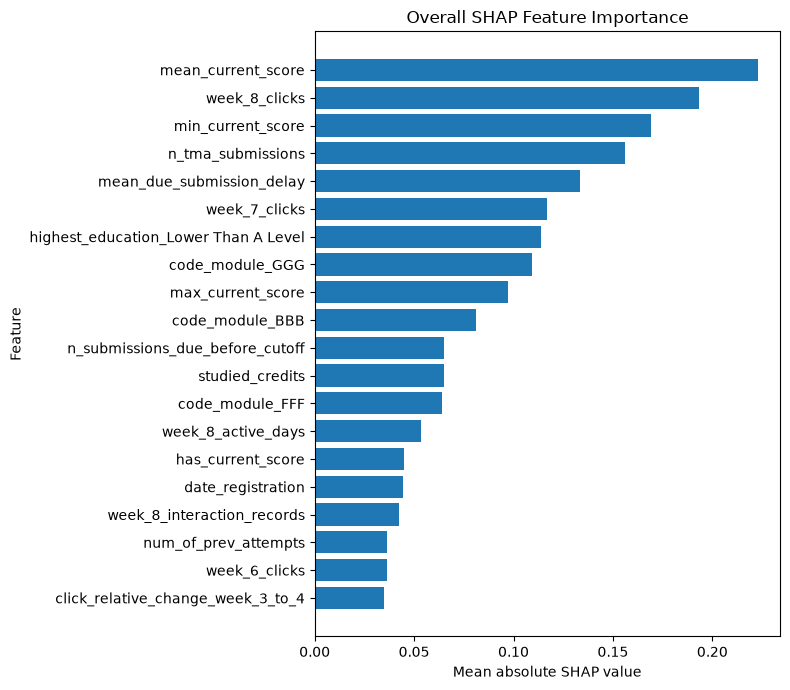

In [246]:
# Overall SHAP bar plot

import matplotlib.pyplot as plt

overall_top20 = (
    overall_shap_importance_clean
    .head(20)
    .sort("mean_abs_shap")
)

plt.figure(figsize=(8, 7))

plt.barh(
    overall_top20["feature"].to_list(),
    overall_top20["mean_abs_shap"].to_list()
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title(
    "Overall SHAP Feature Importance"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "overall_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

这张图适合 Results 里直接放，因为最容易解释

overall importance 里，mean_current_score、week_8_clicks、min_current_score、n_tma_submissions、mean_due_submission_delay 排在前列，说明 final model 同时利用了 assessment performance 和 late-window VLE behavior；

### class-specific SHAP beeswarm

In [247]:
# class-specific SHAP beeswarm
# 这里按四个 outcome 分开画。不要放在一张 subplot 里，单独存四张更清楚。
# 先准备带 feature names 的数据：

import pandas as pd

X_test_shap_df = pd.DataFrame(
    X_test_shap.toarray()
    if hasattr(X_test_shap, "toarray")
    else X_test_shap,
    columns=[
        clean_feature_name(name)
        for name in final_processed_feature_names
    ]
)

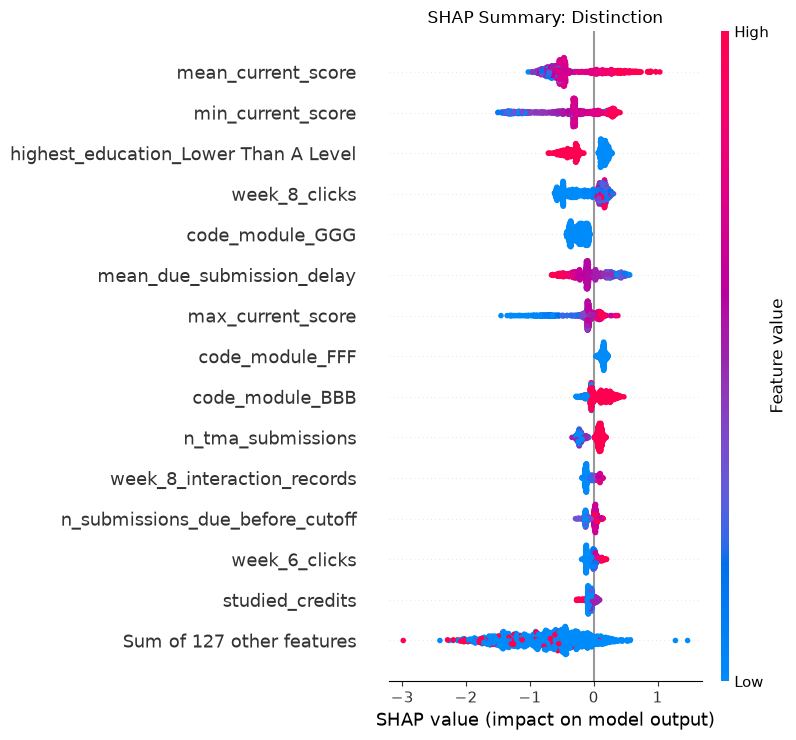

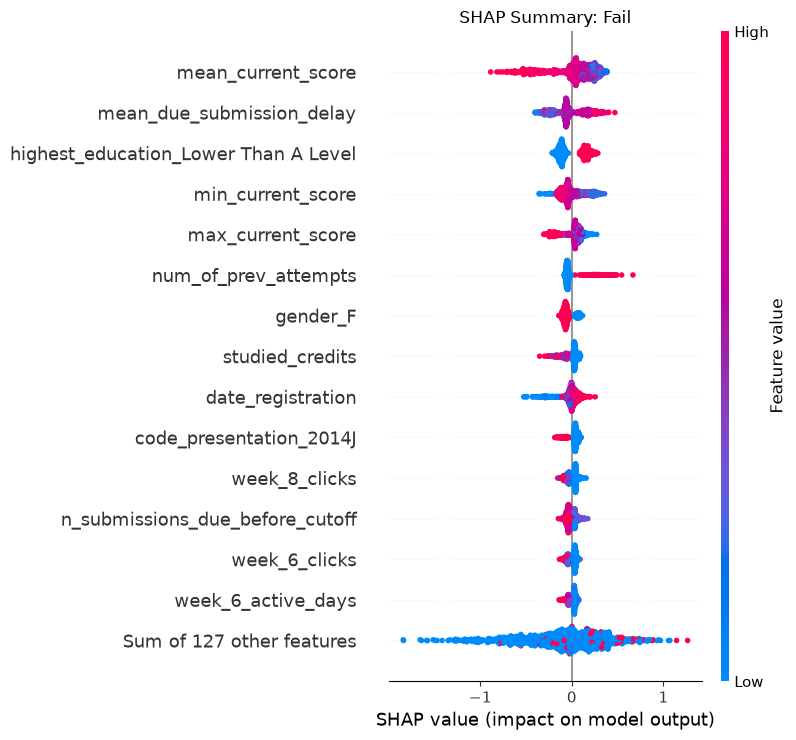

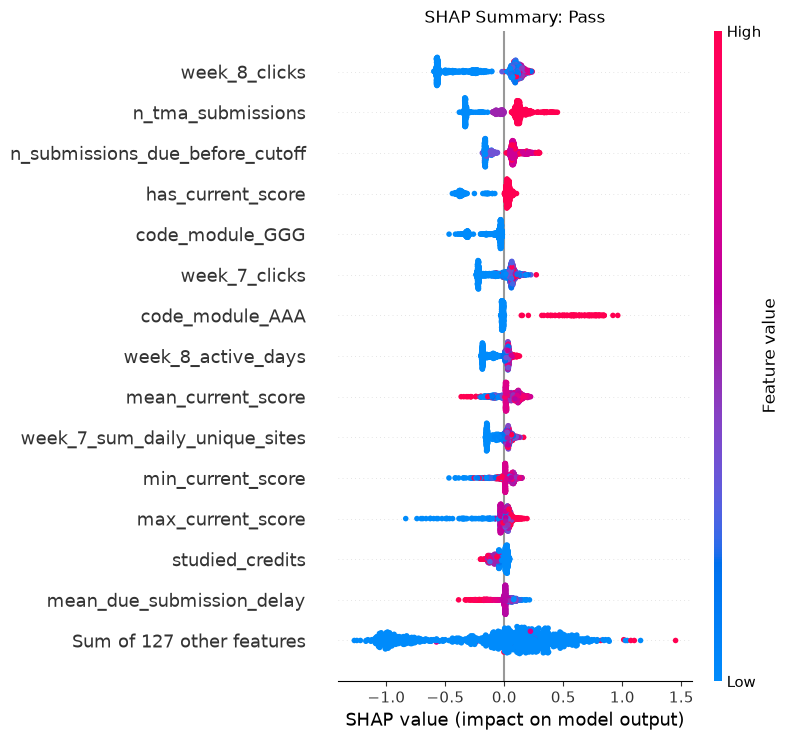

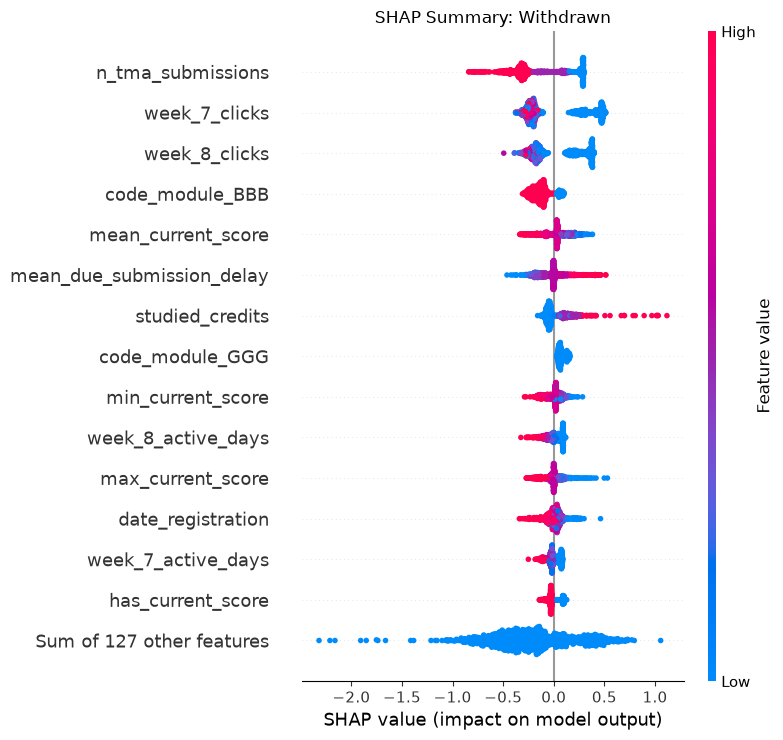

In [248]:
for class_index, class_name in enumerate(
    class_order
):

    class_explanation = shap.Explanation(
        values=shap_values.values[
            :, :, class_index
        ],
        base_values=shap_values.base_values[
            :, class_index
        ],
        data=X_test_shap_df.values,
        feature_names=X_test_shap_df.columns
    )

    shap.plots.beeswarm(
        class_explanation,
        max_display=15,
        show=False
    )

    plt.title(
        f"SHAP Summary: {class_name}"
    )

    plt.tight_layout()

    safe_name = (
        class_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        RESULTS_DIR
        / f"shap_summary_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

这一组图能告诉你：

哪些 feature 最重要；

feature value 高/低分别把 prediction 往哪个方向推；

四个 outcome 的 pattern 是否不同。

特别注意：这里 one-hot categorical variables 仍然会以单独 dummy 形式出现，这是正常的。论文里解释的时候再回到 conceptual feature / feature group 层面。

beeswarm 方向上也能看到一些很直观的 patterns，例如 Distinction 中较高的 current scores 往往推动预测朝 Distinction 方向；Withdrawn 中较少的 TMA submissions、较低的 Week 7/8 activity 更倾向推动 Withdrawn prediction。不过正式写 Results 时建议用“associated with higher/lower model output”这种表达，不要写成 causality。

### feature-group SHAP share

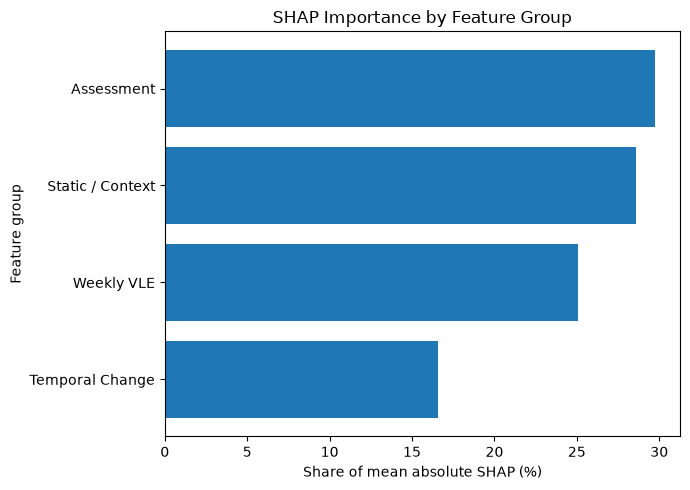

In [249]:
# 画 feature-group SHAP share

feature_group_plot = (
    feature_group_shap
    .sort("shap_share_percent")
)

plt.figure(figsize=(7, 5))

plt.barh(
    feature_group_plot[
        "feature_group"
    ].to_list(),
    feature_group_plot[
        "shap_share_percent"
    ].to_list()
)

plt.xlabel("Share of mean absolute SHAP (%)")
plt.ylabel("Feature group")
plt.title(
    "SHAP Importance by Feature Group"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "shap_feature_group_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature-group 层面，Assessment、Static / Context、Weekly VLE、Temporal Change 都有明显贡献，其中 Weekly VLE + Temporal Change 合计占了相当大的 SHAP share；

### # class-specific group comparison

In [250]:
# class-specific group comparison
# 这个我觉得论文价值甚至比四张 beeswarm 更高：

class_group_plot_df = (
    class_feature_group_shap
    .select([
        "class",
        "feature_group",
        "shap_share_percent"
    ])
    .to_pandas()
)

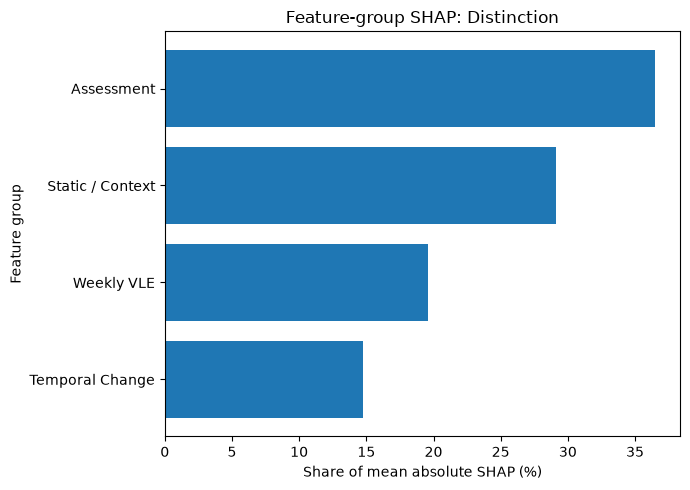

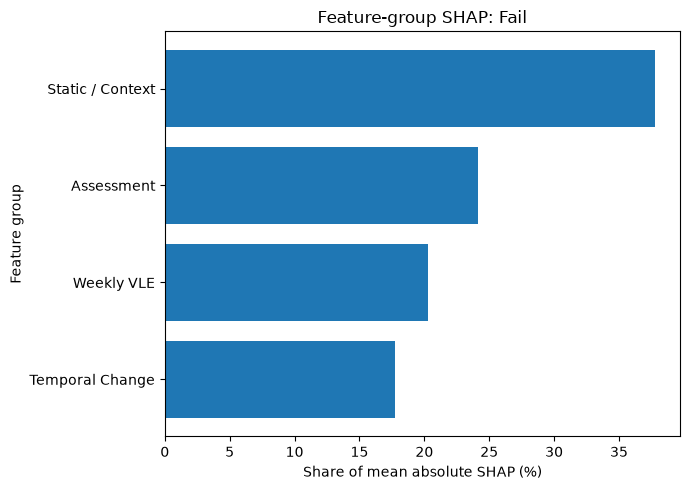

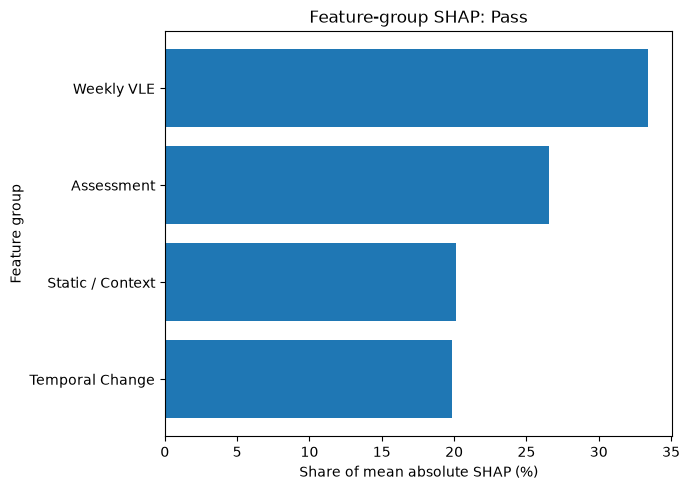

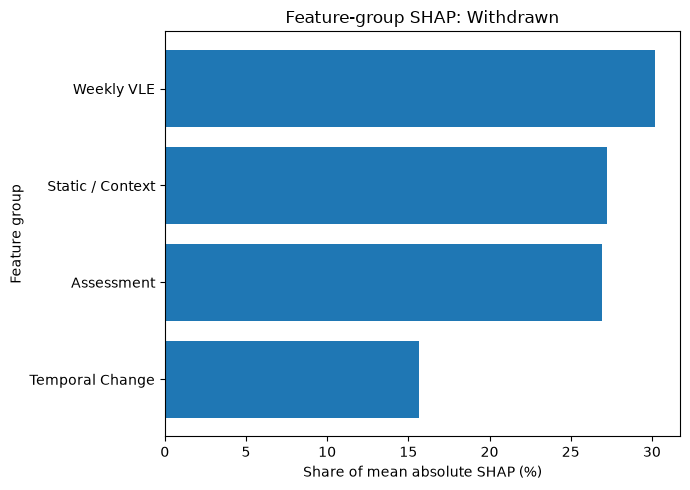

In [251]:
# 先不要做复杂 stacked chart。我们分别画四个 class：

for class_name in class_order:

    plot_data = (
        class_group_plot_df[
            class_group_plot_df[
                "class"
            ] == class_name
        ]
        .sort_values(
            "shap_share_percent"
        )
    )

    plt.figure(figsize=(7, 5))

    plt.barh(
        plot_data["feature_group"],
        plot_data["shap_share_percent"]
    )

    plt.xlabel(
        "Share of mean absolute SHAP (%)"
    )

    plt.ylabel(
        "Feature group"
    )

    plt.title(
        f"Feature-group SHAP: {class_name}"
    )

    plt.tight_layout()

    safe_name = (
        class_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        RESULTS_DIR
        / f"shap_feature_groups_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [252]:
# 把最后 interpretation tables 全保存

conceptual_shap_importance.write_csv(
    RESULTS_DIR
    / "conceptual_shap_importance.csv"
)

feature_group_shap.write_csv(
    RESULTS_DIR
    / "feature_group_shap.csv"
)

class_feature_group_shap.write_csv(
    RESULTS_DIR
    / "class_feature_group_shap.csv"
)

class_shap_top10.write_csv(
    RESULTS_DIR
    / "class_specific_shap_top10.csv"
)

print(
    "Final SHAP tables and figures saved."
)

Final SHAP tables and figures saved.


feature-group 层面，Assessment、Static / Context、Weekly VLE、Temporal Change 都有明显贡献，其中 Weekly VLE + Temporal Change 合计占了相当大的 SHAP share；
Distinction 更依赖 Assessment，尤其 score-related features；

Pass 和 Withdrawn 对 Weekly VLE 的依赖更明显，而 Fail 更依赖 Static / Context。